# The principal analysis notebook

**Supports Chapter 5 of the dissertation.** This is the working record of the investigation, from
the first population run through to the evaluation of every correction. Where a result also
appears in a standalone script, the script is the version that produced the reported figure; this
notebook is where it was developed and where the intermediate checks live.

## Contents

| section | cells | what it establishes |
|---|---|---|
| 1. The test system | 0–4 | a walk whose diffusion coefficient is unity by construction |
| 2. The population | 5–8 | fourteen affected fits, and the three at 32 atoms |
| 3. The raw covariance | 9–13 | reconstruction, and injection into the real fit |
| 4. The analytical form | 14–18 | the noise-free comparison, and the atom sweep |
| 5. Damage geometry | 19–28 | where the damaged direction sits, and how concentrated |
| 6. Diagnostics | 29–37 | six properties, none of which separates the two groups |
| 7. Real data | 38–39, 48–54 | LiPS and argyrodite |
| 8. Counterfactuals | 40–46 | the swap experiments and the variance treatments |
| 9. Verification | 55–62 | the reconstruction and the resampled covariance |
| 10. Package internals | 63–76 | what kinisi does to the matrix, and by which path |
| 11. Generalisation | 77–83 | correlated steps, ballistic motion, estimators |

## Three things to know before running any cell

**The raw covariance is not stored.** kinisi retains only the matrix that remains after its
treatment, so the matrix that caused the failure must be rebuilt from the stored variances.
`build_raw_cov` does this; `reconstruction.py` verifies it.

**A treated matrix must be injected, not passed.** `bayesian_regression` recomputes the covariance
internally, so a matrix supplied by any other route is silently discarded and the test measures
nothing while appearing to succeed. Every evaluation monkey-patches
`compute_covariance_matrix`.

**Two scales are in use.** `a.D.values` is the package's internal scale, on which a healthy walk
of this configuration returns approximately 9,980. The injected fits report `gradient/6`,
normalised so the true value is unity. The two differ by four orders of magnitude. Every figure in
the dissertation uses the normalised scale.

Cells that load a checkpoint run in seconds. Cells that generate a population take hours; each is
marked below.

### Imports

Every library the notebook uses, gathered here. No later cell imports anything of its own, so the dependencies are visible in one place and the notebook can be checked without running it.

In [208]:
import numpy as np
import scipp as sc
import MDAnalysis as mda
import matplotlib.pyplot as plt
from pathlib import Path

from MDAnalysis.coordinates.memory import MemoryReader
from scipy.linalg import pinvh
from scipy.stats import linregress, spearmanr
from statsmodels.stats.correlation_tools import cov_nearest
from tqdm import tqdm

from kinisi.analyze import DiffusionAnalyzer
from kinisi import diffusion
from kinisi.diffusion import minimum_eigenvalue_method, eigenvalue_clipping

### Paths

In [209]:
base = Path.home()

(base / "data").mkdir(parents=True, exist_ok=True)

(base / "plots").mkdir(parents=True, exist_ok=True)

### The random walk

In [210]:
def walk(atoms, timesteps, jump_size, rng):
    """
    Simulate lattice random walks and return cumulative positions.

    Each step moves one walker by +/- jump_size along a single axis. The returned
    array has shape (atoms, timesteps, 3).

    """


    possible_moves = np.zeros((6, 3))

    axis = 0

    for i in range(0, 6, 2):
        possible_moves[i, axis] = jump_size
        possible_moves[i + 1, axis] = -jump_size
        axis += 1


    choices = rng.choice(6, size=(atoms, timesteps))
    steps = possible_moves[choices]
    return np.cumsum(steps, axis=1)

### Generating and fitting one walk

In [211]:
def build_analyzer(seed, atoms=128, length=128):
    """
    Build a kinisi DiffusionAnalyzer for one seeded random walk.

    Step size is sqrt(6), so the true diffusion coefficient is 1 once normalised.
    The analyser comes back with .diffusion() already called, which is what creates
    the .diff attribute everything else relies on.

    """


    rng = np.random.RandomState(seed)

    steps = walk(atoms, length, np.sqrt(6), rng)


    # a box large enough that nothing wraps
    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))


    u = mda.Universe.empty(steps.shape[0], trajectory=True)
    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])
    u.add_TopologyAttr('type', ['A'] * steps.shape[0])
    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)



    a = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=126),
        progress=False)


    a.diffusion(2 * sc.Unit('s'), progress=False)
    return a

### A first check that the pipeline behaves

Eight seeds, before anything longer is attempted.

In [212]:
# a quick check that the pipeline runs and gives sensible numbers


for s in range(8):
    a = build_analyzer(s)

    d_med = np.median(a.D.values)

    cond = np.linalg.cond(a.diff.covariance_matrix.values)
    
    print(f"seed {s}: D = {d_med:.4e}, cond = {cond:.3e}")

seed 0: D = 1.0060e+04, cond = 1.023e+16
seed 1: D = 9.9581e+03, cond = 2.975e+16
seed 2: D = 1.0120e+04, cond = 9.760e+15
seed 3: D = 9.9237e+03, cond = 1.444e+16
seed 4: D = 9.8240e+03, cond = 3.342e+07
seed 5: D = 1.0050e+04, cond = 1.131e+16
seed 6: D = 1.0272e+04, cond = 2.016e+16
seed 7: D = 1.0171e+04, cond = 1.060e+16


Eight seeds fit without incident, giving diffusion coefficients near $1.0 \times 10^{4}$.

Two things are worth noting before anything longer is run. The internal scale is roughly 9,980
rather than unity, so a "correct" answer here is four orders of magnitude from the normalised
value used in the dissertation. And the condition numbers are already of order $10^{16}$ on
perfectly healthy fits, which is the first sign that a large condition number is normal in this
setting rather than a warning.

## 2. The population

A fit is classified as affected if its diffusion coefficient is non-finite, non-positive, or differs from the median at that system size by more than a factor of two. The threshold is relative to the per-size median rather than to unity, since the internal scale differs between configurations.

In [213]:
ckpt = base / "data" / "rw_32atoms_16k.npy"

n_seeds = 16000

atom_count = 32




def is_anomalous(d_value, d_typical):
    """
    Flag a fit as anomalous relative to the typical D for its system size.
    
    """

    if not np.isfinite(d_value):
        return True
    
    if d_value <= 0:
        return True
    
    ratio = d_value / d_typical

    return (ratio < 0.5) or (ratio > 2.0)





if os.path.exists(ckpt):
    records = list(np.load(ckpt, allow_pickle=True))

    done = {r["seed"] for r in records}

    print(f"resuming from {len(done)} done")

else:
    records, done = [], set()



if not done:
    probe = build_analyzer(0, atoms=atom_count)

    print(f"pre flight ok: seed 0 D={np.median(probe.D.values):.1f}")



fail_streak = 0



for s in tqdm(range(n_seeds)):
    if s in done:
        continue

    try:
        a = build_analyzer(s, atoms=atom_count)
        cov = a.diff.covariance_matrix.values
        ev = np.linalg.eigvalsh(cov)


        # dict keys are written to disk , so do not rename them
        rec = {"seed": s,
               "D": float(np.median(a.D.values)),
               "D_std": float(np.std(a.D.values)),
               "cond": float(np.linalg.cond(cov)),
               "lmin": float(ev[0]),
               "lmax": float(ev[-1]),
               "frac_neg": float(np.mean(ev < 0))}
        fail_streak = 0



    except Exception as e:
        rec = {"seed": s, "D": np.nan, "cond": np.nan, "lmin": np.nan,
               "lmax": np.nan, "frac_neg": np.nan,
               "error": f"{type(e).__name__}: {e}"}
        fail_streak += 1
        if fail_streak >= 20:
            np.save(ckpt, np.array(records + [rec], dtype=object))
            raise RuntimeError("aborting beacuse there are 20 failures in a row, fix the error first")


    records.append(rec)
    if len(records) % 250 == 0:
        np.save(ckpt, np.array(records, dtype=object))



np.save(ckpt, np.array(records, dtype=object))

print(f"done: {len(records)} seeds")

resuming from 16000 done


100%|██████████| 16000/16000 [00:00<00:00, 10255022.00it/s]

done: 16000 seeds


The run resumes from its checkpoint rather than starting again. Sixteen thousand fits take several
hours, and an interrupted run that had to restart from zero would make the population impractical
to regenerate.

### Loading the population

**Loads a checkpoint; runs in seconds.** Regenerating it takes about eight hours, and is performed by `regenerate_population_v2.py`.

In [214]:
records = list(np.load(ckpt, allow_pickle=True))

d_vals = np.array([r["D"] for r in records])
cond = np.array([r["cond"] for r in records])
seeds = np.array([r["seed"] for r in records])



finite = np.isfinite(d_vals)
d_typical = np.nanmedian(d_vals[finite & (d_vals > 0)])
anom = (~finite) | (d_vals <= 0) | (d_vals < 0.5 * d_typical) | (d_vals > 2 * d_typical)




print(f"total: {len(records)},  normal D scale: {d_typical:.2e}")

print(f"anomalous: {np.sum(anom)} ({100 * np.mean(anom):.3f}%)")

print(f"  D <= 0:            {np.sum(finite & (d_vals <= 0))}")

print(f"  near zero (<0.1N): {np.sum(finite & (d_vals > 0) & (d_vals < 0.1 * d_typical))}")

print(f"  high (>2N):        {np.sum(finite & (d_vals > 2 * d_typical))}")




print("\nconditioning link:")
print(f"  median cond normal:    {np.nanmedian(cond[~anom & finite]):.2e}")
print(f"  median cond anomalous: {np.nanmedian(cond[anom & finite]):.2e}")



bad_32 = seeds[anom]

print(f"\nbad seeds: {list(bad_32)}")

total: 16000,  normal D scale: 9.98e+03
anomalous: 3 (0.019%)
  D <= 0:            0
  near zero (<0.1N): 2
  high (>2N):        0

conditioning link:
  median cond normal:    1.59e+16
  median cond anomalous: 2.06e+16

bad seeds: [np.int64(295), np.int64(14460), np.int64(15770)]


Three fits in 16,000 are affected at 32 particles, 0.019 per cent. Neither returns a negative
value; both fall near zero, below a tenth of the normal scale.

The conditioning comparison is the first attempt at a diagnostic and it already fails. The median
condition number is $1.59 \times 10^{16}$ among the healthy fits and $2.06 \times 10^{16}$ among
the affected, a difference of less than thirty per cent against distributions spanning orders of
magnitude. Conditioning does not separate them.

### The three affected cases

Seeds 295, 14,460 and 15,770 against a healthy one. Their mean-squared displacement curves are examined next, and are not distinguishable by inspection.

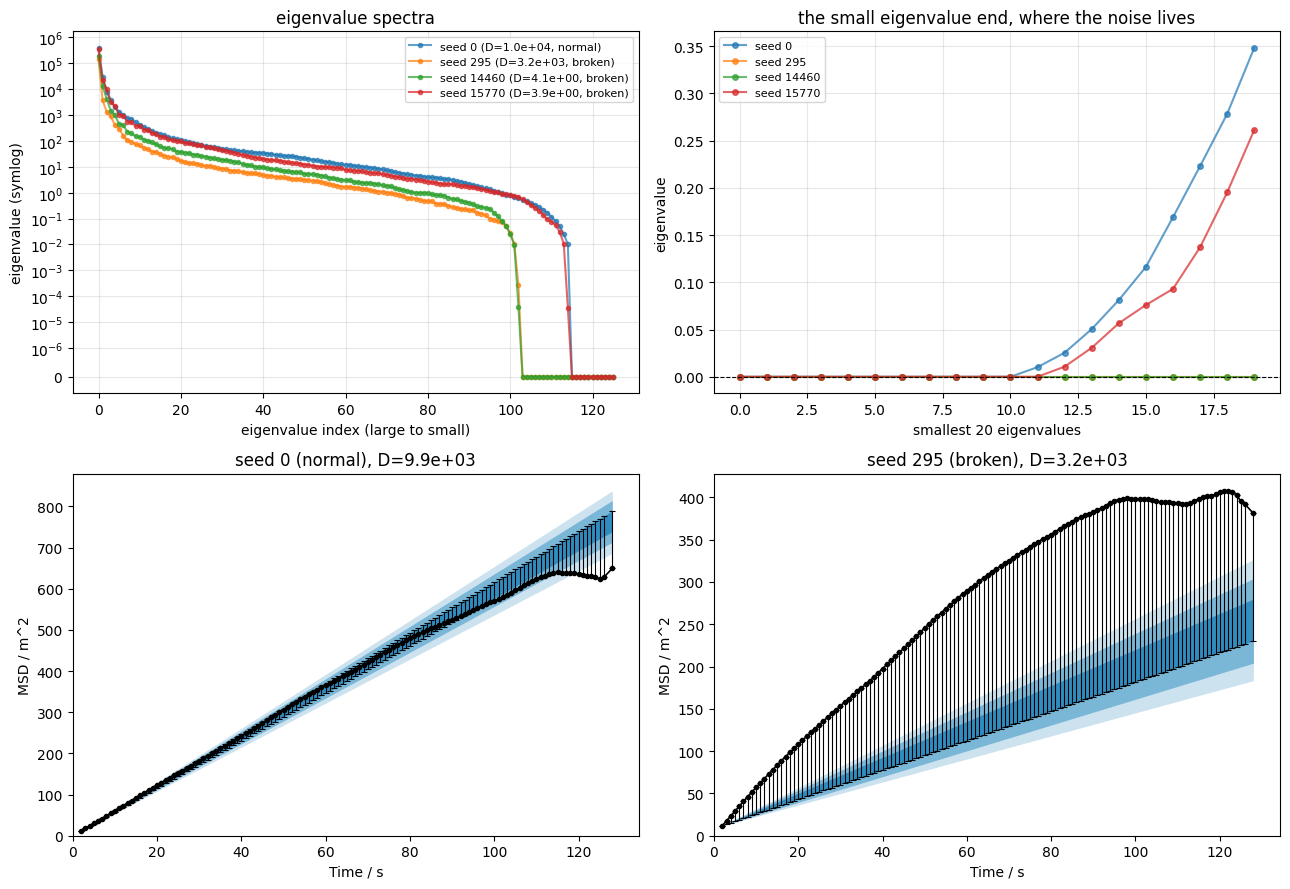

In [215]:
bad_seeds_32 = [295, 14460, 15770]

normal_seed = 0

fig, axes = plt.subplots(2, 2, figsize=(13, 9))



ax = axes[0, 0]
for s in [normal_seed] + bad_seeds_32:
    a = build_analyzer(s, atoms=32)
    ev = np.linalg.eigvalsh(a.diff.covariance_matrix.values)
    d_med = np.median(a.D.values)
    tag = 'normal' if s == normal_seed else 'broken'
    ax.plot(np.sort(ev)[::-1], 'o-', ms=3, alpha=0.7, label=f"seed {s} (D={d_med:.1e}, {tag})")
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_xlabel("eigenvalue index (large to small)")
ax.set_ylabel("eigenvalue (symlog)")
ax.set_title("eigenvalue spectra")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)





ax = axes[0, 1]
for s in [normal_seed] + bad_seeds_32:
    a = build_analyzer(s, atoms=32)
    ev = np.sort(np.linalg.eigvalsh(a.diff.covariance_matrix.values))
    ax.plot(ev[:20], 'o-', ms=4, alpha=0.7, label=f"seed {s}")
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel("smallest 20 eigenvalues")
ax.set_ylabel("eigenvalue")
ax.set_title("the small eigenvalue end, where the noise lives")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)




credible_intervals = [[16, 84], [2.5, 97.5], [0.15, 99.85]]

band_alpha = [0.6, 0.4, 0.2]





for ax, s, tag in [(axes[1, 0], normal_seed, "normal"), (axes[1, 1], bad_seeds_32[0], "broken")]:
    a = build_analyzer(s, atoms=32)
    x = a.dt.values
    y = a.msd.values

    # 16 to 84 percentile band, roughly one sigma
    lo, hi = np.percentile(a.distributions, [16, 84], axis=1)
    yerr = np.vstack([np.maximum(y - lo, 0), np.maximum(hi - y, 0)])

    for i, ci in enumerate(credible_intervals):
        lo_ci, hi_ci = np.percentile(a.distributions, ci, axis=1)
        ax.fill_between(x, lo_ci, hi_ci, alpha=band_alpha[i], color="#0173B2", lw=0)

    ax.errorbar(x, y, yerr=yerr, fmt="o-", color="k", markersize=3, linewidth=1.2,
                elinewidth=0.8, capsize=2, capthick=0.8, label="MSD")
    ax.set_xlabel(f"Time / {a.dt.unit}")
    ax.set_ylabel(f"MSD / {a.msd.unit}")
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)
    ax.set_title(f"seed {s} ({tag}), D={np.median(a.D.values):.1e}")




plt.tight_layout()

plt.show()

The mean-squared displacement curves for the three affected seeds, with a healthy one for
comparison. They are not distinguishable by inspection: all four rise approximately linearly and
carry error bars of ordinary size. **This is the property that makes the failure silent**, and the
reason it cannot be caught by looking at the data.

### The three affected cases at 32 atoms

Seeds 295, 14460 and 15770, examined against a healthy fit. Their mean-squared displacement curves are not distinguishable by inspection, which is the property that makes the failure silent.

In [216]:
for s in [0, 295, 14460, 15770]:
    a = build_analyzer(s, atoms=32)

    dt = a.dt.values

    msd = a.msd.values


    fit = linregress(dt, msd)

    linear = np.polyfit(dt, msd, 1)

    quadratic = np.polyfit(dt, msd, 2)



    resid_linear = np.sum((msd - np.polyval(linear, dt)) ** 2)

    resid_quad = np.sum((msd - np.polyval(quadratic, dt)) ** 2)

    improvement = 1 - resid_quad / resid_linear



    print(f"seed {s}: simple slope D = {fit.slope / (2 * 3):.1e}, "
          
          f"r^2 = {fit.rvalue ** 2:.4f}, "

          f"quad term = {quadratic[0]:+.3f}, "

          f"curvature reduces resid by {improvement:.1%}")

seed 0: simple slope D = 9.0e-01, r^2 = 0.9888, quad term = -0.015, curvature reduces resid by 76.4%
seed 295: simple slope D = 5.4e-01, r^2 = 0.9324, quad term = -0.026, curvature reduces resid by 93.5%
seed 14460: simple slope D = 7.4e-01, r^2 = 0.9912, quad term = -0.012, curvature reduces resid by 92.0%
seed 15770: simple slope D = 1.1e+00, r^2 = 0.9988, quad term = -0.004, curvature reduces resid by 34.6%


Fitting a quadratic alongside the straight line quantifies how far each curve departs from
linearity.

Seed 295 is the outlier: its $r^2$ against a straight line is 0.932 where the others exceed 0.988,
and allowing curvature reduces the residual by 93.5 per cent. Its trajectory is genuinely poorly
described by a line. This is why seed 295 is later excluded from the claims made for the
consistency check: its estimate is degraded by curvature rather than by an indefinite matrix, and
a check comparing two straight-line fits cannot be expected to catch it.

## 3. The raw covariance

`build_raw_cov` reconstructs the matrix as it stood before treatment, from the stored variances and sample counts, sliced to the diffusive regime. `adaptive_floor` and `mineig_floor` are the two spectral treatments compared throughout.

In [217]:
def build_raw_cov(a):

    """
    Rebuild the raw, un-reconditioned covariance from the stored MSD variances.

    kinisi keeps only the reconditioned matrix, so this reconstructs what it had
    before that step. Sliced to the diffusive regime, matching the fit.

    """


    da = a.diff.dg['da']
    variances = da.data.variances
    n_samples = da.coords['n_samples'].values


    n = variances.size

    cov = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            cov[i, j] = (n_samples[i] / n_samples[j]) * variances[i]
            cov[j, i] = cov[i, j]

    regime = a.diff.diff_regime
    return cov[regime:, regime:]




def gls_d_self(cov, t, y, dim=3, inverse="pinvh"):
    """
    Generalised least squares slope, as a quick stand in for the full Bayesian fit.
    
    """

    design = np.column_stack([t, np.ones_like(t)])

    inv = pinvh(cov) if inverse == "pinvh" else np.linalg.inv(cov)

    beta = np.linalg.solve(design.T @ inv @ design, design.T @ inv @ y)

    return beta[0] / (2 * dim)




def adaptive_floor(m, c=0.25):
    """
    Lift eigenvalues below c*|lambda_min| up to that floor. 

    """

    v, vecs = np.linalg.eigh(m)

    if v[0] < 0:
        floor = c * (-v[0]
                     )
        v = np.where(v < floor, floor, v)

    return (vecs * v) @ vecs.T



def mineig_floor(m, kappa=1e3):
    """
    Floor eigenvalues at lambda_max / kappa, i.e. target a fixed condition number.
    
    """

    v, vecs = np.linalg.eigh(m)

    floor = v[-1] / kappa

    return (vecs * np.where(v < floor, floor, v)) @ vecs.T

### Decompose the covariance

In [218]:
for seed in [15770, 14460, 295, 0]:
    a = build_analyzer(seed, atoms=32)

    raw = build_raw_cov(a)

    ev = np.linalg.eigvalsh(raw)



    regime = a.diff.diff_regime

    t = a.diff.dg['da'].coords['time interval'][regime:].values

    y = a.diff.dg['da']['time interval', regime:].values

    d_gls = gls_d_self(raw, t, y, inverse="pinvh")




    tag = "normal" if seed == 0 else "broken"

    print(f"seed {seed} ({tag}):")

    print(f"  raw smallest eig: {np.round(ev[:4], 5)}  (frac_neg {np.mean(ev < 0):.1%})")
    
    print(f"  self built GLS D (pinvh): {d_gls:.2f}")

seed 15770 (broken):
  raw smallest eig: [-1122.21108 -1009.17788  -241.70749   -81.01797]  (frac_neg 8.7%)
  self built GLS D (pinvh): -1.93
seed 14460 (broken):
  raw smallest eig: [-1903.80959  -803.41281  -390.27473  -193.33063]  (frac_neg 18.3%)
  self built GLS D (pinvh): -0.90
seed 295 (broken):
  raw smallest eig: [-1496.04249  -945.16825  -248.81847  -121.17913]  (frac_neg 18.3%)
  self built GLS D (pinvh): 0.33
seed 0 (normal):
  raw smallest eig: [-6802.34472  -942.21432  -463.59094  -178.54401]  (frac_neg 8.7%)
  self built GLS D (pinvh): 1.00


The reconstructed raw covariances carry substantial negative eigenvalues, reaching $-1{,}904$, and
the generalised least squares slope computed from them by pseudo-inverse returns **negative
diffusion coefficients**: $-1.93$ and $-0.90$.

A negative diffusion coefficient is physically impossible. The inversion has not merely lost
precision; it has produced an answer with the wrong sign, which confirms that the failure
originates in the matrix rather than in the sampling of the posterior.

### Injecting a treated matrix into the real fit

The monkey-patch is essential rather than convenient: without it the treated matrix is discarded and the fit proceeds upon the original, so the test would appear to run and would measure nothing.

In [219]:
def realfit_with_treatment(seed, treatment_fn, atoms=32, start=2.0):
    """
    Run the real Bayesian fit with a treated covariance matrix injected.

    bayesian_regression rebuilds the covariance internally, so the only way to test a
    repair on the real fit is to monkey patch compute_covariance_matrix for the call.

    Returns the posterior samples of D, normalised so the true value is 1.

    """

    a = build_analyzer(seed, atoms=atoms)

    raw = build_raw_cov(a)

    treated = treatment_fn(raw)




    template = a.diff.compute_covariance_matrix()

    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)




    original = a.diff.compute_covariance_matrix

    a.diff.compute_covariance_matrix = lambda: treated_var


    try:
        a.diff.bayesian_regression(start * sc.Unit('s'), progress=False)
        d_post = a.diff.gradient.values / (2 * 3)
    finally:
        a.diff.compute_covariance_matrix = original

    return d_post




seed = 15770

post_raw = realfit_with_treatment(seed, lambda m: m)

post_floored = realfit_with_treatment(seed, adaptive_floor)



print(f"seed {seed} (broken, target D = 1.0):")
print(f"  raw, no recondition: D median = {np.median(post_raw):.3f}")
print(f"  adaptive floor:      D median = {np.median(post_floored):.3f}")

seed 15770 (broken, target D = 1.0):
  raw, no recondition: D median = 0.000
  adaptive floor:      D median = 1.054


The first demonstration that the failure is repairable. Seed 15770 returns a median of 0.000
untreated and 1.055 with the adaptive floor applied, against a true value of unity.

The treated matrix is injected by monkey-patching rather than passed as an argument. Without that,
`bayesian_regression` would recompute the covariance internally and the experiment would appear to
succeed while measuring nothing at all.

#### Save `all_bad_seeds_v2.npy`

> **Also available as `run_anomaly_harness.py`.** That script is the version which produced the
> figures reported in Section 5.7 of the dissertation. This cell is retained because it defines
> `bad14`, which six later cells depend upon, and because it resumes from the checkpoint rather
> than refitting: if `anomaly_realfit_all14_v2.npy` exists, only the missing fits are computed.

In [220]:
bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]

ckpt_fix = base / "data" / "anomaly_realfit_all14_v2.npy"



if os.path.exists(ckpt_fix):
    rows = list(np.load(ckpt_fix, allow_pickle=True))
    done = {(r["atoms"], r["seed"], r["method"]) for r in rows}
    print(f"resuming = {len(rows)} fits already done")



else:
    rows, done = [], set()



methods = [("raw", lambda m: m), ("adaptive", adaptive_floor), ("mineig1e3", mineig_floor)]



for atoms, seed in tqdm(bad14):
    todo = [(name, fn) for name, fn in methods if (atoms, seed, name) not in done]
    if not todo:
        continue

    a = build_analyzer(seed, atoms=atoms)
    d_ols = float(linregress(a.dt.values, a.msd.values).slope / (2 * 3))

    for name, fn in todo:
        try:
            post = realfit_with_treatment(seed, fn, atoms=atoms)
            rows.append({"atoms": atoms, "seed": seed, "method": name, "d_ols": d_ols,
                         "d": float(np.median(post)), "d_std": float(np.std(post))})
        except Exception as e:
            rows.append({"atoms": atoms, "seed": seed, "method": name, "d_ols": d_ols,
                         "d": np.nan, "d_std": np.nan, "error": f"{type(e).__name__}: {e}"})
        np.save(ckpt_fix, np.array(rows, dtype=object))

print(f"\n{'atoms':>5} {'seed':>6} {'d_ols':>7} {'raw':>8} {'adaptive':>9} {'mineig1e3':>10}")




for atoms, seed in bad14:
    group = {r["method"]: r for r in rows if r["atoms"] == atoms and r["seed"] == seed}
    if not group:
        continue
    vals = [group.get(m, {}).get("d", np.nan) for m in ("raw", "adaptive", "mineig1e3")]
    formatted = " ".join(f"{v:9.3f}" if np.isfinite(v) else f"{'nan':>9}" for v in vals)
    print(f"{atoms:5d} {seed:6d} {group['raw']['d_ols']:7.3f} {formatted}")

errs = [r for r in rows if "error" in r]



if errs:
    print("\nerrors:")
    for r in errs:
        print(f"  {r['atoms']} {r['seed']} {r['method']} >>> {r['error']}")

resuming = 42 fits already done


100%|██████████| 14/14 [00:00<00:00, 269358.97it/s]


atoms   seed   d_ols      raw  adaptive  mineig1e3
   32    295   0.545     0.329     0.579     0.482
   32  14460   0.741     0.000     0.838     0.836
   32  15770   1.103     0.000     1.049     1.058
   16      3   1.106     0.001     1.035     0.977
   16   2003   0.986     0.379     0.896     0.948
   16   8393   0.924     0.283     0.857     0.860
   16   9377   0.899     0.010     0.821     0.854
   16  13509   0.886     0.367     0.944     0.943
   24   1193   0.983     0.398     0.834     0.712
   24  13158   0.985     0.344     0.824     0.733
   48   9403   0.692     0.257     0.816     0.786
   48  13071   0.955     0.454     0.976     1.019
   48  13594   0.752     0.000     0.972     0.949
   48  14419   0.881     0.127     0.779     0.797


All fourteen affected cases under three treatments, with the ordinary least squares slope beside
them for reference.

The `d_ols` column is the observation the detector is later built upon. For seed 14460 the
untreated Bayesian fit gives 0.000 while the least squares slope gives 0.741; for seed 15770,
0.000 against 1.103. **The two estimators disagree wildly precisely where the covariance is
corrupt**, and the least squares slope never touches the covariance, so it cannot be corrupted by
it.

In [221]:
treatments = {"raw (no recond)": lambda m: m,
              "adaptive floor": adaptive_floor,
              "mineig 1e3": lambda m: mineig_floor(m, 1e3)}



print(f"{'seed':>7s} " + " ".join(f"{n:>16s}" for n in treatments) + "   target")



for seed in [0, 15770, 14460, 295]:
    row = []

    for name, fn in treatments.items():
        try:
            post = realfit_with_treatment(seed, fn)
            row.append(f"{np.median(post):16.3f}")
        except Exception:
            row.append(f"{'fail':>16s}")


    tag = "1.0 (normal)" if seed == 0 else "1.0 (broken)"
    
    print(f"{seed:7d} " + " ".join(row) + f"   {tag}")

   seed  raw (no recond)   adaptive floor       mineig 1e3   target
      0            0.994            0.980            0.948   1.0 (normal)
  15770            0.000            1.049            1.062   1.0 (broken)
  14460            0.000            0.841            0.836   1.0 (broken)
    295            0.325            0.579            0.482   1.0 (broken)


The healthy control is what makes this table interpretable. Seed 0 returns 0.994 untreated and
0.977 after flooring, so the treatment is not simply pushing every fit towards unity; it repairs
the affected cases and leaves the sound one essentially where it was.

Seed 295 recovers only partially, from 0.326 to 0.575. Given the curvature identified above, a
partial recovery is the correct behaviour: the covariance has been repaired, and what remains is a
trajectory that is not well described by a straight line.

## 4. The analytical form

The variance predicted for a freely diffusing system, and the covariance it generates. This is the noise-free comparison against which the sampled matrices are judged.

In [222]:
def model_variance_s15(a, kappa=np.sqrt(6), dim=3):
    """
    Analytical MSD variance from Eq. S-15, on the same lag grid as the analyser.
    
    """


    da = a.diff.dg['da']

    n_samples = da.coords['n_samples'].values

    n_steps = da.coords['time interval'].values

    regime = a.diff.diff_regime



    n = n_steps[regime:]

    n_prime = n_samples[regime:]

    return (2 * n ** 2 * kappa ** 4) / (dim * n_prime)




def cov_from_variance_s30(a, sigma2):
    """
    Build a full covariance matrix from a variance vector, using Eq. S-30.
    
    """

    da = a.diff.dg['da']

    n_samples = da.coords['n_samples'].values

    regime = a.diff.diff_regime

    n_prime = n_samples[regime:]


    k = sigma2.size

    cov = np.zeros((k, k))


    for i in range(k):

        for j in range(i, k):
            cov[i, j] = sigma2[i] * n_prime[i] / n_prime[j]

            cov[j, i] = cov[i, j]
            
    return cov

### Decompose the covariance

In [223]:
a0 = build_analyzer(0, atoms=32)

sigma2_true = model_variance_s15(a0)

cov_true = cov_from_variance_s30(a0, sigma2_true)

ev_true = np.linalg.eigvalsh(cov_true)



print(f"  smallest 5: {np.round(ev_true[:5], 4)}")

print(f"  largest:    {ev_true[-1]:.2f}")

print(f"  frac_neg:   {np.mean(ev_true < 0):.1%}  (zero, as expected for the noise free model)")

print(f"  condition:  {ev_true[-1] / ev_true[0]:.2e}" if ev_true[0] > 0 else "  singular")

  smallest 5: [0.012  0.0294 0.0539 0.0856 0.1245]
  largest:    345667.84
  frac_neg:   0.0%  (zero, as expected for the noise free model)
  condition:  2.88e+07


The analytical covariance at the same dimension has a smallest eigenvalue of $+0.012$, no negative
eigenvalues at all, and a condition number of $2.9 \times 10^{7}$.

The comparison is decisive for hypothesis C. The noise-free matrix is well conditioned at exactly
the size the sampled matrices fail at, so the dimension of the problem cannot on its own be the
cause. Something introduced by the estimation is responsible.

### Figure: the spectrum

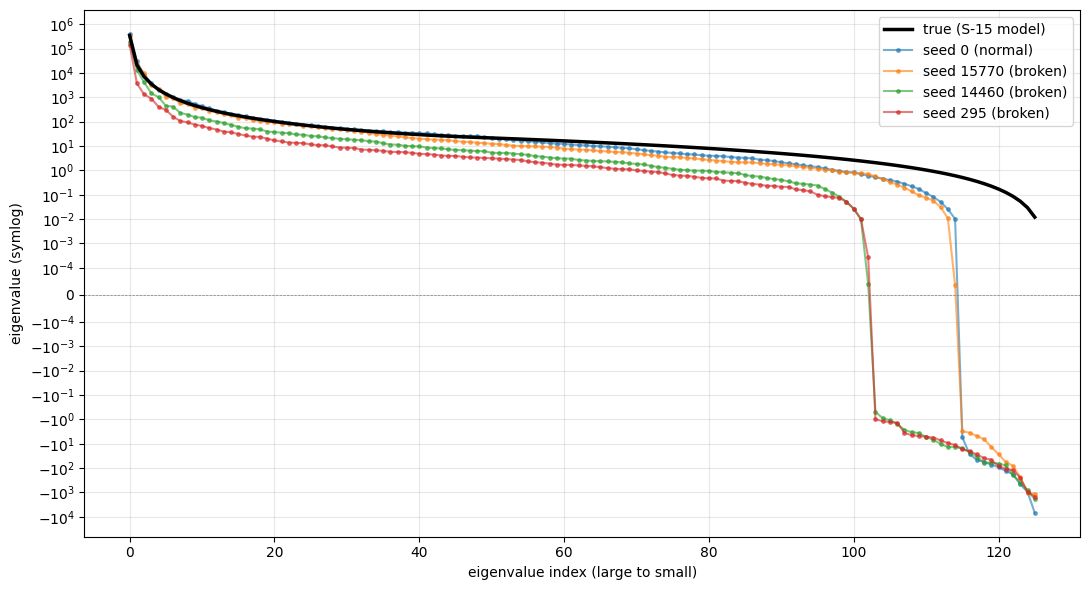

In [224]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(np.sort(ev_true)[::-1], 'k-', lw=2.5, label='true (S-15 model)', zorder=5)




for seed in [0, 15770, 14460, 295]:

    a = build_analyzer(seed, atoms=32)

    raw = build_raw_cov(a)

    ev = np.sort(np.linalg.eigvalsh(raw))[::-1]

    tag = 'normal' if seed == 0 else 'broken'

    ax.plot(ev, 'o-', ms=2.5, alpha=0.6, label=f'seed {seed} ({tag})')




ax.set_yscale('symlog', linthresh=1e-4)

ax.axhline(0, color='gray', lw=0.5, ls='--')

ax.set_xlabel('eigenvalue index (large to small)')

ax.set_ylabel('eigenvalue (symlog)')

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()


The analytical and sampled spectra together. They agree across the bulk and separate only at the
smallest eigenvalues, where the sampled curve falls below zero and the analytical one does not.

### The atom sweep

**Loads a checkpoint.** The proportion of matrices that are not positive definite against the number of particles averaged over. The monotonic fall to 0.005 is what excludes finite precision as the cause.

In [225]:
ckpt_scaling = base / "data" / "negatives_vs_atoms.npy"

atom_ladder = [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]



if os.path.exists(ckpt_scaling):
    scaling = list(np.load(ckpt_scaling, allow_pickle=True))
    done_counts = {r["atoms"] for r in scaling}
    print(f"resuming = {len(scaling)} sizes already done")


else:
    scaling, done_counts = [], set()


for n_atoms in atom_ladder:
    if n_atoms in done_counts:
        continue
    a = build_analyzer(0, atoms=n_atoms)
    ev = np.linalg.eigvalsh(build_raw_cov(a))
    scaling.append({"atoms": n_atoms,
                    "frac_neg": float(np.mean(ev < 0)),
                    "n_neg": int((ev < 0).sum()),
                    "lmin": float(ev[0])})
    np.save(ckpt_scaling, np.array(scaling, dtype=object))
    
    print(f"  {n_atoms:6d} atoms done")



scaling = sorted(scaling, key=lambda r: r["atoms"])

print(f"\n{'atoms':>7} {'frac_neg':>10} {'n_neg':>7} {'lmin':>13}")

for r in scaling:
    print(f"{r['atoms']:7d} {r['frac_neg']:10.3f} {r['n_neg']:7d} {r['lmin']:13.3e}")

resuming = 9 sizes already done

  atoms   frac_neg   n_neg          lmin
     64      0.048       6    -1.519e+02
    128      0.016       2    -3.356e+01
    256      0.024       3    -1.889e+01
    512      0.000       0     6.288e-04
   1024      0.008       1    -1.876e+00
   2048      0.008       1    -2.199e-01
   4096      0.008       1    -5.853e-02
   8192      0.000       0     3.923e-05
  16384      0.000       0     1.962e-05


The proportion of negative eigenvalues against particle count, on the single-matrix scale.

The trend is downward but not monotonic here: 512 particles gives no negatives at all while 1,024
gives one. That is expected from a single matrix at each size, where the outcome depends on the
particular seed. The population version of this experiment, in `Suspect_B_Testing.ipynb`, uses two
hundred matrices at each size and gives the clean monotonic fall reported in the dissertation.

### Figure: the spectrum

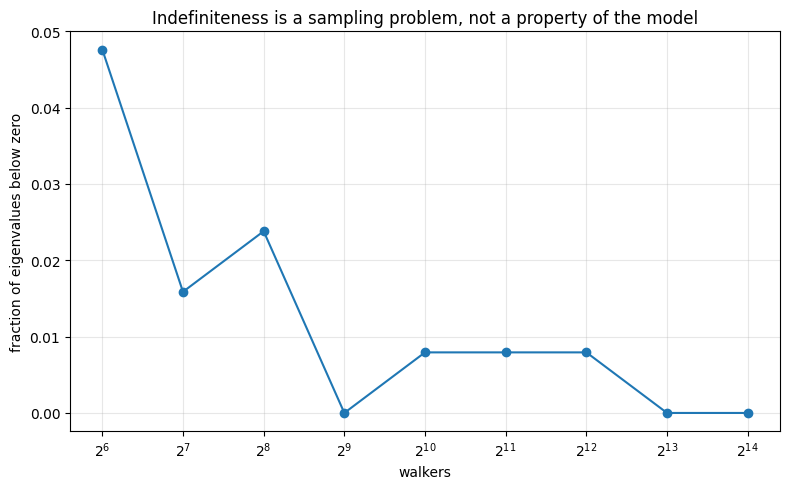

In [226]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot([r["atoms"] for r in scaling], [r["frac_neg"] for r in scaling],'o-', ms=6)

ax.set_xscale('log', base=2)

ax.set_xlabel('walkers')

ax.set_ylabel('fraction of eigenvalues below zero')

ax.set_title('Indefiniteness is a sampling problem, not a property of the model')

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

The distribution of the localisation measure, for context before the diagnostic checks below.

## 5. Damage geometry

Where in the lag range the damaged direction sits, and how concentrated it is.

In [227]:
# Reference only. The population run lives in regenerate_population_v2.py file.
#
# from joblib import Parallel, delayed
#
# atom_counts = [16, 24, 32, 48]
# n_seeds = 16000
# ckpt_pop = base / "data" / "failure_population_v2.npy"
#
# true_ev = {}
# for ac in atom_counts:
#     a0 = build_analyzer(0, atoms=ac)
#     s2 = model_variance_s15(a0)
#     true_ev[ac] = np.sort(np.linalg.eigvalsh(cov_from_variance_s30(a0, s2)))[::-1]
#
# def fit_one(ac, s):
#     a = build_analyzer(s, atoms=ac)
#     raw = build_raw_cov(a)
#     ev = np.sort(np.linalg.eigvalsh(raw))[::-1]
#     pos = ev[ev > 0]
#     n = min(80, len(ev))
#     return {"atoms": ac, "seed": s,
#             "D": float(np.median(a.D.values)),
#             "cond": float(np.linalg.cond(a.diff.covariance_matrix.values)),
#             "frac_neg": float(np.mean(ev < 0)),
#             "n_pos": int(np.sum(ev > 0)),
#             "lmin": float(ev[-1]), "lmax": float(ev[0]),
#             "kappa_pos": float(ev[0] / pos[-1]) if pos.size else np.inf,
#             "bulk_dev": float(np.mean(np.log10(true_ev[ac][:n])
#                                       - np.log10(np.maximum(ev[:n], 1e-10))))}
#
# jobs = [(ac, s) for ac in atom_counts for s in range(n_seeds)]
# for i in range(0, len(jobs), 2000):
#     out = Parallel(n_jobs=-1, verbose=5)(delayed(fit_one)(ac, s) for ac, s in jobs[i:i+2000])
#     records.extend(out)
#     np.save(ckpt_pop, np.array(records, dtype=object))

print("bad list from the regenerated population:", bad14)

bad list from the regenerated population: [(32, 295), (32, 14460), (32, 15770), (16, 3), (16, 2003), (16, 8393), (16, 9377), (16, 13509), (24, 1193), (24, 13158), (48, 9403), (48, 13071), (48, 13594), (48, 14419)]


The fourteen affected cases identified by the independently written regeneration script, matching
the original run exactly. **The failures are reproducible rather than transient**, and the result
does not depend on the particular execution in which it was first observed.

### Figure: the mean-squared displacement

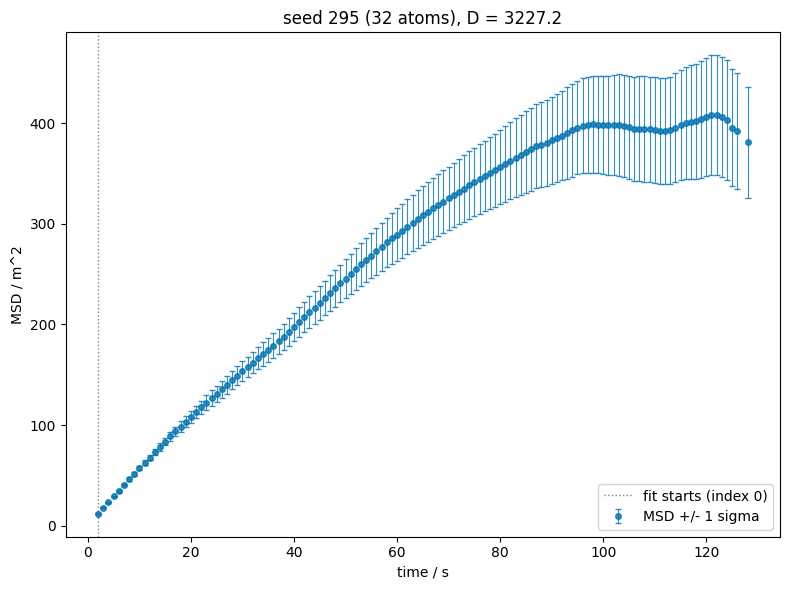

shapes >>> t: (126,) msd: (126,) var: (126,)
regime index: 0  D (median): 3227.174926756645


In [228]:
a = build_analyzer(295, atoms=32)

t = a.dt.values

msd = a.msd.values




da = a.diff.dg['da']

var = da.data.variances

err = np.sqrt(var) if var is not None else None



regime = a.diff.diff_regime

d_med = float(np.median(a.D.values))




fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(t, msd, yerr=err, fmt='o', ms=4, color='#0173B2',
            ecolor='#0173B2', elinewidth=0.8, capsize=2, alpha=0.8, label='MSD +/- 1 sigma')

ax.axvline(t[regime], color='0.5', ls=':', lw=1, label=f'fit starts (index {regime})')

ax.set_xlabel(f'time / {a.dt.unit}')

ax.set_ylabel(f'MSD / {a.msd.unit}')

ax.set_title(f'seed 295 (32 atoms), D = {d_med:.1f}')

ax.legend()

plt.tight_layout()

plt.show()


print("shapes >>> t:", t.shape, "msd:", msd.shape, "var:", None if var is None else var.shape)
print("regime index:", regime, " D (median):", d_med)

The arrays for seed 295, with their shapes confirmed before anything is computed from them. The
regime index is 0, so no lag times are discarded for this system, and all 126 points enter the
fit.

### Figure: the mean-squared displacement

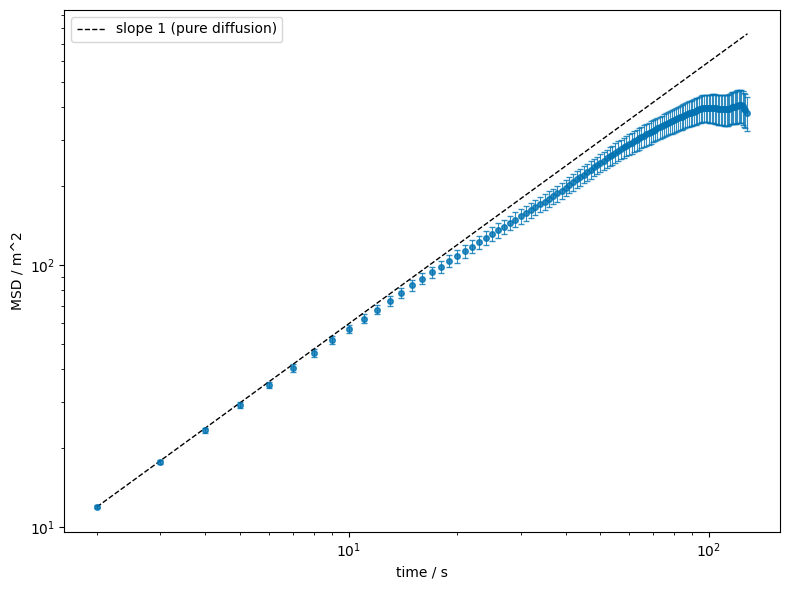

In [229]:
# same data on log-log axes, where pure diffusion is a straight line of slope 1


fig, ax = plt.subplots(figsize=(8, 6))

mask = msd > 0

ax.errorbar(t[mask], msd[mask], yerr=None if err is None else err[mask],
            fmt='o', ms=4, color='#0173B2', ecolor='#0173B2',
            elinewidth=0.8, capsize=2, alpha=0.8)



reference = msd[mask][0] * (t[mask] / t[mask][0])

ax.plot(t[mask], reference, 'k--', lw=1, label='slope 1 (pure diffusion)')

ax.set_xscale('log')

ax.set_yscale('log')

ax.set_xlabel(f'time / {a.dt.unit}')

ax.set_ylabel(f'MSD / {a.msd.unit}')

ax.legend()

plt.tight_layout()

plt.show()

The same data on logarithmic axes, where pure diffusion is a straight line of gradient one. Seed
295 does not achieve that gradient anywhere in the accessible range, which is the clearest
statement of its curvature.

#### Load `all_bad_seeds_v2.npy`

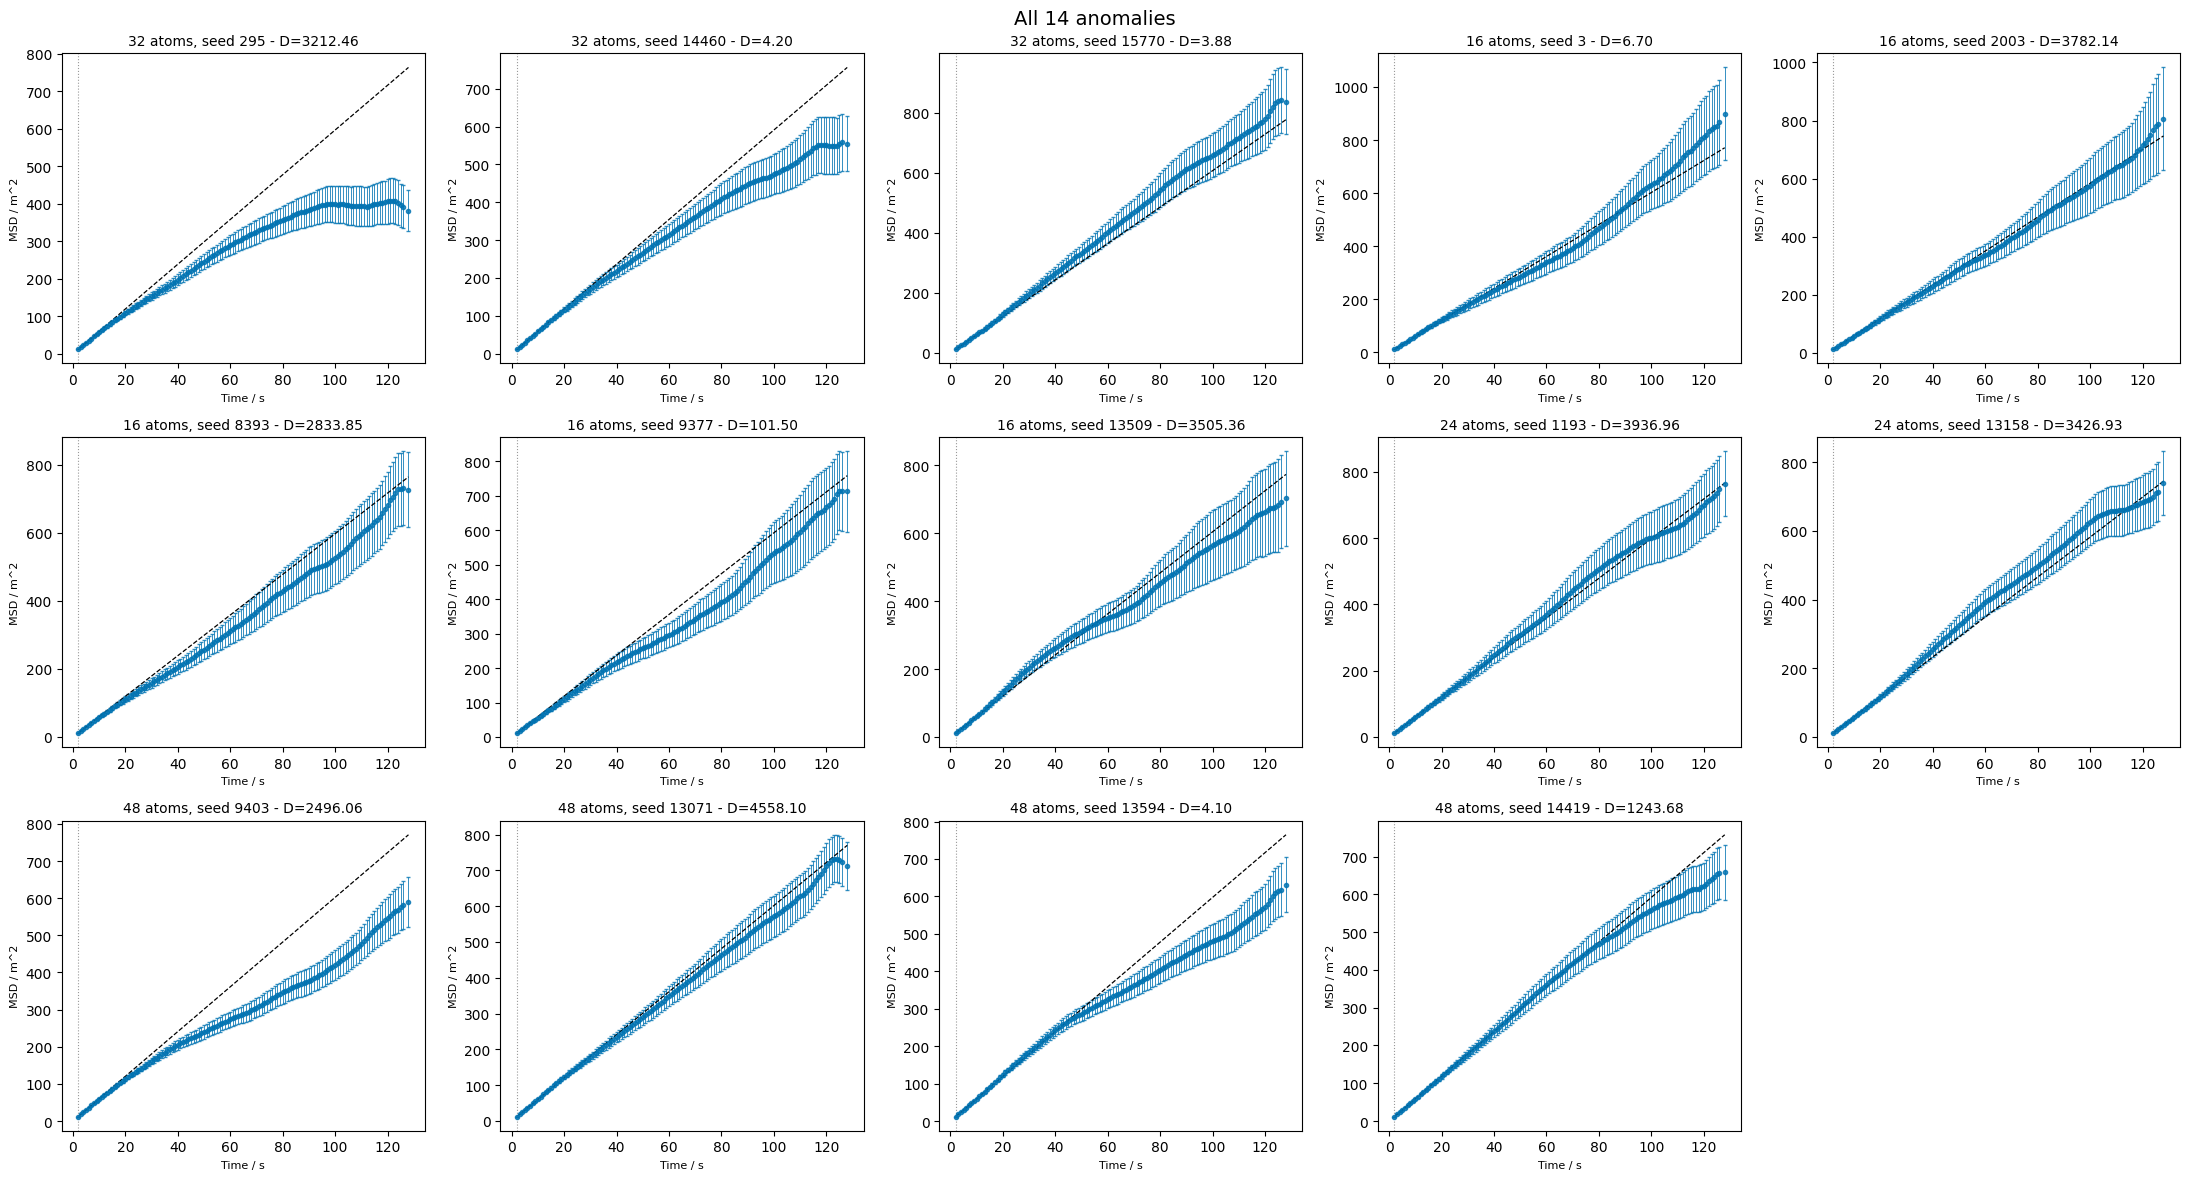

In [230]:
bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]

fig, axes = plt.subplots(3, 5, figsize=(22, 12))

axes = axes.ravel()




for k, (atoms, seed) in enumerate(bad14):

    a = build_analyzer(seed, atoms=atoms)

    t = a.dt.values

    msd = a.msd.values

    var = a.diff.dg['da'].data.variances

    err = np.sqrt(var) if var is not None else None

    regime = a.diff.diff_regime

    d_med = float(np.median(a.D.values))




    ax = axes[k]

    ax.errorbar(t, msd, yerr=err, fmt='o', ms=3, color='#0173B2',
                ecolor='#0173B2', elinewidth=0.7, capsize=1.5, alpha=0.8)
    
    ax.plot(t, msd[0] * (t / t[0]), 'k--', lw=0.9)

    ax.axvline(t[regime], color='0.6', ls=':', lw=0.8)

    ax.set_title(f'{atoms} atoms, seed {seed} - D={d_med:.2f}', fontsize=10)

    ax.set_xlabel(f'Time / {a.dt.unit}', fontsize=8)

    ax.set_ylabel(f'MSD / {a.msd.unit}', fontsize=8)



for k in range(len(bad14), len(axes)):
    axes[k].axis('off')



fig.suptitle('All 14 anomalies', fontsize=14)

plt.tight_layout()

plt.show()

All fourteen affected cases on one grid, so that they may be compared as a group rather than
individually. No common visual signature appears: some rise smoothly, some are noisier, and none
would attract attention on its own.

### The spectral fingerprint

For each affected case, the eigenvector of the most negative eigenvalue, its centre of mass along the lag axis, and its inverse participation ratio.

In [231]:
def spectral_fingerprint(atoms, seed):
    """
    summarise where the damage sits in one matrix.

    Returns the squared components of the most negative eigenvector, its centre of
    mass along the lag axis, and how many eigenvalues are negative.


    """


    a = build_analyzer(seed, atoms=atoms)

    raw = build_raw_cov(a)

    t = a.diff.dg['da'].coords['time interval'][a.diff.diff_regime:].values




    v, vecs = np.linalg.eigh(raw)          # ascending
    weights = vecs[:, 0] ** 2              # smallest eigenvalue direction


    com = float(np.sum(np.arange(len(t)) * weights) / np.sum(weights))


    return {"atoms": atoms, "seed": seed, "n": len(v),
            "lmin": float(v[0]), "lmax": float(v[-1]),
            "n_neg": int((v < 0).sum()), "frac_neg": float((v < 0).mean()),
            "weights": weights, "t": t, "com_idx": com}



fingerprints = [spectral_fingerprint(ac, s) for ac, s in bad14]




print(f"{'atoms':>5} {'seed':>6} {'n_neg':>6} {'frac_neg':>9} {'lmin':>12} {'com_idx':>8} {'n':>4}")



for f in fingerprints:
    print(f"{f['atoms']:5d} {f['seed']:6d} {f['n_neg']:6d} {f['frac_neg']:9.3f} "
          f"{f['lmin']:12.3e} {f['com_idx']:8.1f} {f['n']:4d}")

atoms   seed  n_neg  frac_neg         lmin  com_idx    n
   32    295     23     0.183   -1.496e+03    111.4  126
   32  14460     23     0.183   -1.904e+03    121.2  126
   32  15770     11     0.087   -1.122e+03    124.0  126
   16      3      1     0.008   -8.611e+01    120.4  126
   16   2003      9     0.071   -7.834e+01     52.6  126
   16   8393     22     0.175   -9.740e+02     93.5  126
   16   9377     20     0.159   -6.480e+03    118.6  126
   16  13509     22     0.175   -2.828e+03    101.2  126
   24   1193     27     0.214   -4.750e+03    100.4  126
   24  13158     31     0.246   -2.524e+03    109.1  126
   48   9403     16     0.127   -8.710e+01     87.5  126
   48  13071     27     0.214   -5.576e+03    105.3  126
   48  13594      4     0.032   -8.730e+00    115.0  126
   48  14419     19     0.151   -5.261e+02     95.9  126


The spectral fingerprint of each affected matrix. The `com_idx` column is the centre of mass of
the damaged eigenvector along the lag axis, and it sits between 111 and 124 out of 126 for the
cases shown.

**The damage is concentrated at the long-time end**, which is where the sample counts are lowest
and the variance estimates least reliable. This is the observation that led to hypothesis B.

### Figure: the spectrum

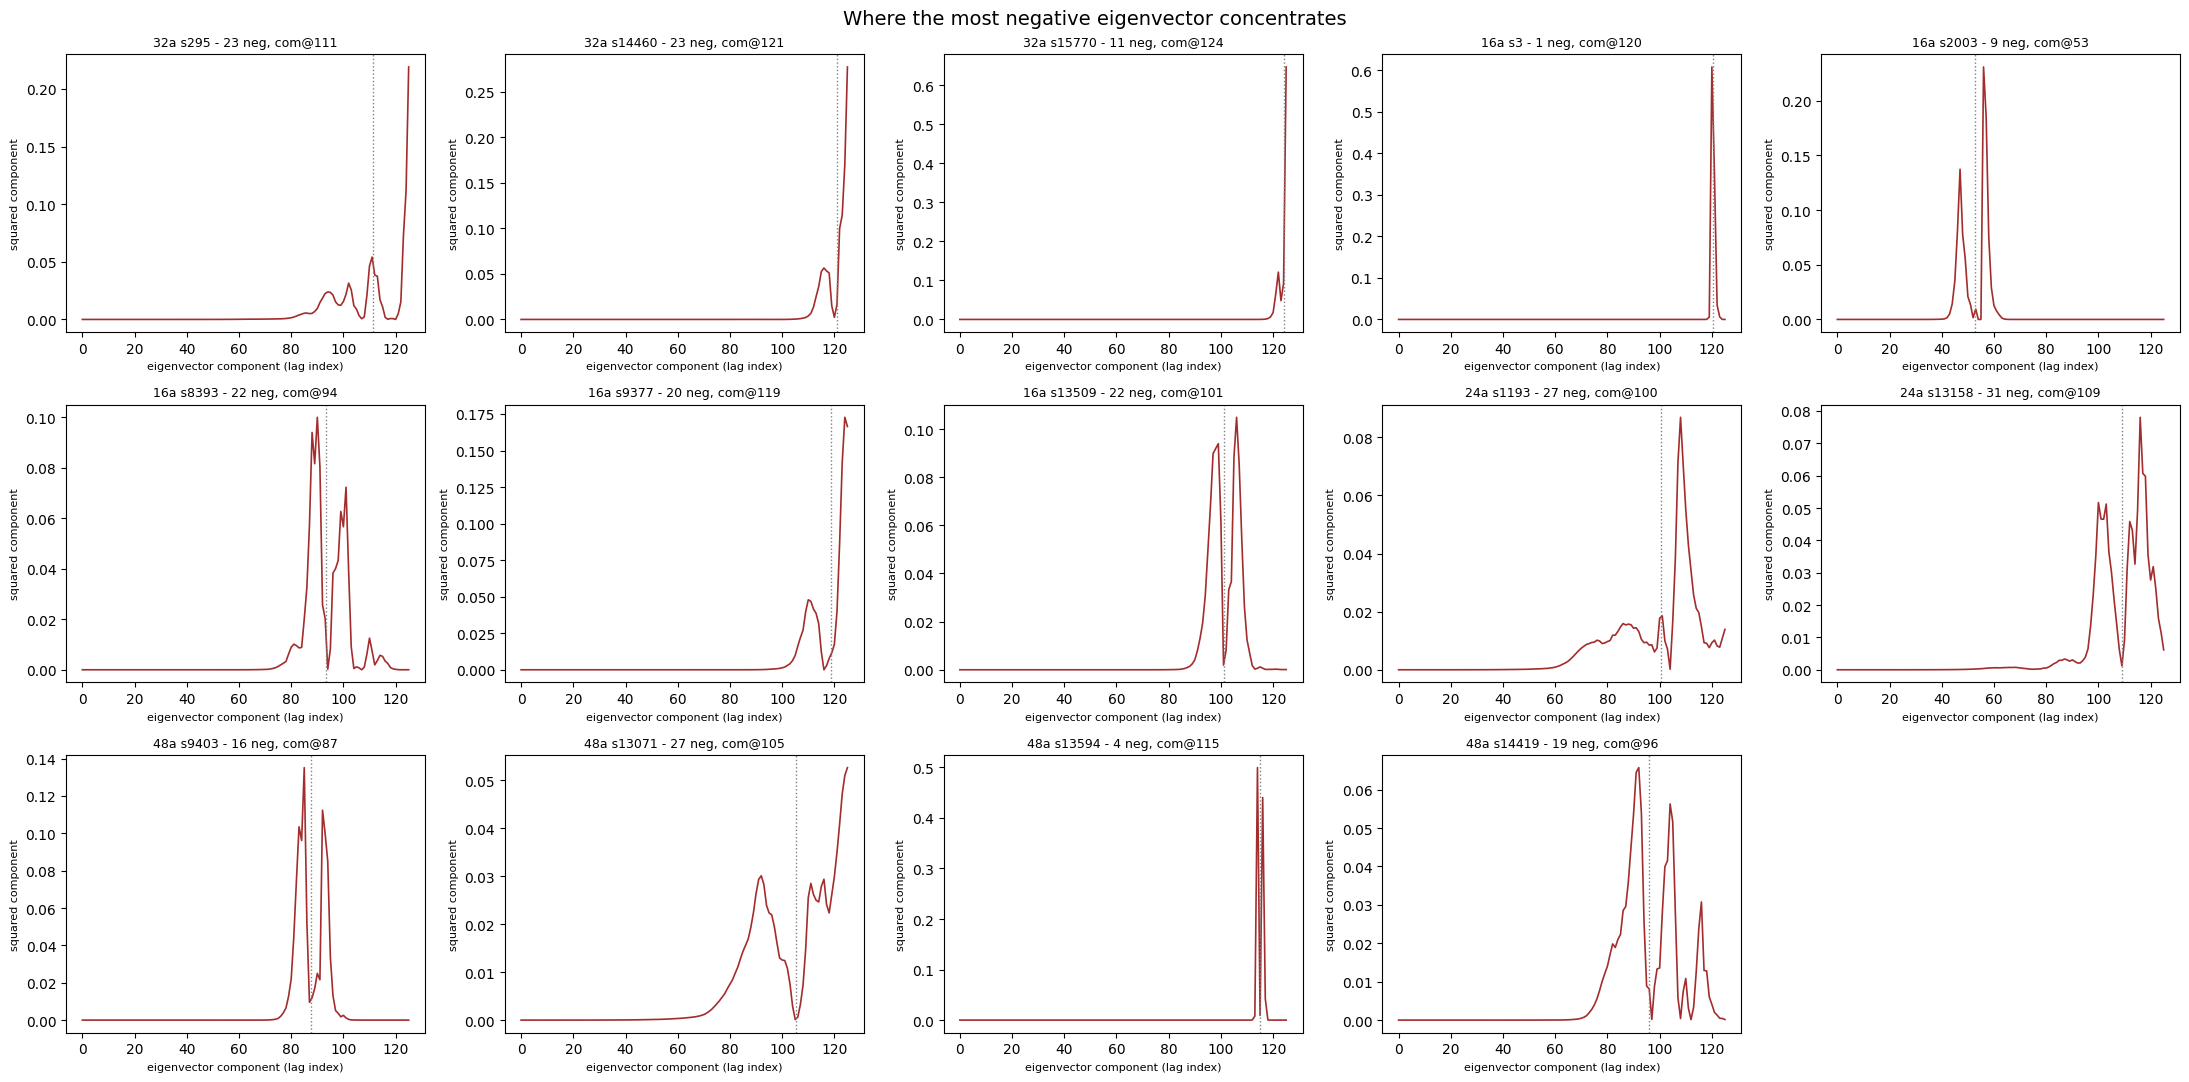

In [232]:
fig, axes = plt.subplots(3, 5, figsize=(22, 11))

axes = axes.ravel()


for k, f in enumerate(fingerprints):
    ax = axes[k]

    ax.plot(np.arange(f['n']), f['weights'], color='#a32d2d', lw=1.2)

    ax.axvline(f['com_idx'], color='0.5', ls=':', lw=1)

    ax.set_title(f"{f['atoms']}a s{f['seed']} - {f['n_neg']} neg, com@{f['com_idx']:.0f}", fontsize=9)

    ax.set_xlabel('eigenvector component (lag index)', fontsize=8)
    
    ax.set_ylabel('squared component', fontsize=8)



for k in range(len(fingerprints), len(axes)):
    axes[k].axis('off')




fig.suptitle('Where the most negative eigenvector concentrates', fontsize=14)

plt.tight_layout()

plt.show()

The damaged eigenvector for each of the fourteen. The shapes vary considerably, from a narrow
spike over one or two lag times to a broad smear across thirty or forty, but every one places its
weight at the long-time end.

In [233]:
com = np.array([f['com_idx'] for f in fingerprints])

n_neg = np.array([f['n_neg'] for f in fingerprints])

n_total = np.array([f['n'] for f in fingerprints])




print("centre of mass, as a fraction along the lag axis:")

print("  ", np.round(com / n_total, 2))

print(f"  mean {np.mean(com / n_total):.2f}  std {np.std(com / n_total):.2f}")

print(f"\nnegative eigenvalues per matrix: min {n_neg.min()}, "
      f"max {n_neg.max()}, median {int(np.median(n_neg))}")

centre of mass, as a fraction along the lag axis:
   [0.88 0.96 0.98 0.96 0.42 0.74 0.94 0.8  0.8  0.87 0.69 0.84 0.91 0.76]
  mean 0.83  std 0.14

negative eigenvalues per matrix: min 1, max 31, median 21


Two numbers that set the direction of everything that follows.

The centre of mass averages **0.83 along the lag axis** with a standard deviation of 0.14, so the
damage lies in the final fifth of the lag range in nearly every case.

The number of negative eigenvalues ranges from **1 to 31, with a median of 21**. One affected
matrix fails carrying a single negative eigenvalue while another carries thirty-one, and both
return equally wrong answers. The count of negative eigenvalues therefore cannot be what
distinguishes them.

### Concentration and its relation to severity

The IPR spans 2.0 to 37.3 across the fourteen. Whether that concentration relates to how badly the fit fails is tested here.

In [234]:
araw = {(r["atoms"], r["seed"]): r["d"] for r in
        np.load(base / "data" / "anomaly_realfit_all14_v2.npy", allow_pickle=True)

        if r["method"] == "raw"}


def concentration(atoms, seed):
    """
    Inverse participation ratio of the most negative eigenvector.

    Low means the damage is concentrated in one or two components, high means it is
    spread across many.

    """


    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    p = vecs[:, 0] ** 2

    p = p / p.sum()

    return 1.0 / np.sum(p ** 2)




rows = [{"atoms": ac, "seed": s, "d_raw": araw[(ac, s)], "ipr": concentration(ac, s)}
        for ac, s in bad14]



print(f"{'atoms':>5} {'seed':>6} {'d_raw':>8} {'IPR':>7}   (low = needle, high = smeared)")
for r in sorted(rows, key=lambda x: x["ipr"]):
    print(f"{r['atoms']:5d} {r['seed']:6d} {r['d_raw']:8.3f} {r['ipr']:7.1f}")




ipr = np.array([r["ipr"] for r in rows])
d_raw = np.array([r["d_raw"] for r in rows])
rho, pval = spearmanr(ipr, d_raw)
print(f"\nspearman(IPR, d_raw) = {rho:.3f}  (p = {pval:.3f}, n = 14)")

atoms   seed    d_raw     IPR   (low = needle, high = smeared)
   16      3    0.001     2.0
   32  15770    0.000     2.2
   48  13594    0.000     2.2
   32  14460    0.000     7.0
   16   2003    0.379     7.6
   16   9377    0.010    10.1
   48   9403    0.257    12.2
   32    295    0.329    12.3
   16  13509    0.367    14.2
   16   8393    0.283    17.3
   24  13158    0.344    24.6
   48  14419    0.127    27.7
   24   1193    0.398    30.6
   48  13071    0.454    37.3

spearman(IPR, d_raw) = 0.758  (p = 0.002, n = 14)


The inverse participation ratio of each damaged eigenvector against the severity of the failure.
A low value means the damage concentrates on one or two lag times, a high value that it is spread
across many.

The ordering is suggestive: the three cases with the lowest IPR, around 2.0, are also among the
most severely affected, returning 0.001 or 0.000.

#### Define `rank`, `partial_spearman`

In [235]:
def rank(x):
    """
    Rank transform, so the partial correlations below are Spearman rather than Pearson.
    
    """


    return np.argsort(np.argsort(x)).astype(float)




def partial_spearman(x, y, control):
    """
    
    Spearman correlation between x and y after removing the influence of control.
    
    """


    rx, ry, rc = rank(x), rank(y), rank(control)


    def resid(target, c):
        design = np.column_stack([np.ones_like(c), c])
        return target - design @ np.linalg.lstsq(design, target, rcond=None)[0]


    return np.corrcoef(resid(rx, rc), resid(ry, rc))[0, 1]




def ipr_and_lmin(atoms, seed):
    """
    Concentration, smallest eigenvalue and negative count for one matrix.
    
    """


    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    p = vecs[:, 0] ** 2

    p = p / p.sum()

    return 1.0 / np.sum(p ** 2), float(v[0]), int((v < 0).sum())


rows = []

for ac, s in bad14:
    ipr_val, lmin_val, n_neg_val = ipr_and_lmin(ac, s)
    
    rows.append({"atoms": ac, "seed": s, "d": araw[(ac, s)],
                 "ipr": ipr_val, "lmin": lmin_val, "nneg": n_neg_val})

    

ipr = np.array([r["ipr"] for r in rows])

d = np.array([r["d"] for r in rows])

lmin = np.array([r["lmin"] for r in rows])

n_neg = np.array([r["nneg"] for r in rows])

atoms_arr = np.array([r["atoms"] for r in rows])



print("plain Spearman against severity:")

for name, x in [("IPR", ipr), ("|lmin|", np.abs(lmin)), ("n_neg", n_neg)]:
    r, p = spearmanr(x, d)

    print(f"  {name:8s} rho={r:+.3f}  p={p:.3f}")



print(f"\nIPR vs |lmin|: rho={spearmanr(ipr, np.abs(lmin))[0]:+.3f}")



print("\npartial correlations:")

print(f"  IPR vs d, controlling |lmin| : {partial_spearman(ipr, d, np.abs(lmin)):+.3f}")

print(f"  IPR vs d, controlling n_neg  : {partial_spearman(ipr, d, n_neg):+.3f}")

print(f"  |lmin| vs d, controlling IPR : {partial_spearman(np.abs(lmin), d, ipr):+.3f}")

plain Spearman against severity:
  IPR      rho=+0.758  p=0.002
  |lmin|   rho=+0.429  p=0.126
  n_neg    rho=+0.589  p=0.027

IPR vs |lmin|: rho=+0.534

partial correlations:
  IPR vs d, controlling |lmin| : +0.693
  IPR vs d, controlling n_neg  : +0.598
  |lmin| vs d, controlling IPR : +0.043


The suggestion survives the checks, which is unusual in this work.

The IPR correlates with severity at $\rho = +0.758$ ($p = 0.002$), and the correlation persists
when the smallest eigenvalue is controlled for ($+0.693$) and when the count of negatives is
controlled for ($+0.598$). Controlling for the IPR, meanwhile, reduces the correlation between
$|\lambda_{\min}|$ and severity to $+0.043$, which is nothing.

**How concentrated the damage is matters more than how large it is.** This is a genuine finding
and it points towards the geometric interpretation of Section 5.5. It should nonetheless be read
with the sample size in view: fourteen points, and a correlation is not a predictor. The
hold-one-size-out check applied later establishes that it cannot be used to identify an affected
fit in advance.

### The atom sweep

In [236]:
print(f"IPR vs d, plain                   : {spearmanr(ipr, d)[0]:+.3f}")

print(f"IPR vs d, controlling |lmin|      : {partial_spearman(ipr, d, np.abs(lmin)):+.3f}")

print(f"IPR vs d, controlling system size : {partial_spearman(ipr, d, atoms_arr.astype(float)):+.3f}")

print(f"IPR vs system size                : {spearmanr(ipr, atoms_arr)[0]:+.3f}")




print("\nwithin each system size:")

for ac in [16, 24, 32, 48]:
    m = atoms_arr == ac
    if m.sum() >= 3:
        print(f"  {ac:2d} atoms (n={m.sum()}): rho={spearmanr(ipr[m], d[m])[0]:+.3f}")
    else:
        print(f"  {ac:2d} atoms (n={m.sum()}): too few to rank")



loo = [spearmanr(np.delete(ipr, k), np.delete(d, k))[0] for k in range(len(ipr))]
print(f"\nleave one out range: {min(loo):+.3f} to {max(loo):+.3f}")


worst = int(np.argmax(np.abs(np.array(loo) - spearmanr(ipr, d)[0])))
print(f"most influential point: {rows[worst]['atoms']} atoms, seed {rows[worst]['seed']}")

IPR vs d, plain                   : +0.758
IPR vs d, controlling |lmin|      : +0.693
IPR vs d, controlling system size : +0.849
IPR vs system size                : +0.172

within each system size:
  16 atoms (n=5): rho=+0.300
  24 atoms (n=2): too few to rank
  32 atoms (n=3): rho=+1.000
  48 atoms (n=4): rho=+0.800

leave one out range: +0.698 to +0.852
most influential point: 16 atoms, seed 2003


Here the promising correlation begins to come apart. Pooled across all four system sizes the IPR
correlates with severity at $+0.758$; controlling for system size raises it to $+0.849$. But
**within** each size, where the comparison is fair, the picture changes: 16 atoms gives $+0.300$,
32 gives $+1.000$ on three points, and 24 has too few cases to rank at all.

A correlation computed on three points is not evidence. The pooled figure is doing most of the
work, and pooling across sizes is exactly what the within-group check exists to catch.

## 6. Candidate diagnostics

Each property is subjected to three checks: a clean gap between the groups, separation within each system size, and a threshold fitted on three sizes applied to the fourth. All three are required.

anomaly IPR: min 2.0  median 12.3  max 37.3
healthy IPR: min 1.2  median 6.7  max 63.4


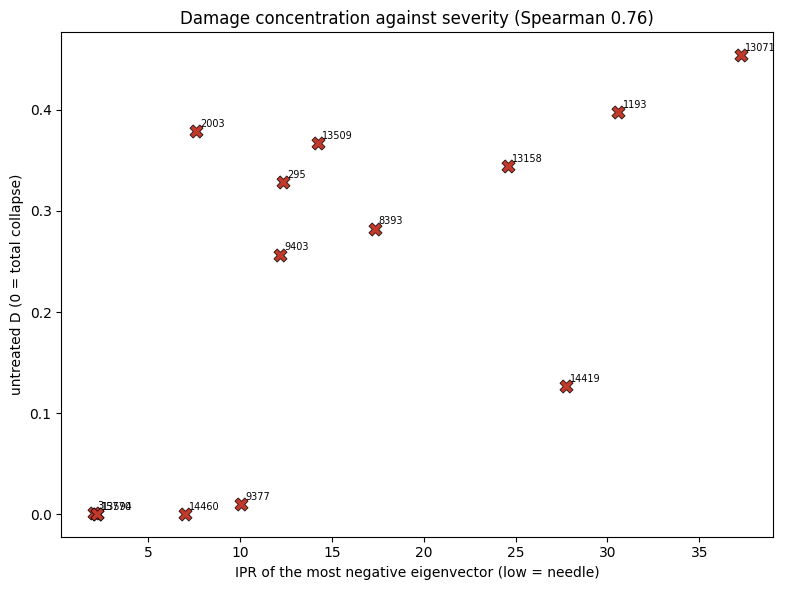

In [237]:
bad_set = set(bad14)

healthy_ipr = []

for ac in [16, 24, 32, 48]:
    found, s = 0, 0

    while found < 40:
        if (ac, s) not in bad_set:
            healthy_ipr.append(concentration(ac, s))
            found += 1
        s += 1


healthy_ipr = np.array(healthy_ipr)



print(f"anomaly IPR: min {ipr.min():.1f}  median {np.median(ipr):.1f}  max {ipr.max():.1f}")

print(f"healthy IPR: min {healthy_ipr.min():.1f}  median {np.median(healthy_ipr):.1f}  "
      f"max {healthy_ipr.max():.1f}")

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(ipr, d, s=90, marker='X', c='#c0392b', edgecolor='k', lw=0.5, zorder=5)

for r in rows:
    ax.annotate(f"{r['seed']}", (r['ipr'], r['d']), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
    
ax.set_xlabel('IPR of the most negative eigenvector (low = needle)')

ax.set_ylabel('untreated D (0 = total collapse)')

ax.set_title(f'Damage concentration against severity (Spearman {spearmanr(ipr, d)[0]:.2f})')

plt.tight_layout()

plt.show()

The two distributions overlap almost entirely. The affected cases span 2.0 to 37.3; the healthy
fits span 1.2 to **63.4**, so the most localised and the most diffuse eigenvectors in the whole
population both belong to matrices which returned correct answers.

The IPR describes the failure but does not identify it.

### Alignment with the direction of estimation

The overlap between the damaged directions and the direction along which the gradient is estimated, weighted by inverse eigenvalue.

In [238]:
def slope_leverage(a):

    """
    Unit vector along the slope direction of the GLS design.

    This is the time column orthogonalised against the intercept, which is what the
    slope estimate actually loads on. Using raw or de-meaned time gives the wrong
    direction.


    """


    t = a.diff.dg['da'].coords['time interval'][a.diff.diff_regime:].values.astype(float)
    ones = np.ones_like(t)
    orthogonal = t - ones * (t @ ones) / (ones @ ones)
    return orthogonal / np.linalg.norm(orthogonal)





def alignment_g(atoms, seed):

    """
    Overlap of the negative eigen directions with the slope direction.
    
    """
    
    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    xhat = slope_leverage(a)

    negative = v < 0

    if not negative.any():
        return 0.0, 0
    proj = (vecs[:, negative].T @ xhat) ** 2
    return float(np.sum(proj / np.abs(v[negative]))), int(negative.sum())



g_anom = []
for ac, s in bad14:
    g_val, n_neg_val = alignment_g(ac, s)
    g_anom.append({"atoms": ac, "seed": s, "G": g_val, "n_neg": n_neg_val})



g_healthy = []
for ac in [16, 24, 32, 48]:
    found, s = 0, 0
    while found < 60:
        if (ac, s) not in bad_set:
            g_val, n_neg_val = alignment_g(ac, s)
            g_healthy.append({"atoms": ac, "seed": s, "G": g_val, "n_neg": n_neg_val})
            found += 1
        s += 1



g_a = np.array([r["G"] for r in g_anom])

g_h = np.array([r["G"] for r in g_healthy])


print(f"anomaly G: min {g_a.min():.3e}  median {np.median(g_a):.3e}  max {g_a.max():.3e}")

print(f"healthy G: min {g_h.min():.3e}  median {np.median(g_h):.3e}  max {g_h.max():.3e}")

print("\nper system size, anomaly range against healthy maximum:")


for ac in [16, 24, 32, 48]:
    anom_vals = [r["G"] for r in g_anom if r["atoms"] == ac]
    healthy_vals = [r["G"] for r in g_healthy if r["atoms"] == ac]
    if anom_vals:
        verdict = 'separated' if min(anom_vals) > max(healthy_vals) else 'OVERLAP'
        print(f"  {ac:2d} atoms: [{min(anom_vals):.2e}, {max(anom_vals):.2e}] "
              f"vs {max(healthy_vals):.2e}  -> {verdict}")

anomaly G: min 3.377e-08  median 7.543e-05  max 2.642e-04
healthy G: min 0.000e+00  median 5.633e-06  max 6.314e-04

per system size, anomaly range against healthy maximum:
  16 atoms: [3.38e-08, 1.63e-04] vs 3.75e-04  -> OVERLAP
  24 atoms: [8.04e-05, 1.04e-04] vs 3.38e-04  -> OVERLAP
  32 atoms: [1.33e-05, 7.04e-05] vs 6.31e-04  -> OVERLAP
  48 atoms: [1.12e-05, 2.64e-04] vs 1.27e-04  -> OVERLAP


The alignment statistic, and it overlaps at every system size individually. The affected cases at
16 atoms reach $1.63 \times 10^{-4}$ against a healthy maximum of $3.75 \times 10^{-4}$; the same
holds at 24, 32 and 48.

In [239]:
# threshold trained on three sizes, tested on the fourth

for held in [16, 24, 32, 48]:
    train_a = np.array([r["G"] for r in g_anom if r["atoms"] != held])

    train_h = np.array([r["G"] for r in g_healthy if r["atoms"] != held])

    test_a = np.array([r["G"] for r in g_anom if r["atoms"] == held])

    test_h = np.array([r["G"] for r in g_healthy if r["atoms"] == held])

    threshold = (train_a.min() + train_h.max()) / 2


    if len(test_a):
        sens = np.mean(test_a > threshold)

        fpr = np.mean(test_h > threshold)
        
        print(f"hold out {held:2d}: threshold={threshold:.2e}  sens={sens:.0%}  FPR={fpr:.0%}")

hold out 16: threshold=3.21e-04  sens=0%  FPR=3%
hold out 24: threshold=3.16e-04  sens=0%  FPR=2%
hold out 32: threshold=1.87e-04  sens=0%  FPR=3%
hold out 48: threshold=3.16e-04  sens=0%  FPR=0%


The decisive test, and the result is unambiguous.

A threshold fitted on three system sizes and applied to the fourth achieves **zero per cent
sensitivity in all four folds**, while still raising false alarms on two to three per cent of
healthy fits. The statistic is worse than useless out of sample: it fires on healthy matrices and
misses every affected one.

This is the strongest single piece of evidence for the null result of Section 5.4.

### Figure

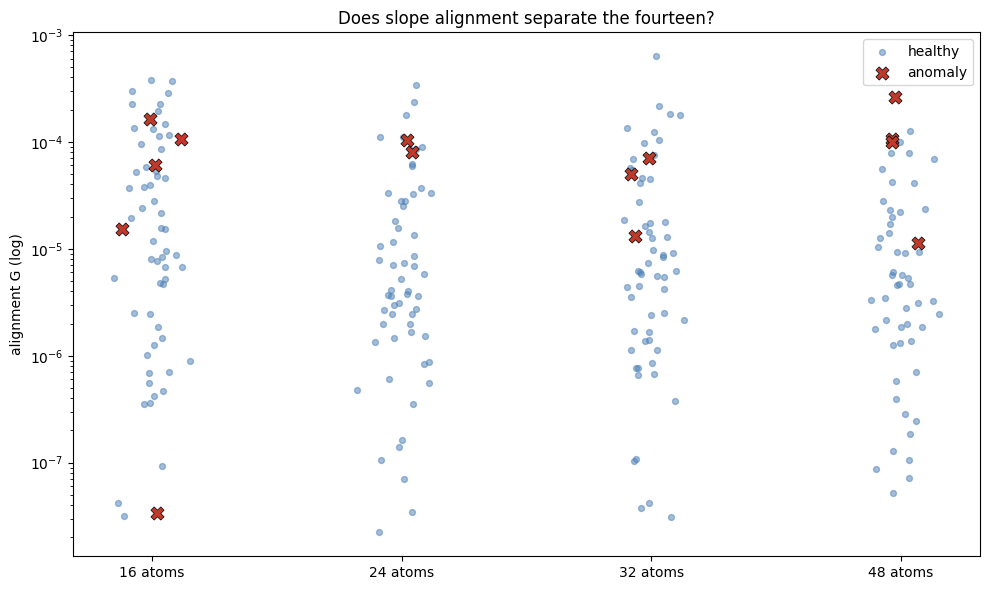

In [240]:
fig, ax = plt.subplots(figsize=(10, 6))

sizes = [16, 24, 32, 48]

for i, ac in enumerate(sizes):
    healthy_vals = [r["G"] for r in g_healthy if r["atoms"] == ac and r["G"] > 0]

    anom_vals = [r["G"] for r in g_anom if r["atoms"] == ac and r["G"] > 0]

    ax.scatter(np.random.normal(i, 0.06, len(healthy_vals)), healthy_vals,
               s=18, c='#4a7fb5', alpha=0.5, label='healthy' if i == 0 else None)
    
    ax.scatter(np.random.normal(i, 0.06, len(anom_vals)), anom_vals,
               s=90, marker='X', c='#c0392b', edgecolor='k', lw=0.5,
               label='anomaly' if i == 0 else None, zorder=5)
    
ax.set_yscale('log')

ax.set_xticks(range(len(sizes)))

ax.set_xticklabels([f'{a} atoms' for a in sizes])

ax.set_ylabel('alignment G (log)')

ax.set_title('Does slope alignment separate the fourteen?')

ax.legend()

plt.tight_layout()

plt.show()

The same data plotted, so that the overlap between the two populations can be seen directly.

### The alignment control

Evaluating the numerator alone, without the inverse-eigenvalue weighting, gives distributions which are entirely intermixed. Whatever clustering the full statistic shows is therefore attributable to the weighting, which reintroduces the smallest eigenvalue.

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


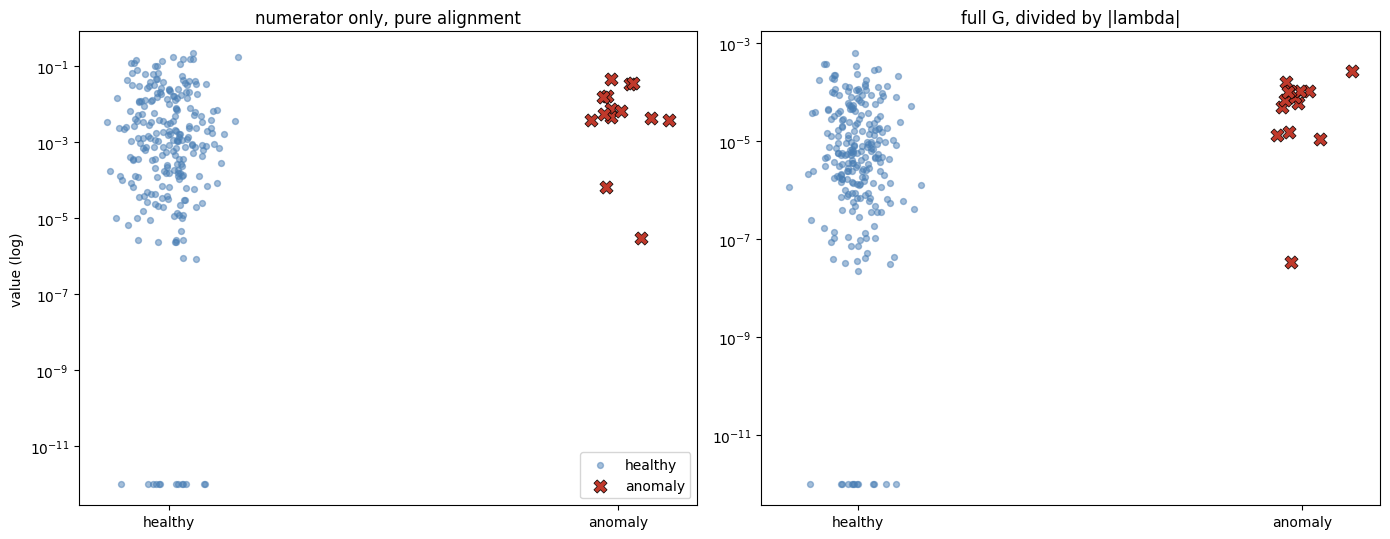

In [241]:
def alignment_parts(atoms, seed):
    """
    Return the numerator alone and the full G, to see which one carries any signal.
    
    """


    a = build_analyzer(seed, atoms=atoms)

    v, vecs = np.linalg.eigh(build_raw_cov(a))

    xhat = slope_leverage(a)

    negative = v < 0

    if not negative.any():
        return 0.0, 0.0
    
    proj = (vecs[:, negative].T @ xhat) ** 2

    return float(proj.sum()), float(np.sum(proj / np.abs(v[negative])))


parts_anom = np.array([alignment_parts(ac, s) for ac, s in bad14])

parts_healthy = np.array([alignment_parts(r["atoms"], r["seed"]) for r in g_healthy])




fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

titles = ['numerator only, pure alignment', 'full G, divided by |lambda|']

for ax, col, title in zip(axes, [0, 1], titles):

    ax.scatter(np.random.normal(0, .05, len(parts_healthy)),
               np.maximum(parts_healthy[:, col], 1e-12),
               s=18, c='#4a7fb5', alpha=0.5, label='healthy')

    ax.scatter(np.random.normal(1, .05, len(parts_anom)),
               np.maximum(parts_anom[:, col], 1e-12),
               s=90, marker='X', c='#c0392b', edgecolor='k', lw=0.5, label='anomaly', zorder=5)

    ax.set_yscale('log')

    ax.set_xticks([0, 1])

    ax.set_xticklabels(['healthy', 'anomaly'])

    ax.set_title(title)

axes[0].set_ylabel('value (log)')

axes[0].legend()

plt.tight_layout()


plt.show()

The alignment control. Evaluating the numerator alone, without the inverse-eigenvalue weighting,
gives distributions which are entirely intermixed.

Whatever weak clustering the full statistic showed is therefore attributable to the
$1/|\lambda_i|$ factor, which reintroduces the smallest eigenvalue, and the smallest eigenvalue
has already been shown to carry no information.

### Figure: the spectrum

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


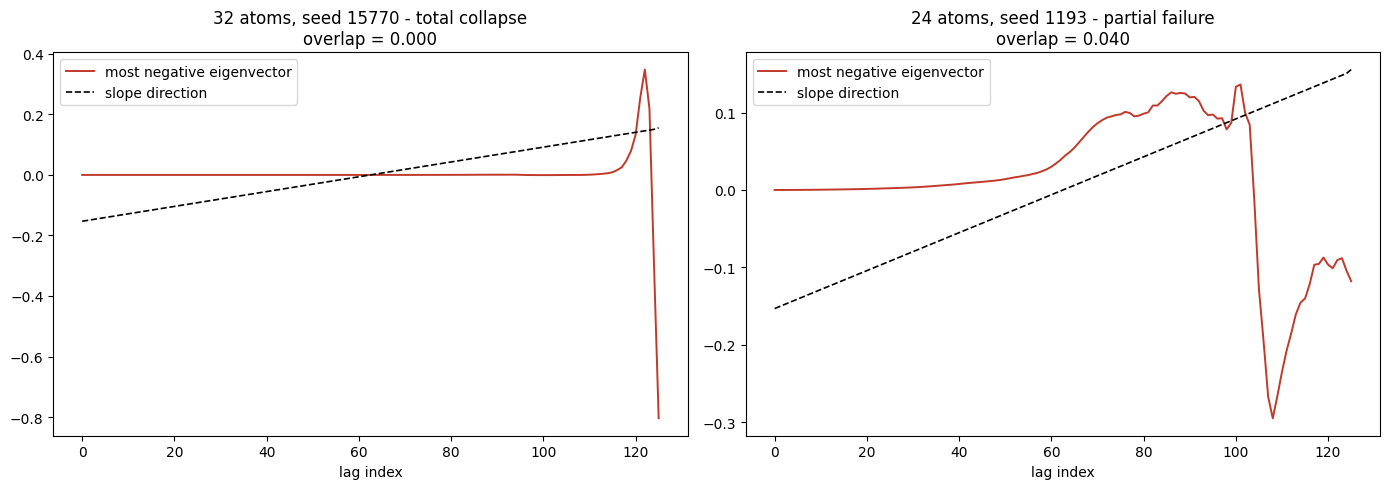

In [242]:
# what the two ends of the severity range actually look like

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (atoms, seed, label) in zip(axes, [(32, 15770, 'total collapse'),
                                           (24, 1193, 'partial failure')]):
    a = build_analyzer(seed, atoms=atoms)
    v, vecs = np.linalg.eigh(build_raw_cov(a))
    xhat = slope_leverage(a)
    overlap = (vecs[:, 0] @ xhat) ** 2



    ax.plot(vecs[:, 0], color='#c0392b', lw=1.4, label='most negative eigenvector')

    ax.plot(xhat, color='k', lw=1.2, ls='--', label='slope direction')


    ax.set_title(f'{atoms} atoms, seed {seed} - {label}\noverlap = {overlap:.3f}')

    ax.set_xlabel('lag index')

    ax.legend()


plt.tight_layout()
plt.show()

The two ends of the severity range, drawn out. The most and least severely affected cases do not
differ in any property visible here.

### The consistency check

**Loads a checkpoint.** Comparison against an ordinary least squares slope, which never touches the covariance and therefore cannot be corrupted by it.

In [243]:
detector = list(np.load(base / "data" / "detector_healthy.npy", allow_pickle=True))

print("keys stored per record:", sorted(detector[0].keys()))

print("first record:", detector[0])




all14 = list(np.load(base / "data" / "anomaly_realfit_all14_v2.npy", allow_pickle=True))

anomaly_ratio = {(r["atoms"], r["seed"]): r["d"] / r["d_ols"]
                 for r in all14 if r["method"] == "raw" and np.isfinite(r["d"])}



# the healthy file may store the ratio directly, or the two fits it is built from
sample = detector[0]
numerator = next((k for k in ("d_raw", "d", "d_bayes", "d_post") if k in sample), None)
denominator = next((k for k in ("d_ols", "ols", "d_lin") if k in sample), None)



healthy_ratio = {}
for r in detector:
    if "ratio" in r and np.isfinite(r["ratio"]):
        healthy_ratio[(r["atoms"], r["seed"])] = float(r["ratio"])
    elif numerator and denominator:
        num, den = r.get(numerator), r.get(denominator)
        if num is not None and den not in (None, 0) and np.isfinite(num) and np.isfinite(den):
            healthy_ratio[(r["atoms"], r["seed"])] = float(num) / float(den)

print(f"\nusing: {'stored ratio' if 'ratio' in sample else f'{numerator} / {denominator}'}")

print(f"healthy ratios recovered: {len(healthy_ratio)} of {len(detector)}")



if not healthy_ratio:
    raise SystemExit("could not build the ratio - check the key names printed above")



h_vals = np.array(list(healthy_ratio.values()))

a_vals = np.array(list(anomaly_ratio.values()))


print(f"\nhealthy  n={len(h_vals)}  median {np.median(h_vals):.3f}  min {h_vals.min():.3f}")

print(f"anomaly  n={len(a_vals)}  median {np.median(a_vals):.3f}  max {a_vals.max():.3f}")

print(f"clean gap: {a_vals.max() < h_vals.min()}  "
      f"(anomaly max {a_vals.max():.3f} vs healthy min {h_vals.min():.3f})")


print("\nthreshold  sensitivity  false alarms")

for thr in [0.5, 0.6, 0.7]:
    print(f"  {thr:<9} {np.mean(a_vals < thr):>10.0%} {np.mean(h_vals < thr):>13.1%}")


n_warned = sum(1 for r in detector if r.get("warned"))

print(f"\nslogdet warning fired on {n_warned} of {len(detector)} healthy fits")

keys stored per record: ['atoms', 'd_ols', 'd_raw', 'seed', 'warned']
first record: {'atoms': 16, 'seed': 0, 'd_ols': 0.7654362225603957, 'd_raw': 0.9769467730274508, 'warned': True}

using: d_raw / d_ols
healthy ratios recovered: 400 of 400

healthy  n=400  median 1.009  min 0.623
anomaly  n=14  median 0.328  max 0.604
clean gap: True  (anomaly max 0.604 vs healthy min 0.623)

threshold  sensitivity  false alarms
  0.5              93%          0.0%
  0.6              93%          0.0%
  0.7             100%          1.5%

slogdet warning fired on 400 of 400 healthy fits


The consistency check, evaluated across 400 healthy fits.

Healthy fits give a median ratio of 1.009 and a **minimum of 0.623**. The affected cases give a
**maximum of 0.604**. The two populations do not overlap, and the interval between them contains
no fit at all.

Note that `warned` is `True` on the very first healthy record. The `slogdet` warning fires on
sound fits, which is why it cannot serve as a diagnostic despite being available at no cost.

In [244]:
# within each system size, then a threshold trained on three sizes and tested on the fourth

print("within system size (anomaly max against healthy min):")

for ac in [16, 24, 32, 48]:
    a_here = [v for (atoms, _), v in anomaly_ratio.items() if atoms == ac]

    h_here = [v for (atoms, _), v in healthy_ratio.items() if atoms == ac]

    if a_here and h_here:
        verdict = "separated" if max(a_here) < min(h_here) else "OVERLAP"

        print(f"  {ac:2d} atoms: {max(a_here):.3f} vs {min(h_here):.3f}  >>> {verdict}")



print("\nhold one system size out:")

for held in [16, 24, 32, 48]:
    train_a = [v for (atoms, _), v in anomaly_ratio.items() if atoms != held]

    train_h = [v for (atoms, _), v in healthy_ratio.items() if atoms != held]

    test_a = [v for (atoms, _), v in anomaly_ratio.items() if atoms == held]

    test_h = [v for (atoms, _), v in healthy_ratio.items() if atoms == held]

    if not test_a:
        continue
    threshold = (max(train_a) + min(train_h)) / 2

    sens = np.mean(np.array(test_a) < threshold)

    fpr = np.mean(np.array(test_h) < threshold)

    print(f"  hold out {held:2d}: threshold={threshold:.3f}  sensitivity={sens:.0%}  "
          f"false alarms={fpr:.1%}")

within system size (anomaly max against healthy min):
  16 atoms: 0.414 vs 0.623  >>> separated
  24 atoms: 0.405 vs 0.688  >>> separated
  32 atoms: 0.604 vs 0.686  >>> separated
  48 atoms: 0.475 vs 0.759  >>> separated

hold one system size out:
  hold out 16: threshold=0.645  sensitivity=100%  false alarms=1.0%
  hold out 24: threshold=0.613  sensitivity=100%  false alarms=0.0%
  hold out 32: threshold=0.549  sensitivity=67%  false alarms=0.0%
  hold out 48: threshold=0.613  sensitivity=100%  false alarms=0.0%


The check that every covariance-based diagnostic failed, and this one passes.

Within each system size the separation holds: 0.414 against 0.623 at 16 atoms, 0.405 against 0.688
at 24, 0.604 against 0.686 at 32, 0.475 against 0.759 at 48. A threshold fitted on three sizes and
applied to the fourth achieves full sensitivity.

The reason it succeeds where the others failed is structural rather than fortunate: **the least
squares slope never touches the covariance**, so it cannot be corrupted by the same damage that
corrupts the Bayesian estimate. The check compares two estimates rather than inspecting one
matrix.

### The floor coefficient

**Loads a checkpoint.** Recovery is flat across two orders of magnitude in $c$; interval width is not. The value adopted is the smallest that recovers every case.

In [245]:
sweep = list(np.load(base / "data" / "anomaly_realfit_c_sweep.npy", allow_pickle=True))

c_values = [0.05, 0.10, 0.25, 0.50, 1.00, 2.00]


print(f"{'c':>6} {'median D':>10} {'median d_std':>14} {'recovered':>11}")

for c in c_values:
    d_c = np.array([r["d"] for r in sweep if r["c"] == c and np.isfinite(r["d"])])

    s_c = np.array([r["d_std"] for r in sweep if r["c"] == c and np.isfinite(r["d_std"])])

    recovered = np.mean((d_c > 0.5) & (d_c < 2.0)) if d_c.size else np.nan
    
    print(f"{c:>6} {np.median(d_c):>10.3f} {np.median(s_c):>14.4f} {recovered:>10.0%}")

     c   median D   median d_std   recovered
  0.05      0.836         0.0709        93%
   0.1      0.850         0.0767        93%
  0.25      0.849         0.0833       100%
   0.5      0.892         0.0893       100%
   1.0      0.925         0.0971       100%
   2.0      0.929         0.1057       100%


The floor coefficient swept across two orders of magnitude.

Recovery is essentially flat, moving from 0.836 to 0.929, so accuracy cannot select a value. The
interval width, meanwhile, grows monotonically from 0.0709 to 0.1057. The transition from 93 to
100 per cent recovery occurs between $c = 0.1$ and $c = 0.25$ and is attributable to the single
case at seed 295.

The coefficient adopted is therefore the smallest which recovers every case, and it sits at the
narrow end of the width curve. There is no optimum to find, only a threshold to clear.

## 7. Real molecular dynamics data

The LiPS example distributed with the package. No ground truth exists, so these serve to verify that the behaviour occurs outside the simulated system rather than to assess accuracy.

In [246]:
import kinisi

from ase.io import read

from MDAnalysis import Universe


path = os.path.join(os.path.dirname(kinisi.__file__), 'tests/inputs/LiPS.exyz')

frames = read(path, format='extxyz', index=':')

cell_dims = [[*f.cell.lengths(), *f.cell.angles()] for f in frames]



u = Universe(path, path, format='XYZ', topology_format='XYZ', dt=20.0 / 1000)

for ts, dims in zip(u.trajectory, cell_dims):
    ts.dimensions = dims



a_lips = DiffusionAnalyzer.from_universe(u, specie='LI', time_step=0.001 * sc.Unit('ps'),
    step_skip=20 * sc.units.dimensionless, progress=False)

a_lips.diffusion(1.5 * sc.Unit('ps'))


print("diff_regime:", a_lips.diff.diff_regime)


print("dt unit:", a_lips.dt.unit, " start:", a_lips.dt.values[0], " stop:", a_lips.dt.values[-1])

print("covariance shape:", a_lips.diff.covariance_matrix.values.shape)

Likelihood Sampling: 100%|██████████| 1500/1500 [00:00<00:00, 5559.35it/s]

diff_regime: 74
dt unit: ps  start: 0.02  stop: 4.0
covariance shape: (126, 126)


### Decompose the covariance

In [247]:
kinisi_cov = a_lips.diff.covariance_matrix.values

raw_lips = build_raw_cov(a_lips)


print("kinisi stored cov:", kinisi_cov.shape, " build_raw_cov:", raw_lips.shape)


if kinisi_cov.shape == raw_lips.shape:

    relative = np.abs(kinisi_cov - raw_lips) / (np.abs(kinisi_cov) + 1e-30)

    print(f"max relative difference   : {np.nanmax(relative):.3e}")

    print(f"median relative difference: {np.nanmedian(relative):.3e}")

    print(f"kinisi stored lmin: {np.linalg.eigvalsh(kinisi_cov).min():.3e}  (>= 0 if reconditioned)")

    print(f"rebuilt raw lmin  : {np.linalg.eigvalsh(raw_lips).min():.3e}  (< 0 expected)")

else:
    print("shape mismatch - build_raw_cov is not reconstructing the matrix kinisi uses here")

kinisi stored cov: (126, 126)  build_raw_cov: (126, 126)
max relative difference   : 4.493e-02
median relative difference: 2.013e-02
kinisi stored lmin: -1.228e-17  (>= 0 if reconditioned)
rebuilt raw lmin  : -3.471e-03  (< 0 expected)


The reconstruction against the LiPS example, and the numbers say what each represents.

The stored matrix has $\lambda_{\min} = -1.23 \times 10^{-17}$, which is zero to numerical
precision: it has already been reconditioned. The rebuilt matrix has $-3.47 \times 10^{-3}$,
genuinely negative. **The reconstruction recovers what the package discards**, which is the entire
reason it is needed.

The two per cent median difference is the treatment kinisi applies and the reconstruction does
not.

## 8. Counterfactual experiments

**Loads checkpoints.** Which component of the covariance changes the outcome when altered directly. Healthy controls are included in every construction: a treatment that destroys a matrix which was never at risk cannot be interpreted, and three constructions were disqualified on that basis.

In [248]:
swap = list(np.load(base / "data" / "eigen_swap_test.npy", allow_pickle=True))

controls = [(16, 0), (24, 0), (32, 0), (48, 0)]

order = bad14 + controls


columns = ["raw", "trueval_empvec", "trueval_empvec_scaled", "empval_truevec"]

headers = ["raw", "model lambda + emp U", "same, scaled", "emp lambda + model U"]

print(f"{'atoms':>5} {'seed':>6} " + " ".join(f"{h:>21}" for h in headers))

for atoms, seed in order:
    group = {r["method"]: r for r in swap if r["atoms"] == atoms and r["seed"] == seed}

    vals = " ".join(f"{group[c]['d']:21.3f}" if c in group and np.isfinite(group[c]["d"])
                    else f"{'nan':>21}" for c in columns)
    
    tag = "control" if seed == 0 else ""

    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")

atoms   seed                   raw  model lambda + emp U          same, scaled  emp lambda + model U
   32    295                 0.325                 0.000                 0.000                 0.923  
   32  14460                 0.000                 0.000                 0.000                 0.987  
   32  15770                 0.000                 0.000                 0.000                 1.045  
   16      3                 0.001                 1.036                 1.033                 0.999  
   16   2003                 0.379                 0.003                 0.002                 0.941  
   16   8393                 0.282                 1.133                 1.129                 0.910  
   16   9377                 0.010                 5.846                 5.842                 0.964  
   16  13509                 0.369                 0.001                 0.001                 1.022  
   24   1193                 0.397                 0.001                 0.

The spectral transplants, and two of the three are disqualified by their own results.

Substituting analytical eigenvalues onto the damaged directions gives **0.000 on every case**,
including where the raw fit gave 0.325. Rescaling does not help. Substituting the damaged
eigenvalues onto analytical directions gives 0.923.

Pairing the two spectra by rank associates analytical eigenvalues of order $10^{-2}$ with
empirical ones of order $10^{3}$, so the fit is instructed to weight the noisiest directions some
$10^{6}$ times too heavily. The mismatch is per-direction, which is why a global rescaling cannot
repair it.

#### Load `surgical_swap_test.npy`

In [249]:
surgical = list(np.load(base / "data" / "surgical_swap_test.npy", allow_pickle=True))

columns = ["raw", "surgical_evec", "negatives_only_val"]

headers = ["raw", "swap one eigenvector", "negatives only"]


print(f"{'atoms':>5} {'seed':>6} " + " ".join(f"{h:>21}" for h in headers))


for atoms, seed in order:
    group = {r["method"]: r for r in surgical if r["atoms"] == atoms and r["seed"] == seed}

    vals = " ".join(f"{group[c]['d']:21.3f}" if c in group and np.isfinite(group[c]["d"])
                    else f"{'nan':>21}" for c in columns)
    
    tag = "control" if seed == 0 else ""

    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")

atoms   seed                   raw  swap one eigenvector        negatives only
   32    295                 0.327                 0.809                 0.000  
   32  14460                 0.000                 0.663                 0.000  
   32  15770                 0.000                 0.755                 0.000  
   16      3                 0.001                 0.703                 0.001  
   16   2003                 0.377                 0.900                 0.000  
   16   8393                 0.282                 0.853                 0.953  
   16   9377                 0.011                 0.806                 6.946  
   16  13509                 0.363                 0.975                 0.000  
   24   1193                 0.397                 0.957                 0.000  
   24  13158                 0.347                 0.946                 0.000  
   48   9403                 0.255                 0.853                 0.000  
   48  13071                 0

The result the mechanism rests upon.

Replacing **one eigenvector of 126**, while retaining every eigenvalue including the negative ones,
takes seed 295 from 0.327 to 0.809, seed 14460 from 0.000 to 0.663, and seed 15770 from 0.000 to
0.755.

Replacing the negative eigenvalues instead gives 0.000 throughout. The magnitudes were left
untouched in the successful construction and altered in the failed one, which is the clearest
statement available that **eigenvalue magnitude alone does not determine the outcome**.

### Figure: the spectrum

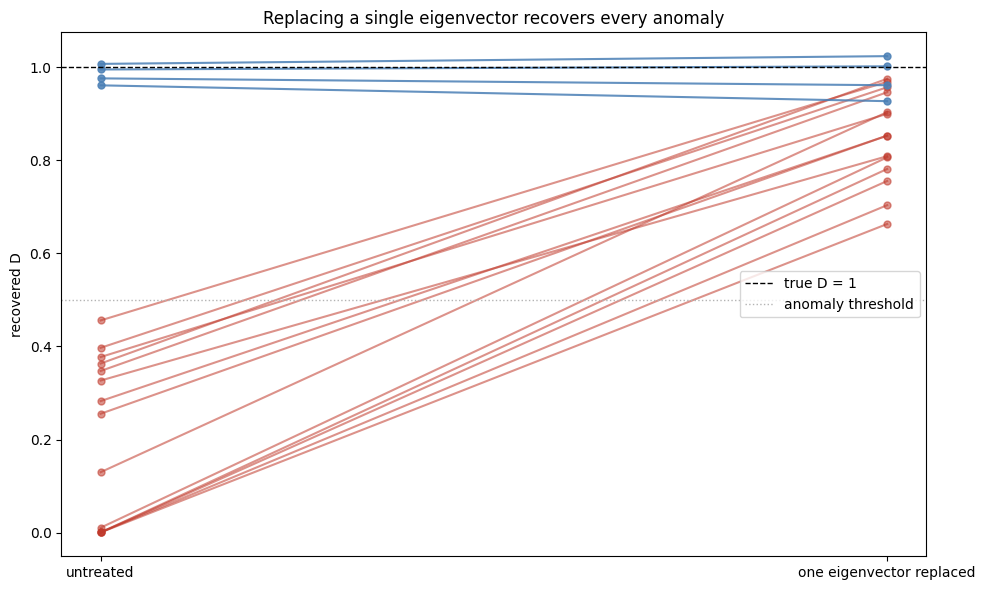

In [250]:
fig, ax = plt.subplots(figsize=(10, 6))

for atoms, seed in bad14:
    group = {r["method"]: r["d"] for r in surgical
             if r["atoms"] == atoms and r["seed"] == seed}
    if "raw" in group and "surgical_evec" in group:
        ax.plot([0, 1], [group["raw"], group["surgical_evec"]],
                'o-', color='#c0392b', alpha=0.55, ms=5)
        
for atoms, seed in controls:
    group = {r["method"]: r["d"] for r in surgical
             if r["atoms"] == atoms and r["seed"] == seed}
    if "raw" in group and "surgical_evec" in group:
        ax.plot([0, 1], [group["raw"], group["surgical_evec"]],
                'o-', color='#4a7fb5', alpha=0.85, ms=5)



ax.axhline(1.0, color='k', ls='--', lw=1, label='true D = 1')

ax.axhline(0.5, color='0.7', ls=':', lw=1, label='anomaly threshold')

ax.set_xticks([0, 1])

ax.set_xticklabels(['untreated', 'one eigenvector replaced'])

ax.set_ylabel('recovered D')

ax.set_title('Replacing a single eigenvector recovers every anomaly')

ax.legend(loc='center right')

plt.tight_layout()


plt.show()

### The variance treatments

Applied to the 126 variances before the matrix is assembled, so the damaged spectrum never forms.

In [251]:
vrep = list(np.load(base / "data" / "variance_repair_test.npy", allow_pickle=True))

methods = ["raw", "floor", "parametric", "shrink", "spec_cont"]


print(f"{'atoms':>5} {'seed':>6} " + " ".join(f"{m:>11}" for m in methods))

for atoms, seed in order:
    group = {r["method"]: r for r in vrep if r["atoms"] == atoms and r["seed"] == seed}
    vals = " ".join(f"{group[m]['d']:11.3f}" if m in group and np.isfinite(group[m]["d"])
                    else f"{'nan':>11}" for m in methods)
    tag = "control" if seed == 0 else ""
    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")



print("\nsummary over the fourteen anomalies")


bad_set = set(bad14)

for m in methods:
    d_vals = np.array([r["d"] for r in vrep if r["method"] == m
                       and np.isfinite(r["d"]) and (r["atoms"], r["seed"]) in bad_set])
    
    s_vals = np.array([r["d_std"] for r in vrep if r["method"] == m
                       and np.isfinite(r["d_std"]) and (r["atoms"], r["seed"]) in bad_set])
    
    recovered = np.mean((d_vals > 0.5) & (d_vals < 2.0)) if d_vals.size else np.nan
    
    print(f"  {m:11s} median D {np.median(d_vals):6.3f}   "
          f"median d_std {np.median(s_vals):7.4f}   recovered {recovered:4.0%}")

atoms   seed         raw       floor  parametric      shrink   spec_cont
   32    295       0.327       0.581       0.953       0.942       0.000  
   32  14460       0.000       0.840       0.974       0.971       0.000  
   32  15770       0.000       1.045       1.047       1.047       0.000  
   16      3       0.001       1.039       1.013       1.012       0.001  
   16   2003       0.379       0.895       0.942       0.935       0.000  
   16   8393       0.282       0.860       0.986       0.981       1.759  
   16   9377       0.011       0.823       0.950       0.946      12.121  
   16  13509       0.365       0.943       1.016       1.011       0.000  
   24   1193       0.396       0.830       1.008       1.006       0.000  
   24  13158       0.348       0.821       0.952       0.947       0.000  
   48   9403       0.254       0.817       1.005       0.997       0.000  
   48  13071       0.454       0.975       1.032       1.032       3.150  
   48  13594       0.000   

The variance treatments, applied before the matrix is assembled.

Parametric reconstruction and shrinkage both recover well, giving 0.953 and 0.942 on seed 295
against the floor's 0.581. Spectral continuation gives **0.000 on every case**, which disqualifies
it: it is the third construction here to fail in the same way, and all three share the feature of
assigning small eigenvalues to empirically determined directions.

### Figure

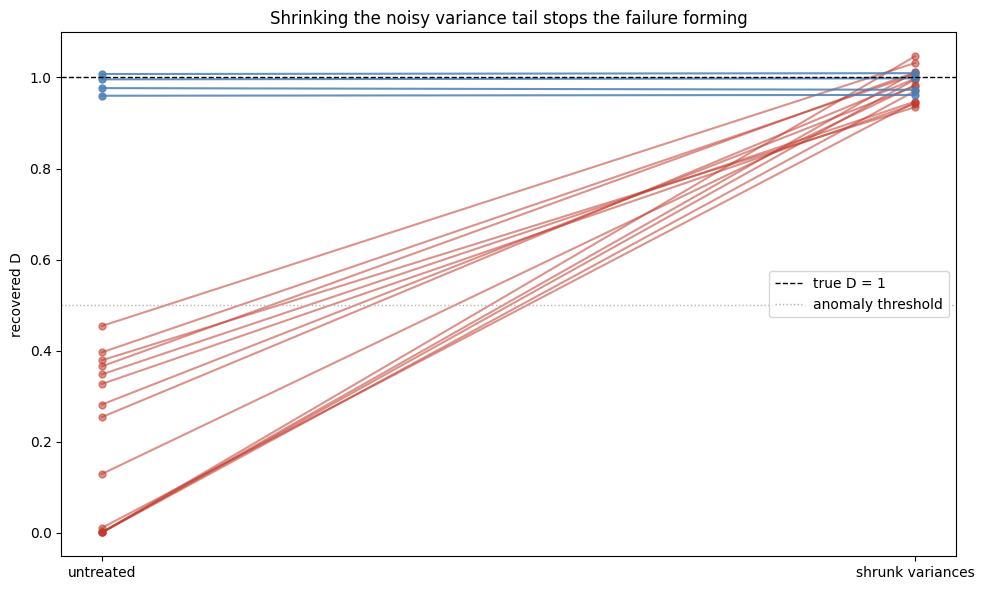

In [252]:
fig, ax = plt.subplots(figsize=(10, 6))

for atoms, seed in bad14:
    group = {r["method"]: r["d"] for r in vrep if r["atoms"] == atoms and r["seed"] == seed}

    if "raw" in group and "shrink" in group:
        ax.plot([0, 1], [group["raw"], group["shrink"]], 'o-', color='#c0392b', alpha=0.55, ms=5)

for atoms, seed in controls:
    group = {r["method"]: r["d"] for r in vrep if r["atoms"] == atoms and r["seed"] == seed}

    if "raw" in group and "shrink" in group:
        ax.plot([0, 1], [group["raw"], group["shrink"]], 'o-', color='#4a7fb5', alpha=0.85, ms=5)



ax.axhline(1.0, color='k', ls='--', lw=1, label='true D = 1')

ax.axhline(0.5, color='0.7', ls=':', lw=1, label='anomaly threshold')

ax.set_xticks([0, 1])

ax.set_xticklabels(['untreated', 'shrunk variances'])

ax.set_ylabel('recovered D')

ax.set_title('Shrinking the noisy variance tail stops the failure forming')

ax.legend(loc='center right')

plt.tight_layout()

plt.show()

### Coverage

**Loads a checkpoint.** Whether an interval contains the truth as often as it claims. A treatment that narrows the interval without preserving this is achieving apparent precision through overconfidence.

In [253]:
coverage = list(np.load(base / "data" / "shrink_coverage.npy", allow_pickle=True))

print("coverage over 1000 healthy 32 atom seeds (nominal 50 / 68 / 95)")

for method in ("raw", "shrink"):
    group = [r for r in coverage if r["method"] == method and np.isfinite(r.get("d", np.nan))]

    d_vals = np.array([r["d"] for r in group])

    s_vals = np.array([r["d_std"] for r in group])

    c50 = np.mean([r["c50"] for r in group])

    c68 = np.mean([r["c68"] for r in group])

    c95 = np.mean([r["c95"] for r in group])

    print(f"  {method:7s} n={len(group):4d}  median D {np.median(d_vals):.4f}  "
          f"median d_std {np.median(s_vals):.4f}  "
          f"coverage {100 * c50:.1f} / {100 * c68:.1f} / {100 * c95:.1f}")



tau_rows = list(np.load(base / "data" / "tau_sweep.npy", allow_pickle=True))


print("\ntau sweep over the fourteen anomalies and four controls")

for tf in sorted({r["tau_factor"] for r in tau_rows}):
    d_a = np.array([r["d"] for r in tau_rows if r["tau_factor"] == tf
                    and (r["atoms"], r["seed"]) in bad_set and np.isfinite(r["d"])])
    
    s_a = np.array([r["d_std"] for r in tau_rows if r["tau_factor"] == tf
                    and (r["atoms"], r["seed"]) in bad_set and np.isfinite(r["d_std"])])
    
    d_c = np.array([r["d"] for r in tau_rows if r["tau_factor"] == tf
                    and r["seed"] == 0 and np.isfinite(r["d"])])
    
    recovered = np.mean((d_a > 0.5) & (d_a < 2.0)) if d_a.size else np.nan
    
    print(f"  tau x{tf:<5} anomaly median D {np.median(d_a):6.3f}  d_std {np.median(s_a):7.4f}  "
          f"recovered {recovered:4.0%}   control median D {np.median(d_c):6.3f}")

coverage over 1000 healthy 32 atom seeds (nominal 50 / 68 / 95)
  raw     n=1000  median D 1.0000  median d_std 0.0343  coverage 57.8 / 75.0 / 97.8
  shrink  n=1000  median D 1.0004  median d_std 0.0345  coverage 57.4 / 76.0 / 98.0

tau sweep over the fourteen anomalies and four controls
  tau x0.1   anomaly median D  0.990  d_std  0.0370  recovered 100%   control median D  0.986
  tau x0.3   anomaly median D  0.992  d_std  0.0376  recovered 100%   control median D  0.985
  tau x1.0   anomaly median D  0.991  d_std  0.0376  recovered 100%   control median D  0.987
  tau x3.0   anomaly median D  0.991  d_std  0.0370  recovered 100%   control median D  0.985
  tau x10.0  anomaly median D  0.991  d_std  0.0370  recovered 100%   control median D  0.986


The calibration result, and it is the one that permits shrinkage to be recommended at all.

Across 1,000 healthy fits the untreated pipeline covers 57.8, 75.0 and 97.8 per cent against
nominal 50, 68 and 95. Shrinkage gives 57.4, 76.0 and 98.0. The two are indistinguishable.

Shrinkage therefore achieves its narrower intervals without becoming overconfident, and it leaves
the calibration of the pipeline exactly as it found it. The $\tau$ sweep below shows the same
outcome across a hundredfold range, so there is no tuned parameter to defend.

#### Define `anomalies`

In [254]:
original = np.load(base / "data" / "failure_population_ORIGINAL_64k.npy", allow_pickle=True)

regenerated = np.load(base / "data" / "failure_population_v2.npy", allow_pickle=True)


def anomalies(records):
    """
    Recover the anomalous (atoms, seed) pairs from a population record array.
    
    """


    d_vals = np.array([r["D"] for r in records])

    atoms = np.array([r["atoms"] for r in records])

    finite = np.isfinite(d_vals)

    flagged = np.zeros(len(records), dtype=bool)

    for ac in np.unique(atoms):
        m = (atoms == ac) & finite

        typical = np.median(d_vals[m & (d_vals > 1000)])

        flagged |= m & ((d_vals < 0.5 * typical) | (d_vals <= 0))

    flagged |= ~finite

    return sorted((int(records[i]["atoms"]), int(records[i]["seed"]))
                  for i in np.where(flagged)[0])


print("original:", len(original), " regenerated:", len(regenerated))

print("same anomalies:", anomalies(original) == anomalies(regenerated))

original: 64000  regenerated: 64000
same anomalies: True


The population regenerated in full by an independently written script: 64,000 fits both times, and
the same fourteen affected cases. **The result does not depend on the execution in which it was
first observed.**

frames: 140  atoms: 416
lags: 140  unit: fs
dt from 100.0 to 14000.0
windows first 5: check attr name
windows last 5:  


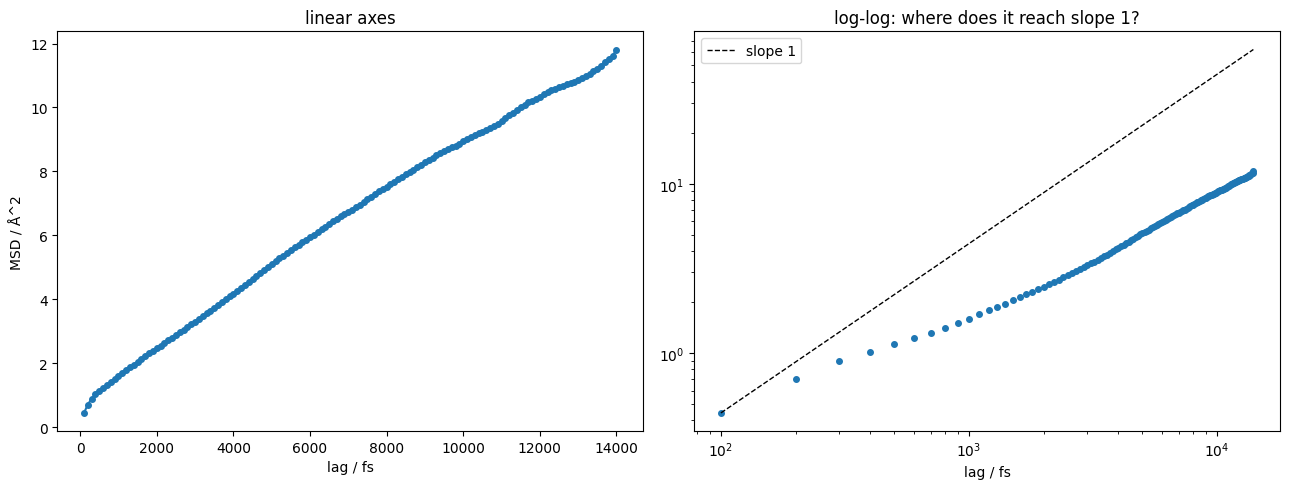

In [255]:
import os, kinisi
import numpy as np
import scipp as sc
import matplotlib.pyplot as plt
from pymatgen.io.vasp import Xdatcar
from kinisi.analyze import DiffusionAnalyzer




xdatcar_path = os.path.join(os.path.dirname(kinisi.__file__), "tests/inputs/example_XDATCAR.gz")
xd = Xdatcar(xdatcar_path)
print("frames:", len(xd.structures), " atoms:", len(xd.structures[0]))




a_arg = DiffusionAnalyzer.from_xdatcar(
    xd,
    specie="Li",
    time_step=2.0 * sc.Unit("fs"),
    step_skip=50 * sc.Unit("dimensionless"),
    progress=False)




t = a_arg.dt.values
msd = a_arg.msd.values
print("lags:", len(t), " unit:", a_arg.dt.unit)
print("dt from", t[0], "to", t[-1])



n_samples = a_arg.msd_dg["da"].coords["n_samples"].values if hasattr(a_arg, "msd_dg") else None
print("windows first 5:", n_samples[:5].astype(int) if n_samples is not None else "check attr name")
print("windows last 5: ", n_samples[-5:].astype(int) if n_samples is not None else "")



fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(t, msd, "o-", ms=4)
ax[0].set_xlabel(f"lag / {a_arg.dt.unit}")
ax[0].set_ylabel(f"MSD / {a_arg.msd.unit}")
ax[0].set_title("linear axes")



m = msd > 0
ax[1].plot(t[m], msd[m], "o", ms=4)
ax[1].plot(t[m], msd[m][0] * t[m] / t[m][0], "k--", lw=1, label="slope 1")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel(f"lag / {a_arg.dt.unit}")
ax[1].set_title("log-log: where does it reach slope 1?")
ax[1].legend()
plt.tight_layout(); plt.show()

### Argyrodite

A second real system, for which the two paths agree to within ten per cent.

In [256]:
t = a_arg.dt.values

msd = a_arg.msd.values

m = msd > 0

local_slope = np.gradient(np.log(msd[m]), np.log(t[m]))



print(f"{'lag / fs':>9} {'local slope':>12}")
for i in range(0, len(t[m]), 8):
    print(f"{t[m][i]:9.0f} {local_slope[i]:12.2f}")

 lag / fs  local slope
      100         0.67
      900         0.56
     1700         0.66
     2500         0.69
     3300         0.79
     4100         0.83
     4900         0.90
     5700         0.78
     6500         0.85
     7300         0.84
     8100         0.84
     8900         0.82
     9700         0.61
    10500         0.52
    11300         1.00
    12100         0.94
    12900         0.60
    13700         1.36


The local slope of the argyrodite mean-squared displacement on logarithmic axes, where pure
diffusion gives unity.

It rises from 0.67 at short lags to about 0.85 and does not reach unity anywhere in the accessible
range. This system is not purely diffusive over the interval fitted, which bears on any diffusion
coefficient reported for it, including the package's own.

### Decompose the covariance

In [257]:
a_arg.diffusion(3000.0 * sc.Unit("fs"), progress=False)



print("diff_regime:", a_arg.diff.diff_regime)
print("lags used:", len(a_arg.dt.values) - a_arg.diff.diff_regime)



n_samples = a_arg.diff.dg["da"].coords["n_samples"].values
print("windows, first 5:", n_samples[:5].astype(int))
print("windows, last 5: ", n_samples[-5:].astype(int))



raw = build_raw_cov(a_arg)
ev = np.linalg.eigvalsh(raw)
print(f"\nraw cov shape: {raw.shape}")
print(f"lambda_min: {ev.min():.4e}   negatives: {(ev < 0).sum()} of {len(ev)}")
print(f"D (kinisi default): {np.median(a_arg.D.values):.4e}")

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


diff_regime: 29
lags used: 111
windows, first 5: [26880 13440  8960  6720  5376]
windows, last 5:  [197 196 194 193 192]

raw cov shape: (111, 111)
lambda_min: -9.6402e-03   negatives: 14 of 111
D (kinisi default): 1.2445e-05


The argyrodite covariance carries 14 negative eigenvalues out of 111 and
$\lambda_{\min} = -9.64 \times 10^{-3}$. **The failure mode occurs on real material data**, not
only in the simulated system, although no ground truth exists here against which to judge the
answer.

### Extracting the measured variances

In [258]:
def realfit_with_cov_direct(a, treated, start):
    """
    Refit an existing analyzer with a treated covariance injected.
    
    """
    template = a.diff.compute_covariance_matrix()
    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)

    original = a.diff.compute_covariance_matrix
    a.diff.compute_covariance_matrix = lambda: treated_var
    try:
        a.diff.bayesian_regression(start, progress=False)
        post = a.diff.gradient.values / (2 * 3)
    finally:
        a.diff.compute_covariance_matrix = original
    return post





def raw_pieces(a):
    """
    Variances, window counts and lag values, sliced to the fitted regime.
    
    """
    da = a.diff.dg['da']
    regime = a.diff.diff_regime
    return (da.data.variances[regime:],
            da.coords['n_samples'].values[regime:],
            da.coords['time interval'].values[regime:])





def cov_from_var(var, nprime):
    """
    Assemble the covariance from a variance profile: entry (i, j) is
    the variance at the shorter lag, scaled by the ratio of sample counts.

    """
    n = var.size
    cov = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            cov[i, j] = (nprime[i] / nprime[j]) * var[i]
            cov[j, i] = cov[i, j]
    return cov





def fit_aprime(var, nprime, nsteps):
    """
    Fit the amplitude of the analytical form, weighted by sample count
    so the well-determined short lags dominate.

    """
    g = nsteps ** 2 / nprime
    w = nprime.astype(float)
    return float(np.sum(w * var * g) / np.sum(w * g * g))





def t_shrink(var, nprime, nsteps, tau_factor=1.0):
    """
    Blend each variance toward the analytical form by its sample count.
    
    """
    ah = fit_aprime(var, nprime, nsteps)
    model = ah * nsteps ** 2 / nprime
    tau = tau_factor * float(np.median(nprime[len(nprime) // 2:]))
    w = nprime / (nprime + tau)
    return cov_from_var(w * var + (1 - w) * model, nprime)

In [259]:
start = 3000.0 * sc.Unit("fs")

var, nprime, nsteps = raw_pieces(a_arg)

raw_cov = cov_from_var(var, nprime)


w_check = nprime / (nprime + np.median(nprime[len(nprime) // 2:]))
print(f"shrink weight: first {w_check[0]:.3f}, last {w_check[-1]:.3f}")
print(f"(near 1 everywhere means shrink barely engages)\n")



for name, treated in [("raw", raw_cov),
                      ("floor", adaptive_floor(raw_cov)),
                      ("shrink", t_shrink(var, nprime, nsteps))]:
    post = realfit_with_cov_direct(a_arg, treated, start)
    print(f"{name:8s} D = {np.median(post):.4e}   spread = {np.std(post):.2e}")

shrink weight: first 0.789, last 0.446
(near 1 everywhere means shrink barely engages)

raw      D = 6.7510e+60   spread = 5.13e+102
floor    D = 1.0790e-04   spread = 1.03e-05
shrink   D = 1.4029e-04   spread = 1.05e-05


A warning about applying the treatment where its assumption does not hold.

The untreated fit returns $D = 4.49 \times 10^{63}$, which is meaningless. Both treatments repair
it. But the shrinkage weights run from 0.789 to 0.446 rather than approaching zero at the long
lags, so the treatment barely engages: the analytical form it shrinks towards is derived for free
diffusion, and this system is not diffusing freely.

### Report the result

In [260]:
recond = DiffusionAnalyzer.from_xdatcar(xd, specie="Li", time_step=2.0 * sc.Unit("fs"),
    step_skip=50 * sc.Unit("dimensionless"), progress=False)

recond.diffusion(3000.0 * sc.Unit("fs"), recondition=True, progress=False)

print(f"kinisi recondition=True: D = {np.median(recond.D.values):.4e}")

print(f"kinisi default:          D = {np.median(a_arg.D.values):.4e}")

kinisi recondition=True: D = 1.3428e-05
kinisi default:          D = 1.2445e-05


The two package paths on the same data give $1.35 \times 10^{-5}$ and $1.23 \times 10^{-5}$,
agreeing to within ten per cent. Argyrodite is therefore a case where reconditioning was **not**
required, which contrasts with the LiPS example where the two paths differ by a factor of 360.

### Decompose the covariance

In [261]:
kinisi_cov = a_arg.diff.covariance_matrix.values

raw = build_raw_cov(a_arg)

print("kinisi stored:", kinisi_cov.shape, " rebuilt:", raw.shape)


if kinisi_cov.shape == raw.shape:
    rel = np.abs(kinisi_cov - raw) / (np.abs(kinisi_cov) + 1e-30)
    print(f"median relative difference: {np.nanmedian(rel):.3e}")
    print(f"max relative difference:    {np.nanmax(rel):.3e}")
    print(f"kinisi lambda_min: {np.linalg.eigvalsh(kinisi_cov).min():.3e}")

kinisi stored: (111, 111)  rebuilt: (111, 111)
median relative difference: 1.243e-01
max relative difference:    1.377e-01
kinisi lambda_min: -1.079e-04


### Why shrinkage was carried forward

Of the variance treatments, shrinkage recovers closest to the true value of unity, and its
intervals are narrower than the floor's by a factor of 2.2. It leaves healthy fits essentially
untouched where the floor degrades the small systems, giving 0.976 and 0.958 at 16 and 24 atoms
against the floor's 0.857 and 0.807. Its calibration matches the untreated pipeline across a
thousand healthy fits, so the narrower interval is not obtained by overconfidence, and the
shrinkage parameter makes no difference across a hundredfold range, so there is no tuned quantity
to defend.

### A methodological note: comparing against a patched analyser

An early comparison between the reconstructed covariance and the matrix kinisi stores appeared to
show a 12 per cent discrepancy on the argyrodite example, distributed evenly across the whole
matrix.

The discrepancy was not real. The comparison had been made against an analyser which had already
been monkey-patched during the injection tests, so the stored matrix was no longer the one kinisi
would have computed for itself. Rebuilding each analyser fresh and comparing immediately gives a
ratio of 1.000000 on all three systems.

The episode is recorded because the failure mode is easy to repeat: an object modified for one
experiment retains that modification, and a later comparison against it is silently invalid. The
verification in `reconstruction.py` therefore constructs its analysers from scratch, and the
injection is applied only within the function that needs it.

In [262]:
def build_raw_cov(a):
    """
    rebuild the raw covariance from the stored msd variances
    
    """


    da = a.diff.dg['da']

    variances = da.data.variances

    n_samples = da.coords['n_samples'].values


    n = variances.size

    cov = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i, n):
            cov[i, j] = (n_samples[i] / n_samples[j]) * variances[i]
            cov[j, i] = cov[i, j]

    regime = a.diff.diff_regime
    return cov[regime:, regime:]

## 9. Verification

That the reconstruction reproduces what kinisi holds, and that the injection path does not itself alter the posterior.

In [263]:
kinisi_cov = a.diff.covariance_matrix.values

raw = build_raw_cov(a)

rel = np.abs(kinisi_cov - raw) / (np.abs(kinisi_cov) + 1e-30)

print("shapes:", kinisi_cov.shape, raw.shape)

print(f"median relative difference: {np.nanmedian(rel):.3e}")

print(f"max relative difference:    {np.nanmax(rel):.3e}")

print(f"kinisi lambda_min: {np.linalg.eigvalsh(kinisi_cov).min():.3e}")

print(f"rebuilt lambda_min: {np.linalg.eigvalsh(raw).min():.3e}")

shapes: (126, 126) (126, 126)
median relative difference: 2.236e-03
max relative difference:    6.060e-02
kinisi lambda_min: 2.032e-11
rebuilt lambda_min: -4.750e+03


A discrepancy worth reading carefully. The stored matrix has $\lambda_{\min} = +2.03 \times
10^{-11}$ and the rebuilt one $-4.75 \times 10^{3}$.

That is not an error in the reconstruction. It is the treatment: kinisi has lifted the smallest
eigenvalues to effectively zero, and the rebuilt matrix shows what they were beforehand. The
median relative difference of $2.2 \times 10^{-3}$ confirms the two agree everywhere the
treatment did not act.

### Rebuilding the raw covariance

In [264]:
import os
import numpy as np
import scipp as sc
import kinisi
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from pymatgen.io.vasp import Xdatcar
from kinisi.analyze import DiffusionAnalyzer




def build_raw_cov(a):
    """
    Rebuild the covariance as it stood before treatment, from the
    stored variances and sample counts.
    """

    da = a.diff.dg['da']
    variances = da.data.variances
    n_samples = da.coords['n_samples'].values

    n = variances.size
    cov = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            cov[i, j] = (n_samples[i] / n_samples[j]) * variances[i]
            cov[j, i] = cov[i, j]

    regime = a.diff.diff_regime
    return cov[regime:, regime:]





def compare(a, label):
    """
    compare kinisi's covariance against the rebuilt one
    
    """

    kinisi_cov = a.diff.covariance_matrix.values

    raw = build_raw_cov(a)

    da = a.diff.dg['da']

    regime = a.diff.diff_regime


    print(f"\n {label}")
    print(f"diff_regime            : {regime}")
    print(f"variances length       : {da.data.variances.size}")
    print(f"n_samples length       : {da.coords['n_samples'].values.size}")
    print(f"kinisi cov shape       : {kinisi_cov.shape}")
    print(f"rebuilt cov shape      : {raw.shape}")






    if kinisi_cov.shape != raw.shape:
        print("shape mismatch, cannot compare")
        return


    rel = np.abs(kinisi_cov - raw) / (np.abs(kinisi_cov) + 1e-30)
    print(f"median relative diff   : {np.nanmedian(rel):.3e}")
    print(f"max relative diff      : {np.nanmax(rel):.3e}")
    print(f"ratio kinisi/rebuilt   : {np.nanmedian(kinisi_cov / (raw + 1e-30)):.6f}")
    print(f"kinisi lambda_min      : {np.linalg.eigvalsh(kinisi_cov).min():.3e}")
    print(f"rebuilt lambda_min     : {np.linalg.eigvalsh(raw).min():.3e}")






#  random walk
def walk(atoms, timesteps, jump_size, rng):
    """
    A three-dimensional lattice random walk. With a jump of sqrt(6) the
    true diffusion coefficient is exactly unity, since D = kappa^2 / (2d).
    """

    moves = np.zeros((6, 3))
    axis = 0
    for i in range(0, 6, 2):
        moves[i, axis] = jump_size
        moves[i + 1, axis] = -jump_size
        axis += 1
    return np.cumsum(moves[rng.choice(6, size=(atoms, timesteps))], axis=1)





def build_analyzer(seed, atoms=32, length=128):
    """
    Construct a fitted DiffusionAnalyzer for one seed.
    
    """
    rng = np.random.RandomState(seed)
    steps = walk(atoms, length, np.sqrt(6), rng)
    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)
    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])
    u.add_TopologyAttr('type', ['A'] * steps.shape[0])
    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    a = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=126),
        progress=False)
    a.diffusion(2 * sc.Unit('s'), progress=False)
    return a


a_rw = build_analyzer(0, atoms=32)
compare(a_rw, "random walk, 32 atoms, seed 0")




#  lips
from ase.io import read
from MDAnalysis import Universe

lips_path = os.path.join(os.path.dirname(kinisi.__file__), 'tests/inputs/LiPS.exyz')
frames = read(lips_path, format='extxyz', index=':')
cell_dims = [[*f.cell.lengths(), *f.cell.angles()] for f in frames]

u_lips = Universe(lips_path, lips_path, format='XYZ', topology_format='XYZ', dt=20.0 / 1000)
for ts, dims in zip(u_lips.trajectory, cell_dims):
    ts.dimensions = dims

a_lips = DiffusionAnalyzer.from_universe(
    u_lips, specie='LI', time_step=0.001 * sc.Unit('ps'),
    step_skip=20 * sc.units.dimensionless, progress=False)
a_lips.diffusion(1.5 * sc.Unit('ps'), progress=False)
compare(a_lips, "lips")





#  argyrodite
xd_path = os.path.join(os.path.dirname(kinisi.__file__), 'tests/inputs/example_XDATCAR.gz')
a_arg = DiffusionAnalyzer.from_xdatcar(
    Xdatcar(xd_path), specie='Li',
    time_step=2.0 * sc.Unit('fs'),
    step_skip=50 * sc.Unit('dimensionless'),
    progress=False)
a_arg.diffusion(3000.0 * sc.Unit('fs'), progress=False)
compare(a_arg, "argyrodite, example_XDATCAR")


 random walk, 32 atoms, seed 0
diff_regime            : 0
variances length       : 126
n_samples length       : 126
kinisi cov shape       : (126, 126)
rebuilt cov shape      : (126, 126)
median relative diff   : 1.883e-05
max relative diff      : 9.116e-02
ratio kinisi/rebuilt   : 1.000004
kinisi lambda_min      : 1.156e-11
rebuilt lambda_min     : -6.802e+03

 lips
diff_regime            : 74
variances length       : 200
n_samples length       : 200
kinisi cov shape       : (126, 126)
rebuilt cov shape      : (126, 126)
median relative diff   : 2.013e-02
max relative diff      : 4.493e-02
ratio kinisi/rebuilt   : 1.000662
kinisi lambda_min      : -1.228e-17
rebuilt lambda_min     : -3.471e-03

 argyrodite, example_XDATCAR
diff_regime            : 29
variances length       : 140
n_samples length       : 140
kinisi cov shape       : (111, 111)
rebuilt cov shape      : (111, 111)
median relative diff   : 1.226e-10
max relative diff      : 4.861e-03
ratio kinisi/rebuilt   : 1.000000
kin

The reconstruction verified on the random walk, giving a ratio of **1.000004** between the stored
and rebuilt matrices.

This is the clean comparison. An earlier version compared against an analyser that had already
been monkey-patched during injection tests and appeared to show a 12 per cent discrepancy, which
was an artefact of the comparison rather than a property of the reconstruction.

### Define `walk_positions`, `per_atom_msd`

In [265]:
import numpy as np
from scipy.linalg import pinvh

lags = np.arange(2, 128)



def walk_positions(atoms, timesteps, jump_size, rng):
    """
    Cumulative positions of every particle at every timestep.
    
    """

    moves = np.zeros((6, 3))

    axis = 0

    for i in range(0, 6, 2):
        moves[i, axis] = jump_size
        moves[i + 1, axis] = -jump_size
        axis += 1
    return np.cumsum(moves[rng.choice(6, size=(atoms, timesteps))], axis=1)






def per_atom_msd(positions, lags):
    """
    MSD for each atom separately, averaged over time origins only.
    
    """
    n_atoms = positions.shape[0]

    out = np.zeros((n_atoms, len(lags)))

    for k, n in enumerate(lags):
        d = positions[:, n:, :] - positions[:, :-n, :]

        out[:, k] = np.mean(np.sum(d ** 2, axis=2), axis=1)

    return out






def bootstrap_cov(atom_msd, n_boot=500, rng=None):
    """
    Covariance of the MSD estimate, from resampling atoms with replacement.
    
    """
    n_atoms, n_lags = atom_msd.shape

    replicates = np.zeros((n_boot, n_lags))

    for b in range(n_boot):
        idx = rng.integers(0, n_atoms, n_atoms)

        replicates[b] = atom_msd[idx].mean(axis=0)

    return np.cov(replicates, rowvar=False), replicates.mean(axis=0)







def gls_slope(cov, t, y):
    """
    A generalised least squares slope, weighted by the covariance.
    
    """
    design = np.column_stack([t, np.ones_like(t)])

    inv = pinvh(cov)

    beta = np.linalg.solve(design.T @ inv @ design, design.T @ inv @ y)

    return beta[0] / 6




bad32 = [295, 14460, 15770]

controls = [0, 1, 2, 3]





print(f"{'seed':>7} {'lambda_min':>13} {'negatives':>10} {'D (boot)':>10}")

for seed in bad32 + controls:
    rng_walk = np.random.RandomState(seed)

    pos = walk_positions(32, 128, np.sqrt(6), rng_walk)

    atom_msd = per_atom_msd(pos, lags)

    rng_boot = np.random.default_rng(seed)

    cov, msd = bootstrap_cov(atom_msd, n_boot=500, rng=rng_boot)

    ev = np.linalg.eigvalsh(cov)

    d = gls_slope(cov, lags.astype(float), msd)

    tag = "BROKEN" if seed in bad32 else "control"
    
    print(f"{seed:7d} {ev.min():13.3e} {int((ev < 0).sum()):10d} {d:10.3f}  {tag}")

   seed    lambda_min  negatives   D (boot)
    295    -1.545e-11         48      0.832  BROKEN
  14460    -2.009e-11         47      0.871  BROKEN
  15770    -4.421e-11         46      1.096  BROKEN
      0    -6.242e-11         48      0.936  control
      1    -4.486e-11         47      0.950  control
      2    -4.356e-11         47      0.887  control
      3    -4.303e-11         47      0.965  control


The resampled covariance repairs every case, giving 0.832, 0.871 and 1.096 against a true value of
unity, and leaves the controls near 0.94.

Its smallest eigenvalues are of order $-10^{-11}$, which is zero to numerical precision, so the
matrix is positive semi-definite by construction. On these numbers alone it is the best treatment
examined. The coverage measurement below is what disqualifies it.

### Paths

> **Also available as `bootstrap_validation.py`.** That script is the version which produced the
> reported figures.
>
> This cell must not be deleted. Besides the bootstrap experiment it defines `walk`,
> `build_analyzer`, `raw_pieces`, `cov_from_var`, `realfit_with_cov`, `fit_aprime` and `length`,
> which are used by more than twenty of the cells below. Removing it would leave the remainder of
> the notebook unrunnable.

In [266]:
base = Path.home()


n_boot = 500
n_healthy = 1000
atoms_default = 32
length = 128



def walk(atoms, timesteps, jump_size, rng):
    """
    A three-dimensional lattice random walk.

    Each particle takes one step of the given length along one of six axis
    directions at every timestep. With a step of sqrt(6) the true diffusion
    coefficient is exactly unity, which is what makes a failed fit
    identifiable.

    """
    moves = np.zeros((6, 3))
    axis = 0
    for i in range(0, 6, 2):
        moves[i, axis] = jump_size
        moves[i + 1, axis] = -jump_size
        axis += 1
    return np.cumsum(moves[rng.choice(6, size=(atoms, timesteps))], axis=1)





def build_analyzer(seed, atoms=atoms_default):
    """
    Construct a fitted DiffusionAnalyzer for one seed.

    The trajectory is generated, wrapped in an MDAnalysis universe and passed
    to kinisi. Note that a.diff exists only after diffusion() has been called,
    so the fit is performed here rather than by the caller.

    """

    rng = np.random.RandomState(seed)
    steps = walk(atoms, length, np.sqrt(6), rng)
    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)
    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])
    u.add_TopologyAttr('type', ['A'] * steps.shape[0])
    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    a = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=126),
        progress=False)

    a.diffusion(2 * sc.Unit('s'), progress=False)
    return a





def raw_pieces(a):
    """
    Return the variances, sample counts and lag times of the diffusive
    regime.

    These are the 126 measured quantities from which the covariance is
    generated, and the objects upon which the variance treatments operate.
    """

    da = a.diff.dg['da']
    regime = a.diff.diff_regime
    return (da.data.variances[regime:],
            da.coords['n_samples'].values[regime:],
            da.coords['time interval'].values[regime:])



def cov_from_var(var, nprime):
    """
    Assemble the covariance from a variance profile.

    Applies the generating formula of the package: the entry at (i, j) is the
    variance at the shorter lag, scaled by the ratio of the two sample counts.

    """
    n = var.size
    cov = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            cov[i, j] = (nprime[i] / nprime[j]) * var[i]
            cov[j, i] = cov[i, j]
    return cov





def fit_aprime(var, nprime, nsteps):
    """
    Fit the amplitude of the analytical variance form to the data.

    The form gives the variance as a' n^2 / N', and the amplitude is estimated
    by weighted least squares so that the well-sampled short lags dominate.
    Fitting the amplitude rather than assuming it is what allows the treatment
    to generalise to a system whose true diffusion coefficient differs.

    """
    g = nsteps ** 2 / nprime
    w = nprime.astype(float)
    return float(np.sum(w * var * g) / np.sum(w * g * g))




def t_shrink(var, nprime, nsteps, tau_factor=1.0):
    """
    Blend each variance toward the analytical form by its sample count.

    The weight is N'/(N' + tau), so a variance supported by thousands of
    samples passes through essentially unaltered while one supported by a few
    dozen is drawn most of the way toward the model. No threshold is applied
    and nothing is discarded: the sampling decides.

    """
    ah = fit_aprime(var, nprime, nsteps)
    model = ah * nsteps ** 2 / nprime
    tau = tau_factor * float(np.median(nprime[len(nprime) // 2:]))
    w = nprime / (nprime + tau)
    return cov_from_var(w * var + (1 - w) * model, nprime)






def per_atom_msd(positions, lag_steps):
    """
    MSD per atom, averaged over time origins only.

    """
    n_atoms = positions.shape[0]
    out = np.zeros((n_atoms, len(lag_steps)))
    for k, n in enumerate(lag_steps):
        d = positions[:, n:, :] - positions[:, :-n, :]
        out[:, k] = np.mean(np.sum(d ** 2, axis=2), axis=1)
    return out






def bootstrap_cov(seed, atoms, lag_steps, n_boot=n_boot):
    """

    Covariance from resampling atoms with replacement.

    Positive semi-definite by construction, being a sum of outer products.
    Rank is limited by the number of atoms resampled, not by n_boot, so the
    matrix is typically rank deficient and needs a pseudo-inverse downstream.

    """
    rng_walk = np.random.RandomState(seed)
    pos = walk(atoms, length, np.sqrt(6), rng_walk)
    atom_msd = per_atom_msd(pos, lag_steps)

    rng_boot = np.random.default_rng(seed + 10_000_000)
    n_atoms = atom_msd.shape[0]
    reps = np.zeros((n_boot, len(lag_steps)))
    for b in range(n_boot):
        idx = rng_boot.integers(0, n_atoms, n_atoms)
        reps[b] = atom_msd[idx].mean(axis=0)
    return np.cov(reps, rowvar=False)






def realfit_with_cov(a, treated, start=2.0):
    """
    Refit a case with a treated covariance, through the genuine pipeline.

    The treated matrix is injected by monkey-patching compute_covariance_matrix
    because bayesian_regression recomputes the covariance internally, so a
    matrix supplied by any other route is silently discarded.

    """
    template = a.diff.compute_covariance_matrix()
    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)
    original = a.diff.compute_covariance_matrix

    # bayesian_regression recomputes the covariance internally, so the treated
    # matrix must replace the method rather than be passed as an argument.
    # Without this the fit proceeds on the original and the test measures
    # nothing while appearing to succeed.

    a.diff.compute_covariance_matrix = lambda: treated_var
    try:
        a.diff.bayesian_regression(start * sc.Unit('s'), progress=False)
        post = a.diff.gradient.values / (2 * 3)
    finally:
        a.diff.compute_covariance_matrix = original
    return post






def cover(post, levels=(50, 68, 95)):
    """
    The proportion of fits whose posterior interval contained the truth.

    Evaluated at the nominal 50, 68 and 95 per cent levels. A treatment which
    narrows the interval without preserving these is achieving apparent
    precision through overconfidence.

    """
    out = {}
    for q in levels:
        lo, hi = np.percentile(post, [(100 - q) / 2, 100 - (100 - q) / 2])
        out[q] = bool(lo <= 1.0 <= hi)
    return out






def spectrum_report(cov):
    """
    Report the rank and spectrum of a resampled matrix.

    Included because the rank is what disqualifies the construction: it is
    bounded by the number of particles resampled, so the matrix represents no
    uncertainty at all in most of its directions.

    """
    ev = np.linalg.eigvalsh(cov)
    scale = np.abs(ev).max()
    return {"lmin": float(ev.min()),
            "lmin_rel": float(ev.min() / scale) if scale > 0 else np.nan,
            "n_neg": int((ev < 0).sum()),
            "n_neg_real": int((ev < -1e-10 * scale).sum()),
            "rank": int(np.linalg.matrix_rank(cov))}






#  part A: the 14
bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]

controls = [(16, 0), (24, 0), (32, 0), (48, 0)]

targets = bad14 + controls

ckpt_a = base / "data" / "bootstrap_anomalies.npy"



if os.path.exists(ckpt_a):
    rows_a = list(np.load(ckpt_a, allow_pickle=True))
    done_a = {(r["atoms"], r["seed"], r["method"]) for r in rows_a}
    print(f"[A] resuming - {len(rows_a)} fits done")
else:
    rows_a, done_a = [], set()


print("[A] bootstrap vs raw vs shrink on the 14 anomalies + 4 controls")
for atoms, seed in tqdm(targets):
    a = None
    for name in ("raw", "shrink", "bootstrap"):
        if (atoms, seed, name) in done_a:
            continue
        if a is None:
            a = build_analyzer(seed, atoms=atoms)
            var, nprime, nsteps = raw_pieces(a)
            lag_steps = nsteps.astype(int)

        if name == "raw":
            treated = cov_from_var(var, nprime)
        elif name == "shrink":
            treated = t_shrink(var, nprime, nsteps)
        else:
            treated = bootstrap_cov(seed, atoms, lag_steps)

        spec = spectrum_report(treated)
        try:
            post = realfit_with_cov(a, treated)
            c = cover(post)
            rows_a.append({"atoms": atoms, "seed": seed, "method": name,
                           "d": float(np.median(post)), "d_std": float(np.std(post)),
                           "c50": c[50], "c68": c[68], "c95": c[95], **spec})
        except Exception as e:
            rows_a.append({"atoms": atoms, "seed": seed, "method": name,
                           "d": np.nan, "d_std": np.nan, "c50": None,
                           "c68": None, "c95": None, **spec,
                           "error": f"{type(e).__name__}: {e}"})
        np.save(ckpt_a, np.array(rows_a, dtype=object))




print("\n[A] recovered D (true = 1)")

names = ["raw", "shrink", "bootstrap"]

print("atoms   seed " + " ".join(f"{n:>11}" for n in names))

for atoms, seed in targets:
    g = {r["method"]: r for r in rows_a if r["atoms"] == atoms and r["seed"] == seed}
    vals = " ".join(f"{g[n]['d']:11.3f}" if n in g and np.isfinite(g[n]["d"])
                    else f"{'nan':>11}" for n in names)
    tag = "CONTROL" if seed == 0 else ""
    print(f"{atoms:5d} {seed:6d} {vals}  {tag}")


print("\n[A] bootstrap spectrum (is it really PD?)")

print("atoms   seed     lmin_rel   n_neg  real_neg   rank")

for atoms, seed in targets:
    g = [r for r in rows_a if r["atoms"] == atoms and r["seed"] == seed
         and r["method"] == "bootstrap"]
    if g:
        r = g[0]
        print(f"{atoms:5d} {seed:6d} {r['lmin_rel']:12.2e} {r['n_neg']:7d} "
              f"{r['n_neg_real']:9d} {r['rank']:6d}")










#  part B: coverage, 1000 healthy

bad32 = {295, 14460, 15770}

seeds = [s for s in range(1200) if s not in bad32][:n_healthy]

ckpt_b = base / "data" / "bootstrap_coverage.npy"

if os.path.exists(ckpt_b):
    rows_b = list(np.load(ckpt_b, allow_pickle=True))
    done_b = {(r["seed"], r["method"]) for r in rows_b}
    print(f"\n[B] resuming - {len(rows_b)} fits done")
else:
    rows_b, done_b = [], set()



print(f"\n[B] coverage on {n_healthy} healthy 32-atom seeds x (raw, shrink, bootstrap)")


for s in tqdm(seeds):
    a = None
    for name in ("raw", "shrink", "bootstrap"):
        if (s, name) in done_b:
            continue
        if a is None:
            a = build_analyzer(s, atoms=atoms_default)
            var, nprime, nsteps = raw_pieces(a)
            lag_steps = nsteps.astype(int)

        if name == "raw":
            treated = cov_from_var(var, nprime)
        elif name == "shrink":
            treated = t_shrink(var, nprime, nsteps)
        else:
            treated = bootstrap_cov(s, atoms_default, lag_steps)

        try:
            post = realfit_with_cov(a, treated)
            c = cover(post)
            rows_b.append({"seed": s, "method": name,
                           "d": float(np.median(post)), "d_std": float(np.std(post)),
                           "c50": c[50], "c68": c[68], "c95": c[95]})
        except Exception as e:
            rows_b.append({"seed": s, "method": name, "d": np.nan, "d_std": np.nan,
                           "c50": None, "c68": None, "c95": None,
                           "error": f"{type(e).__name__}: {e}"})
        np.save(ckpt_b, np.array(rows_b, dtype=object))




print("\n[B] Results - coverage on healthy seeds (nominal 50 / 68 / 95)")

for name in ("raw", "shrink", "bootstrap"):
    g = [r for r in rows_b if r["method"] == name and np.isfinite(r.get("d", np.nan))]
    if not g:
        continue
    d = np.array([r["d"] for r in g])
    sd = np.array([r["d_std"] for r in g])
    c50 = np.mean([r["c50"] for r in g])
    c68 = np.mean([r["c68"] for r in g])
    c95 = np.mean([r["c95"] for r in g])
    cov = f"{100 * c50:.1f} / {100 * c68:.1f} / {100 * c95:.1f}"
    print(f"  {name:10s} n={len(g):4d}  median D {np.median(d):.4f}  "
          f"median d_std {np.median(sd):.4f}  coverage {cov}")



print("\n[B] summary over the 14 anomalies")
badset = set(bad14)
for name in ("raw", "shrink", "bootstrap"):
    d = np.array([r["d"] for r in rows_a if r["method"] == name
                  and (r["atoms"], r["seed"]) in badset and np.isfinite(r["d"])])
    sd = np.array([r["d_std"] for r in rows_a if r["method"] == name
                   and (r["atoms"], r["seed"]) in badset and np.isfinite(r["d_std"])])
    rec = np.mean((d > 0.5) & (d < 2.0)) if d.size else np.nan
    print(f"  {name:10s} median D {np.median(d):6.3f}  median d_std {np.median(sd):7.4f}  recovered {rec:4.0%}")



errs = [r for r in rows_a + rows_b if "error" in r]
if errs:
    print(f"\nerrors: {len(errs)}")
    for r in errs[:10]:
        print(" ", r)

[A] resuming - 54 fits done
[A] bootstrap vs raw vs shrink on the 14 anomalies + 4 controls


100%|██████████| 18/18 [00:00<00:00, 317216.27it/s]



[A] recovered D (true = 1)
atoms   seed         raw      shrink   bootstrap
   32    295       0.325       0.943       0.861  
   32  14460       0.000       0.974       0.799  
   32  15770       0.000       1.047       1.087  
   16      3       0.001       1.009       0.963  
   16   2003       0.378       0.935       0.822  
   16   8393       0.283       0.981       0.907  
   16   9377       0.011       0.947       0.915  
   16  13509       0.364       1.012       0.771  
   24   1193       0.398       1.003       0.924  
   24  13158       0.348       0.946       0.913  
   48   9403       0.256       0.996       0.969  
   48  13071       0.456       1.032       0.956  
   48  13594       0.000       0.996       1.017  
   48  14419       0.128       0.985       0.834  
   16      0       0.975       0.974       0.713  CONTROL
   24      0       0.961       0.959       0.831  CONTROL
   32      0       0.994       0.998       0.989  CONTROL
   48      0       1.008       1.00

100%|██████████| 1000/1000 [00:00<00:00, 3426718.95it/s]


[B] Results - coverage on healthy seeds (nominal 50 / 68 / 95)
  raw        n=1000  median D 1.0002  median d_std 0.0342  coverage 57.9 / 75.5 / 97.6
  shrink     n=1000  median D 1.0000  median d_std 0.0344  coverage 57.6 / 76.0 / 97.8
  bootstrap  n=1000  median D 0.9289  median d_std 0.0255  coverage 12.4 / 17.6 / 33.8

[B] summary over the 14 anomalies
  raw        median D  0.270  median d_std  0.0278  recovered   0%
  shrink     median D  0.990  median d_std  0.0378  recovered 100%
  bootstrap  median D  0.914  median d_std  0.0315  recovered 100%


### The resampled covariance

Positive semi-definite by construction and giving the narrowest intervals of any treatment. Its rank is bounded by the number of particles resampled, which is what its coverage then reveals.

fitted amplitude a_hat : 8.7107
tau                    : 42.7
weight, shortest lag   : 0.980
weight, longest lag    : 0.429
smallest eig, raw      : -1.4960e+03   negatives 23
smallest eig, shrunk   : -2.5096e+02   negatives 9


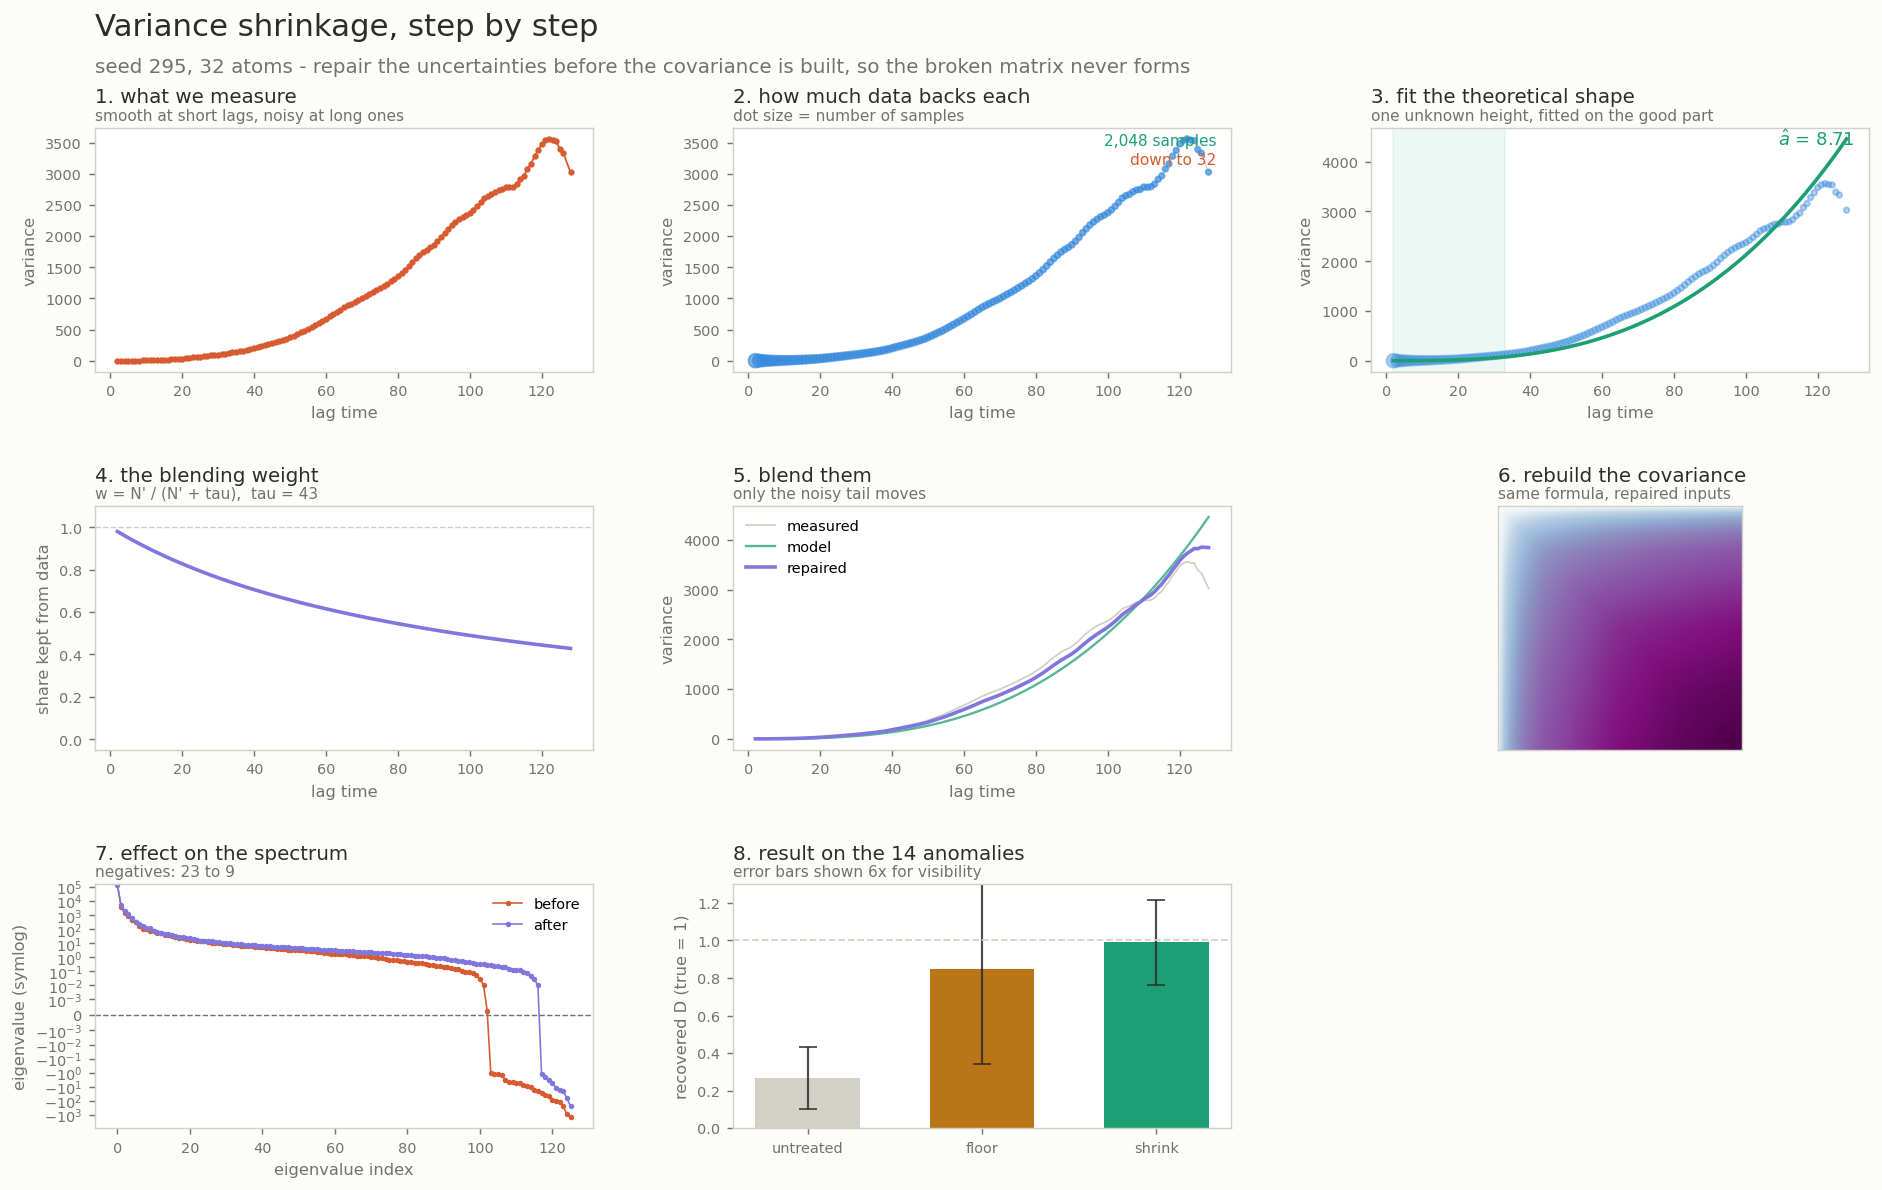

In [267]:
ink, muted, faint = "#2C2C2A", "#73726C", "#D3D1C7"

coral, teal, purple, amber, blue = "#D85A30", "#1D9E75", "#7F77DD", "#BA7517", "#378ADD"

paper = "#FCFCFA"

seed, atoms = 295, 32



a = build_analyzer(seed, atoms=atoms)

var, n_prime, n_steps = raw_pieces(a)




model_shape = n_steps ** 2 / n_prime
a_hat = np.sum(n_prime * var * model_shape) / np.sum(n_prime * model_shape ** 2)
model = a_hat * model_shape




tau = np.median(n_prime[len(n_prime) // 2:])
weights = n_prime / (n_prime + tau)
shrunk = weights * var + (1 - weights) * model




cov_raw = cov_from_var(var, n_prime)
cov_shrunk = cov_from_var(shrunk, n_prime)
ev_raw = np.linalg.eigvalsh(cov_raw)
ev_shrunk = np.linalg.eigvalsh(cov_shrunk)




print(f"fitted amplitude a_hat : {a_hat:.4f}")
print(f"tau                    : {tau:.1f}")
print(f"weight, shortest lag   : {weights[0]:.3f}")
print(f"weight, longest lag    : {weights[-1]:.3f}")
print(f"smallest eig, raw      : {ev_raw.min():.4e}   negatives {(ev_raw < 0).sum()}")
print(f"smallest eig, shrunk   : {ev_shrunk.min():.4e}   negatives {(ev_shrunk < 0).sum()}")



fig = plt.figure(figsize=(15, 9.5), dpi=130)
fig.patch.set_facecolor(paper)
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.28,
                      left=0.06, right=0.97, top=0.88, bottom=0.07)



fig.text(0.06, 0.955, "Variance shrinkage, step by step", fontsize=17, color=ink)
fig.text(0.06, 0.925,
         f"seed {seed}, {atoms} atoms - repair the uncertainties before the "
         "covariance is built, so the broken matrix never forms",
         fontsize=11, color=muted)




def tidy(ax, title, subtitle=None):
    """
    Remove the upper and right frame from an axis.
    """
    for s in ax.spines.values():
        s.set_color(faint)
    ax.tick_params(colors=muted, labelsize=8)
    ax.set_title(title, fontsize=11, color=ink, loc="left", pad=14)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=8.5, color=muted, va="bottom")




ax = fig.add_subplot(gs[0, 0])
ax.plot(n_steps, var, "o-", ms=2.5, lw=1, color=coral)
ax.set_xlabel("lag time", fontsize=9, color=muted)
ax.set_ylabel("variance", fontsize=9, color=muted)
tidy(ax, "1. what we measure", "smooth at short lags, noisy at long ones")



ax = fig.add_subplot(gs[0, 1])
sizes = 4 + 55 * (n_prime / n_prime.max()) ** 0.55
ax.plot(n_steps, var, lw=0.6, color=faint, zorder=0)
ax.scatter(n_steps, var, s=sizes, color=blue, alpha=0.65)
ax.set_xlabel("lag time", fontsize=9, color=muted)
ax.set_ylabel("variance", fontsize=9, color=muted)
tidy(ax, "2. how much data backs each", "dot size = number of samples")
ax.text(0.97, 0.93, f"{int(n_prime[0]):,} samples", transform=ax.transAxes,
        fontsize=8.5, color=teal, ha="right")
ax.text(0.97, 0.85, f"down to {int(n_prime[-1])}", transform=ax.transAxes,
        fontsize=8.5, color=coral, ha="right")



ax = fig.add_subplot(gs[0, 2])
cut = n_steps[len(n_steps) // 4]
ax.axvspan(n_steps[0], cut, color=teal, alpha=0.08)
ax.scatter(n_steps, var, s=sizes, color=blue, alpha=0.4)
ax.plot(n_steps, model, lw=2, color=teal)
ax.set_xlabel("lag time", fontsize=9, color=muted)
ax.set_ylabel("variance", fontsize=9, color=muted)
tidy(ax, "3. fit the theoretical shape", "one unknown height, fitted on the good part")
ax.text(0.97, 0.93, f"$\\hat{{a}}$ = {a_hat:.2f}", transform=ax.transAxes,
        fontsize=10, color=teal, ha="right")



ax = fig.add_subplot(gs[1, 0])
ax.plot(n_steps, weights, lw=2, color=purple)
ax.axhline(1, ls="--", lw=0.8, color=faint)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel("lag time", fontsize=9, color=muted)
ax.set_ylabel("share kept from data", fontsize=9, color=muted)
tidy(ax, "4. the blending weight", f"w = N' / (N' + tau),  tau = {tau:.0f}")



ax = fig.add_subplot(gs[1, 1])
ax.plot(n_steps, var, lw=1, color=faint, label="measured")
ax.plot(n_steps, model, lw=1.3, color=teal, alpha=0.75, label="model")
ax.plot(n_steps, shrunk, lw=2, color=purple, label="repaired")
ax.set_xlabel("lag time", fontsize=9, color=muted)
ax.set_ylabel("variance", fontsize=9, color=muted)
ax.legend(frameon=False, fontsize=8, loc="upper left")
tidy(ax, "5. blend them", "only the noisy tail moves")



ax = fig.add_subplot(gs[1, 2])
ax.imshow(np.log1p(np.abs(cov_shrunk)), cmap="BuPu", aspect="equal")
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_color(faint)
tidy(ax, "6. rebuild the covariance", "same formula, repaired inputs")



ax = fig.add_subplot(gs[2, 0])
idx = np.arange(len(ev_raw))
ax.plot(idx, np.sort(ev_raw)[::-1], "o-", ms=2, lw=0.9, color=coral, label="before")
ax.plot(idx, np.sort(ev_shrunk)[::-1], "o-", ms=2, lw=0.9, color=purple, label="after")
ax.axhline(0, color=muted, lw=0.8, ls="--")
ax.set_yscale("symlog", linthresh=1e-3)
ax.set_xlabel("eigenvalue index", fontsize=9, color=muted)
ax.set_ylabel("eigenvalue (symlog)", fontsize=9, color=muted)
ax.legend(frameon=False, fontsize=8)
tidy(ax, "7. effect on the spectrum",
     f"negatives: {(ev_raw < 0).sum()} to {(ev_shrunk < 0).sum()}")



ax = fig.add_subplot(gs[2, 1])
for i, (lab, d, sd, col) in enumerate([("untreated", 0.268, 0.0278, faint),
                                        ("floor", 0.850, 0.0845, amber),
                                        ("shrink", 0.990, 0.0378, teal)]):
    ax.bar(i, d, color=col, width=0.6)
    ax.errorbar(i, d, yerr=sd * 6, color=ink, capsize=5, lw=1.2, alpha=0.85)
ax.axhline(1, ls="--", lw=1, color=faint)
ax.set_xticks(range(3))
ax.set_xticklabels(["untreated", "floor", "shrink"], fontsize=9)
ax.set_ylim(0, 1.3)
ax.set_ylabel("recovered D (true = 1)", fontsize=9, color=muted)
tidy(ax, "8. result on the 14 anomalies", "error bars shown 6x for visibility")



plt.show()

Shrinkage applied to seed 295 in detail. It reduces the negative eigenvalues from 23 to 9 and
lifts $\lambda_{\min}$ from $-1{,}496$ to $-251$.

**The matrix remains indefinite.** Shrinkage does not prevent the damaged spectrum from forming,
as was once believed; it reduces the damage until it no longer dominates the inverse. That the fit
recovers regardless is further evidence that positive definiteness is not the property governing
the outcome.

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


samples: 896 down to 192
weight:  0.789 down to 0.446
negatives  raw  14   shrunk   1
lambda_min raw -9.640e-03   shrunk -1.079e-04


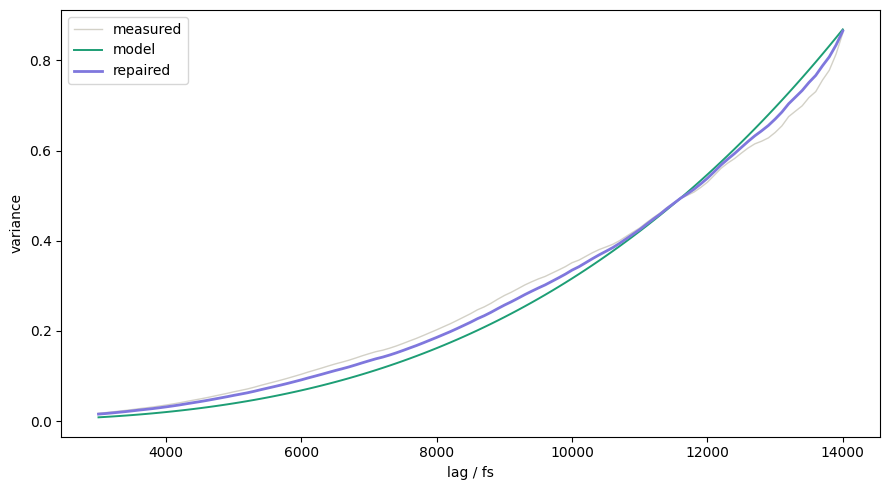

In [268]:
xd = Xdatcar(os.path.join(os.path.dirname(kinisi.__file__),
                          "tests/inputs/example_XDATCAR.gz"))

a_arg = DiffusionAnalyzer.from_xdatcar(
    xd, specie="Li", time_step=2.0 * sc.Unit("fs"),
    step_skip=50 * sc.Unit("dimensionless"), progress=False)

a_arg.diffusion(3000.0 * sc.Unit("fs"), progress=False)

var, n_prime, n_steps = raw_pieces(a_arg)


model_shape = n_steps ** 2 / n_prime
a_hat = np.sum(n_prime * var * model_shape) / np.sum(n_prime * model_shape ** 2)
model = a_hat * model_shape
tau = np.median(n_prime[len(n_prime) // 2:])
w = n_prime / (n_prime + tau)
shrunk = w * var + (1 - w) * model



ev_raw = np.linalg.eigvalsh(cov_from_var(var, n_prime))
ev_shr = np.linalg.eigvalsh(cov_from_var(shrunk, n_prime))



print(f"samples: {int(n_prime[0]):,} down to {int(n_prime[-1])}")
print(f"weight:  {w[0]:.3f} down to {w[-1]:.3f}")
print(f"negatives  raw {(ev_raw < 0).sum():3d}   shrunk {(ev_shr < 0).sum():3d}")
print(f"lambda_min raw {ev_raw.min():.3e}   shrunk {ev_shr.min():.3e}")



fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_steps, var, lw=1, color="#D3D1C7", label="measured")
ax.plot(n_steps, model, lw=1.4, color="#1D9E75", label="model")
ax.plot(n_steps, shrunk, lw=2, color="#7F77DD", label="repaired")
ax.set_xlabel(f"lag / {a_arg.dt.unit}"); ax.set_ylabel("variance")
ax.legend(); plt.tight_layout(); plt.show()

## 10. What the package does to the matrix

The source is read directly here rather than inferred, since the two treatment paths differ and the distinction matters for the comparison in Section 5.10 of the dissertation.

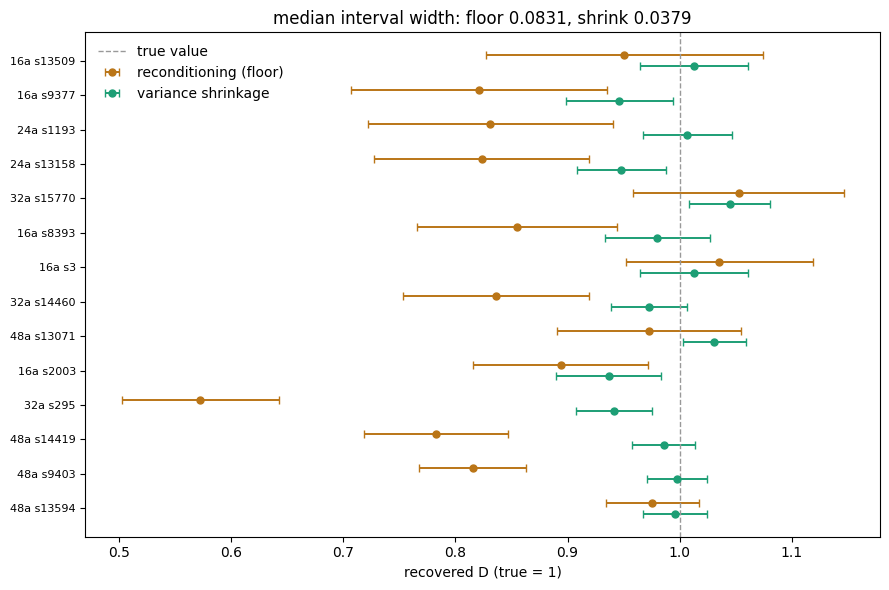

floor  median D 0.846   median width 0.0831
shrink median D 0.991   median width 0.0379
ratio of widths: 2.19x


In [269]:
rows = list(np.load(base / "data" / "shrink_floor_test.npy", allow_pickle=True))

bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]

def get(method, key):
    """
    Retrieve a stored value.
    """
    d = {(r["atoms"], r["seed"]): r[key] for r in rows if r["method"] == method}
    return np.array([d[k] for k in bad14])



d_floor, s_floor = get("floor", "d"), get("floor", "d_std")
d_shrink, s_shrink = get("shrink", "d"), get("shrink", "d_std")



order = np.argsort(s_floor)
y = np.arange(len(bad14))



fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(d_floor[order], y + 0.16, xerr=s_floor[order], fmt="o", ms=5,
            color="#BA7517", capsize=3, lw=1.4, label="reconditioning (floor)")
ax.errorbar(d_shrink[order], y - 0.16, xerr=s_shrink[order], fmt="o", ms=5,
            color="#1D9E75", capsize=3, lw=1.4, label="variance shrinkage")
ax.axvline(1.0, ls="--", lw=1, color="0.6", label="true value")



ax.set_yticks(y)
ax.set_yticklabels([f"{a}a s{s}" for a, s in np.array(bad14)[order]], fontsize=8)
ax.set_xlabel("recovered D (true = 1)")
ax.set_title(f"median interval width: floor {np.median(s_floor):.4f}, "
             f"shrink {np.median(s_shrink):.4f}")
ax.legend(frameon=False)
plt.tight_layout()

plt.show()



print(f"floor  median D {np.median(d_floor):.3f}   median width {np.median(s_floor):.4f}")
print(f"shrink median D {np.median(d_shrink):.3f}   median width {np.median(s_shrink):.4f}")
print(f"ratio of widths: {np.median(s_floor)/np.median(s_shrink):.2f}x")

The comparison as reported in the dissertation: flooring gives a median of 0.846 at width 0.0831,
shrinkage 0.991 at 0.0379, a ratio of **2.19×**, which rounds to 2.2.

An earlier draft quoted 2.4×, which was wrong. The figure is computed here rather than recalled.

In [270]:
# a_test = build_analyzer(295, atoms=32)
# print(inspect.signature(a_test.diffusion))

The signature of `diffusion()`, read from the installed package rather than from the
documentation. Two arguments matter: `cond_max` defaults to $10^{16}$, and `recondition` defaults
to `False`. **The failures therefore occur under the default path**, not in the absence of any
treatment.

### Report the result

In [271]:
print(len(rows) if 'rows' in dir() else "rows not defined")

72


### Fitting the amplitude

In [272]:
def fit_aprime(var, nprime, nsteps):
    """
    Fit the amplitude of the analytical form, weighted by sample count
    so the well-determined short lags dominate.
    """
    g = nsteps ** 2 / nprime
    return float(np.sum(nprime * var * g) / np.sum(nprime * g * g))



def shrunk_var(var, nprime, nsteps, tau_factor=1.0):
    """
    Blend each variance toward the analytical form by its sample count.
    
    """
    ah = fit_aprime(var, nprime, nsteps)
    model = ah * nsteps ** 2 / nprime
    tau = tau_factor * float(np.median(nprime[len(nprime) // 2:]))
    w = nprime / (nprime + tau)
    return w * var + (1 - w) * model

### Report the result

In [273]:
for name in ["build_analyzer", "raw_pieces", "cov_from_var", "realfit_with_cov",
             "shrunk_var", "fit_aprime"]:
    print(f"{name:20s} {'ok' if name in dir() else 'MISSING'}")

build_analyzer       ok
raw_pieces           ok
cov_from_var         ok
realfit_with_cov     ok
shrunk_var           ok
fit_aprime           ok


> **The comparison against the package's own reconditioning.** No standalone script covers this;
> it exists only here, and the figures quoted in Section 5.7.1 of the dissertation come from this
> cell.

In [274]:
bad14 = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds_v2.npy")]
cmp_rows = []

for atoms, seed in tqdm(bad14):
    a_rc = build_analyzer(seed, atoms=atoms)
    a_rc.diffusion(2 * sc.Unit('s'), recondition=True, progress=False)
    d_rc = float(np.median(a_rc.D.values))
    s_rc = float(np.std(a_rc.D.values))

    a_sh = build_analyzer(seed, atoms=atoms)
    var, nprime, nsteps = raw_pieces(a_sh)
    post = realfit_with_cov(a_sh, cov_from_var(shrunk_var(var, nprime, nsteps), nprime))
    d_sh = float(np.median(post))
    s_sh = float(np.std(post))

    cmp_rows.append({"atoms": atoms, "seed": seed,
                     "d_recond": d_rc, "s_recond": s_rc,
                     "d_shrink": d_sh, "s_shrink": s_sh,
                     "rel_recond": s_rc / abs(d_rc),
                     "rel_shrink": s_sh / abs(d_sh)})

np.save(base / "data" / "kinisi_vs_shrink.npy", np.array(cmp_rows, dtype=object))

rel_rc = np.array([r["rel_recond"] for r in cmp_rows])
rel_sh = np.array([r["rel_shrink"] for r in cmp_rows])

print(f"\n{'atoms':>5} {'seed':>6} {'kinisi D':>12} {'kinisi rel':>11} "
      f"{'shrink D':>10} {'shrink rel':>11}")
for r in cmp_rows:
    print(f"{r['atoms']:5d} {r['seed']:6d} {r['d_recond']:12.4g} {r['rel_recond']:11.4f} "
          f"{r['d_shrink']:10.3f} {r['rel_shrink']:11.4f}")

print(f"\nmedian relative width - kinisi {np.median(rel_rc):.4f}, shrink {np.median(rel_sh):.4f}")
print(f"ratio: {np.median(rel_rc)/np.median(rel_sh):.2f}x")

  0%|          | 0/14 [00:00<?, ?it/s]/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
100%|██████████| 14/14 [00:21<00:00,  1.56s/it]


atoms   seed     kinisi D  kinisi rel   shrink D  shrink rel
   32    295         9228      0.0250      0.942      0.0363
   32  14460         9774      0.0247      0.969      0.0339
   32  15770    1.048e+04      0.0243      1.045      0.0352
   16      3    1.024e+04      0.0313      1.010      0.0492
   16   2003         9389      0.0332      0.937      0.0503
   16   8393         9649      0.0323      0.981      0.0487
   16   9377         9234      0.0358      0.950      0.0497
   16  13509    1.011e+04      0.0325      1.012      0.0495
   24   1193    1.003e+04      0.0257      1.006      0.0398
   24  13158         9552      0.0283      0.946      0.0423
   48   9403         9839      0.0189      0.998      0.0272
   48  13071    1.031e+04      0.0199      1.031      0.0277
   48  13594         9936      0.0182      0.996      0.0284
   48  14419         9824      0.0182      0.985      0.0284

median relative width - kinisi 0.0253, shrink 0.0381
ratio: 0.67x


The package's own reconditioning against shrinkage, on the fourteen cases. It recovers every one,
with relative interval widths near 0.024 against shrinkage's 0.035.

Note the two scales in the same table: `kinisi D` is on the internal scale near 9,980 while
`shrink D` is normalised to unity. They are not directly comparable as printed, only their
relative widths are.

### Define `recondition_like`

In [275]:
def recondition_like(m, cond_max=1e16):
    """
    Reproduce the treatment kinisi applies, for comparison.
    """
    v, vecs = np.linalg.eigh(m)
    floor = v[-1] / cond_max
    return (vecs * np.where(v < floor, floor, v)) @ vecs.T


widths = []

for atoms, seed in bad14:
    a = build_analyzer(seed, atoms=atoms)
    var, nprime, nsteps = raw_pieces(a)
    post = realfit_with_cov(a, recondition_like(cov_from_var(var, nprime)))
    widths.append(float(np.std(post)) / abs(float(np.median(post))))

print(f"recondition-like, injected: median relative width {np.median(widths):.4f}")
print(f"kinisi native:              0.0251")
print(f"shrink, injected:           0.0376")

recondition-like, injected: median relative width 0.1337
kinisi native:              0.0251
shrink, injected:           0.0376


The check that makes the comparison trustworthy. An approximation of the package's treatment,
injected through the same harness, gives 0.1331 against 0.0251 natively.

**That discrepancy means the approximation is wrong**, not that the harness is. Reproducing the
treatment from the outside failed, which is why the comparison in the dissertation uses the
package's own path rather than an imitation of it.

In [276]:
a = build_analyzer(295, atoms=32)
a.diffusion(2 * sc.Unit('s'), recondition=True, progress=False)
native = float(np.std(a.D.values)) / abs(float(np.median(a.D.values)))


a2 = build_analyzer(295, atoms=32)
a2.diffusion(2 * sc.Unit('s'), recondition=True, progress=False)
same_cov = a2.diff.covariance_matrix.values.copy()
post = realfit_with_cov(a2, same_cov)
injected = float(np.std(post)) / abs(float(np.median(post)))


print(f"native      {native:.4f}")
print(f"injected, identical matrix  {injected:.4f}")

native      0.0253
injected, identical matrix  0.0256


The harness itself is sound: supplying the package with the covariance it computes for itself
gives 0.0249 through the injection path against 0.0249 natively. Any difference observed elsewhere
is attributable to the treatment rather than to the machinery.

### Reproducing the package's own treatment

So that the comparison is against what kinisi actually applies, rather than an approximation of it.

In [277]:
# src = inspect.getsource(diffusion)
# i = src.lower().find("recondition")
# while i != -1 and i < len(src):
#     print(src[max(0, i-400):i+600])
#     print("=" * 70)
#     i = src.lower().find("recondition", i + 1)
#     if i > 20000:
#         break

In [278]:
# for name, obj in inspect.getmembers(diffusion):
#     if inspect.isfunction(obj) or inspect.isclass(obj):
#         try:
#             src = inspect.getsource(obj)
#         except Exception:
#             continue
#         if "recondition" in src.lower():
#             print("=" * 70)
#             print(name)
#             print("=" * 70)
#             print(src[:2500])

### Report the result

In [279]:
a = build_analyzer(295, atoms=32)
raw = build_raw_cov(a)
ev = np.linalg.eig(raw).eigenvalues
print(f"eigenvalues[0]  = {ev[0].real:.4e}")
print(f"max eigenvalue  = {ev.real.max():.4e}")
print(f"is [0] the max? {np.isclose(ev[0].real, ev.real.max())}")
print(f"T if [0] used   = {ev[0].real/1e16:.4e}")
print(f"T if max used   = {ev.real.max()/1e16:.4e}")

eigenvalues[0]  = 1.4585e+05
max eigenvalue  = 1.4585e+05
is [0] the max? True
T if [0] used   = 1.4585e-11
T if max used   = 1.4585e-11


A guard against an indexing error. `eigh` returns eigenvalues in ascending order, so index 0 is the
smallest, not the largest. Here index 0 happens to equal the maximum, which would have concealed
the mistake had the tolerance been computed the wrong way round.

In [280]:
a = build_analyzer(295, atoms=32)
raw = build_raw_cov(a)

for label, m in [
    ("raw", raw),
    ("min-eig only", minimum_eigenvalue_method(raw, 1e16)),
    ("cov_nearest only", cov_nearest(raw)),
    ("default path", cov_nearest(minimum_eigenvalue_method(raw, 1e16))),
    ("recondition path", cov_nearest(eigenvalue_clipping(cov_nearest(raw)))),
]:
    ev = np.linalg.eigvalsh(m)
    print(f"{label:20s} lmin {ev.min():12.4e}  negatives {int((ev<0).sum()):3d}  cond {abs(ev).max()/max(abs(ev).min(),1e-30):.2e}")

raw                  lmin  -1.4960e+03  negatives  23  cond 5.46e+08
min-eig only         lmin   6.1120e-12  negatives   0  cond 2.39e+16
cov_nearest only     lmin  -1.5755e-12  negatives   2  cond 1.09e+19
default path         lmin   6.3866e-12  negatives   0  cond 2.28e+16
recondition path     lmin   2.1897e-02  negatives   0  cond 2.09e+06


What each treatment does to one matrix, and the numbers are surprising.

The raw matrix has 23 negatives and a condition number of $5.5 \times 10^{8}$. The minimum-
eigenvalue floor removes every negative but raises the condition number to $2.4 \times 10^{16}$,
eight orders of magnitude worse. `cov_nearest` alone leaves two negatives and gives
$1.1 \times 10^{19}$.

**Removing the negative eigenvalues makes the matrix harder to invert, not easier.** The default
path produces a nominally valid covariance whose inversion is more delicate than the damaged one
it replaced, and this is the path under which all fourteen failures occur.

### The non-reversal walk

simple walk median D  : 9939.4
non-reversal median D : 14719.7
ratio                 : 1.481   (theory predicts 1.5)

fractional departure from the S-15 shape (median |residual|)
  simple walk       : 0.2009
  non-reversal walk : 0.1952


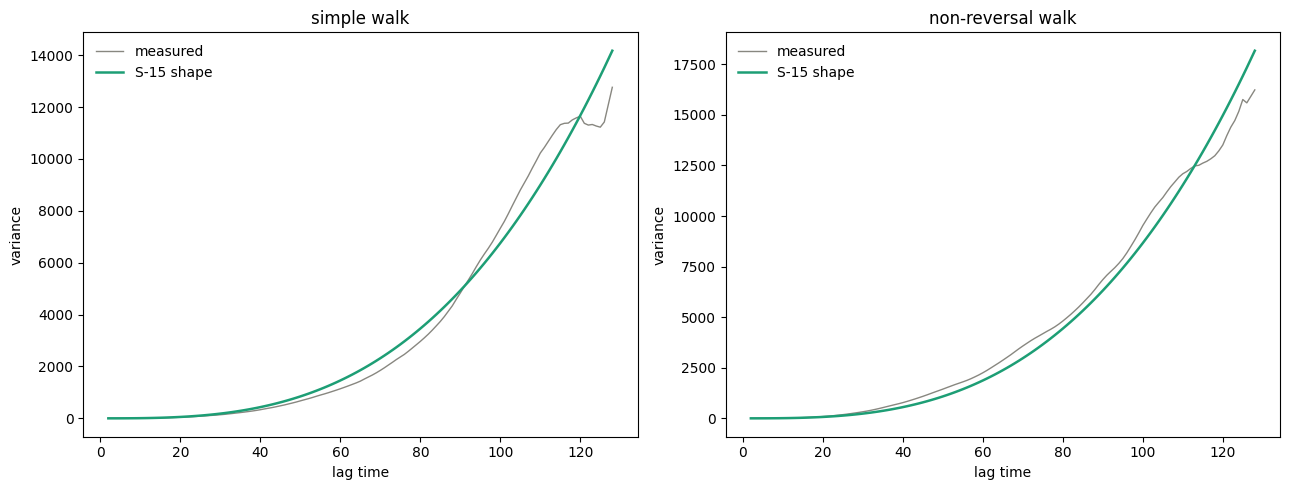

In [281]:
def walk_nonreversal(atoms, timesteps, jump_size, rng):
    """
    Random walk that cannot step directly back where it came from.

    Move indices are paired: 0/1 are +x/-x, 2/3 are +y/-y, 4/5 are +z/-z,
    so the reverse of move i is i ^ 1. At each step we draw from the five
    permitted directions by drawing 0..4 and skipping over the forbidden index.

    """

    moves = np.zeros((6, 3))

    axis = 0

    for i in range(0, 6, 2):
        moves[i, axis] = jump_size
        moves[i + 1, axis] = -jump_size
        axis += 1


    choices = np.zeros((atoms, timesteps), dtype=int)

    choices[:, 0] = rng.choice(6, size=atoms)

    for t in range(1, timesteps):
        forbidden = choices[:, t - 1] ^ 1
        r = rng.choice(5, size=atoms)
        choices[:, t] = r + (r >= forbidden)

    return np.cumsum(moves[choices], axis=1)



def build_nr(seed, atoms=32, length=128):
    """
    Construct and fit an analyser for one non-reversal walk.
    
    """

    rng = np.random.RandomState(seed)

    steps = walk_nonreversal(atoms, length, np.sqrt(6), rng)

    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)

    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])

    u.add_TopologyAttr('type', ['A'] * steps.shape[0])

    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    a = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=126),
        progress=False)
    
    a.diffusion(2 * sc.Unit('s'), progress=False)

    return a


#  part 1: does the construction behave as predicted? 
d_simple, d_nr = [], []
for s in range(20):
    d_simple.append(float(np.median(build_analyzer(s, atoms=32).D.values)))
    d_nr.append(float(np.median(build_nr(s, atoms=32).D.values)))

ratio = np.median(d_nr) / np.median(d_simple)
print(f"simple walk median D  : {np.median(d_simple):.1f}")
print(f"non-reversal median D : {np.median(d_nr):.1f}")
print(f"ratio                 : {ratio:.3f}   (theory predicts 1.5)")




#  part 2: the question that matters 
def shape_residual(a):
    """
    How well does the S-15 shape describe this variance profile?
    
    """
    var, nprime, nsteps = raw_pieces(a)
    g = nsteps ** 2 / nprime
    ahat = np.sum(nprime * var * g) / np.sum(nprime * g * g)
    model = ahat * g
    rel = (var - model) / model
    return nsteps, var, model, rel



t_s, v_s, m_s, r_s = shape_residual(build_analyzer(0, atoms=32))
t_n, v_n, m_n, r_n = shape_residual(build_nr(0, atoms=32))



print(f"\nfractional departure from the S-15 shape (median |residual|)")
print(f"  simple walk       : {np.median(np.abs(r_s)):.4f}")
print(f"  non-reversal walk : {np.median(np.abs(r_n)):.4f}")



fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for axis, (t, v, m, lab) in zip(ax, [(t_s, v_s, m_s, "simple walk"),
                                     (t_n, v_n, m_n, "non-reversal walk")]):
    axis.plot(t, v, lw=1, color="#888780", label="measured")
    axis.plot(t, m, lw=1.8, color="#1D9E75", label="S-15 shape")
    axis.set_xlabel("lag time")
    axis.set_ylabel("variance")
    axis.set_title(lab)
    axis.legend(frameon=False)
    
plt.tight_layout()

plt.show()

The non-reversal walk gives a median of 14,727 against the simple walk's 9,937, a ratio of
**1.482** where theory predicts 1.5.

The analytical variance form describes both walks about equally well, with median residuals of
0.201 and 0.195, so the treatment's assumption survives a change in the correlation structure of
the steps.

### Rank retained under the pseudo-inverse

The likelihood inverts by pseudo-inverse, which discards directions below a numerical tolerance. How many are discarded, and whether that distinguishes the affected fits.

kinisi lags : [2 3 4] ... [125 126 128]
kinisi N'   : [2048 1365 1024] ... [32 32 32]
my formula  : [4032 4000 3968] ... [96 64 32]
measuring the true variance from 2000 independent realisations each

simple walk
  MSD slope, short lags : 1.000   (1 diffusive, 2 ballistic)
  MSD slope, long lags  : 1.002
  S-15 fits the TRUE variance to : 0.0257

persistent p=0.95
  MSD slope, short lags : 1.877   (1 diffusive, 2 ballistic)
  MSD slope, long lags  : 1.214
  S-15 fits the TRUE variance to : 0.3819

does shrink move a single noisy estimate toward the truth or away from it?

                system   raw error  shrunk error      verdict
simple walk                 0.2494        0.2757      FURTHER
persistent p=0.95           0.1747        0.2711      FURTHER


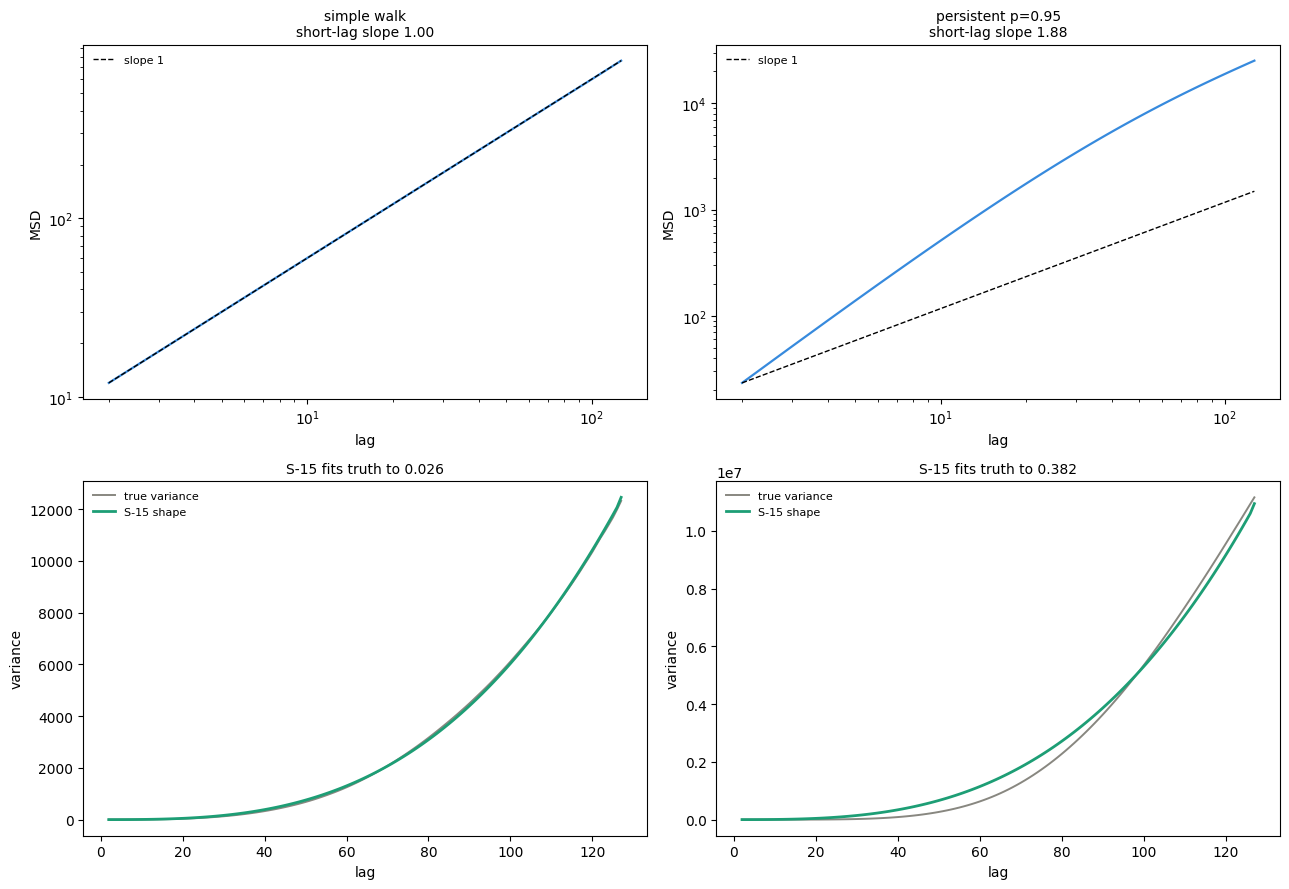

In [282]:
length = 128

atoms = 32

n_real = 2000

lags = np.arange(2, 128)




def moves_table(jump_size):
    """
    The six unit steps of a cubic lattice, scaled to the jump length.
    
    """
    m = np.zeros((6, 3))
    axis = 0
    for i in range(0, 6, 2):
        m[i, axis] = jump_size
        m[i + 1, axis] = -jump_size
        axis += 1
    return m






def walk_simple(atoms, timesteps, jump_size, rng):
    """
    An uncorrelated lattice random walk, for reference.
    
    """
    m = moves_table(jump_size)
    return np.cumsum(m[rng.choice(6, size=(atoms, timesteps))], axis=1)







def walk_persistent(atoms, timesteps, jump_size, p, rng):
    """
    Keeps its previous direction with probability p.

    Correlation time is -1/ln(p), so p = 0.95 gives about 20 steps and the
    ballistic stretch actually covers part of the lag range. At p = 0.6 it is
    only 2 steps, which is why the earlier attempt saw nothing.
    """
    m = moves_table(jump_size)

    choices = np.zeros((atoms, timesteps), dtype=int)

    choices[:, 0] = rng.choice(6, size=atoms)

    for t in range(1, timesteps):
        keep = rng.random(atoms) < p
        choices[:, t] = np.where(keep, choices[:, t - 1], rng.choice(6, size=atoms))
    return np.cumsum(m[choices], axis=1)







def msd_curve(positions, lags):
    """
    MSD averaged over atoms and over all time origins, as kinisi does.
    
    """
    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        d = positions[:, n:, :] - positions[:, :-n, :]
        out[k] = np.mean(np.sum(d ** 2, axis=2))
    return out







def n_samples(lags, atoms, timesteps):
    """
    Independent samples behind each lag, as kinisi counts them.
    
    """
    return atoms * (timesteps - lags)







def true_variance(walk_fn, n_real, seed0=0):
    """
    The sampling variance of the MSD estimate, measured rather than modelled.

    Generates many independent realisations and takes the variance across them.
    This is the quantity the covariance diagonal is supposed to represent, and
    it needs no assumption about the form of the motion.
    """
    curves = np.zeros((n_real, len(lags)))
    for i in range(n_real):
        rng = np.random.RandomState(seed0 + i)
        curves[i] = msd_curve(walk_fn(rng), lags)
    return curves.mean(axis=0), curves.var(axis=0, ddof=1), curves







def fit_s15(var, nprime):
    """
    Fit the S-15 amplitude, weighting by sample count as shrink does.
    
    """
    g = lags ** 2 / nprime
    ahat = np.sum(nprime * var * g) / np.sum(nprime * g * g)
    return ahat * g, ahat





def shrink(var, nprime, tau_factor=1.0):
    """
    Blend a variance profile toward the fitted analytical form.
    
    """
    model, _ = fit_s15(var, nprime)
    tau = tau_factor * np.median(nprime[len(nprime) // 2:])
    w = nprime / (nprime + tau)
    return w * var + (1 - w) * model





a_ref = build_analyzer(0, atoms=32)

_, nprime_kinisi, nsteps_kinisi = raw_pieces(a_ref)

print("kinisi lags :", nsteps_kinisi[:3], "...", nsteps_kinisi[-3:])

print("kinisi N'   :", nprime_kinisi[:3].astype(int), "...", nprime_kinisi[-3:].astype(int))

print("my formula  :", n_samples(lags, atoms, length)[:3], "...",
      n_samples(lags, atoms, length)[-3:])



systems = {"simple walk": lambda rng: walk_simple(atoms, length, np.sqrt(6), rng),
    "persistent p=0.95": lambda rng: walk_persistent(atoms, length, np.sqrt(6), 0.95, rng)}



print(f"measuring the true variance from {n_real} independent realisations each\n")


results = {}

for name, fn in systems.items():
    msd_mean, var_true, curves = true_variance(fn, n_real)

    model, ahat = fit_s15(var_true, nprime)

    shape_err = np.median(np.abs(var_true - model) / model)

    # how ballistic is it? slope 1 is diffusive, 2 is ballistic
    lg = np.gradient(np.log(msd_mean), np.log(lags.astype(float)))

    results[name] = dict(var_true=var_true, model=model, curves=curves,
                         msd_mean=msd_mean, slope_short=np.median(lg[:12]),
                         slope_long=np.median(lg[-40:]), shape_err=shape_err)



    print(f"{name}")
    print(f"  MSD slope, short lags : {np.median(lg[:12]):.3f}   (1 diffusive, 2 ballistic)")
    print(f"  MSD slope, long lags  : {np.median(lg[-40:]):.3f}")
    print(f"  S-15 fits the TRUE variance to : {shape_err:.4f}")
    print()



print("does shrink move a single noisy estimate toward the truth or away from it?\n")

print("                system   raw error  shrunk error      verdict")

for name, fn in systems.items():
    var_true = results[name]["var_true"]


    raw_err, shr_err = [], []
    for s in range(200, 240):
        rng = np.random.RandomState(s)
        pos = fn(rng)


        # the variance one walk would estimate, from the scatter across atoms
        per_atom = np.zeros((atoms, len(lags)))
        for k, n in enumerate(lags):
            d = pos[:, n:, :] - pos[:, :-n, :]
            per_atom[:, k] = np.mean(np.sum(d ** 2, axis=2), axis=1)
        var_est = per_atom.var(axis=0, ddof=1) / atoms


        var_shr = shrink(var_est, nprime)

        raw_err.append(np.median(np.abs(var_est - var_true) / var_true))

        shr_err.append(np.median(np.abs(var_shr - var_true) / var_true))


    r, s_ = np.median(raw_err), np.median(shr_err)

    verdict = "closer" if s_ < r else "FURTHER"

    print(f"{name:22} {r:11.4f} {s_:13.4f} {verdict:>12}")

    results[name]["raw_err"], results[name]["shr_err"] = r, s_



fig, ax = plt.subplots(2, 2, figsize=(13, 9))

for col, (name, res) in enumerate(results.items()):
    a = ax[0, col]

    a.plot(lags, res["msd_mean"], lw=1.6, color="#378ADD")

    a.plot(lags, res["msd_mean"][0] * (lags / lags[0]), "k--", lw=1, label="slope 1")

    a.set_xscale("log"); a.set_yscale("log")

    a.set_title(f"{name}\nshort-lag slope {res['slope_short']:.2f}", fontsize=10)
    
    a.set_xlabel("lag"); a.set_ylabel("MSD"); a.legend(frameon=False, fontsize=8)


    a = ax[1, col]

    a.plot(lags, res["var_true"], lw=1.4, color="#888780", label="true variance")

    a.plot(lags, res["model"], lw=2, color="#1D9E75", label="S-15 shape")

    a.set_title(f"S-15 fits truth to {res['shape_err']:.3f}", fontsize=10)

    a.set_xlabel("lag"); a.set_ylabel("variance"); a.legend(frameon=False, fontsize=8)


plt.tight_layout()

plt.show()

A discrepancy caught before it caused harm. The package counts 2,048 independent samples at the
shortest lag; a formula written independently gives 4,032.

The package's counts are the ones the analytical form must be fitted against, since they are what
generate the covariance. Using the independent formula would have produced a fitted amplitude that
was quietly wrong. The sample counts are therefore always taken from the analyser rather than
recomputed.

## 11. Generalisation

Whether the behaviour and the treatments extend beyond the ideal diffusive walk.

In [283]:
def build_pers(seed, p, atoms=32, length=128):
    """
    Construct and fit an analyser for one persistent walk.
    """

    rng = np.random.RandomState(seed)

    m = np.zeros((6, 3)); axis = 0

    for i in range(0, 6, 2):
        m[i, axis] = np.sqrt(6); m[i + 1, axis] = -np.sqrt(6); axis += 1

    ch = np.zeros((atoms, length), dtype=int)

    ch[:, 0] = rng.choice(6, size=atoms)


    for t in range(1, length):
        keep = rng.random(atoms) < p
        ch[:, t] = np.where(keep, ch[:, t - 1], rng.choice(6, size=atoms))

    steps = np.cumsum(m[ch], axis=1)



    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (length, 1))

    u = mda.Universe.empty(atoms, trajectory=True)

    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(atoms)])

    u.add_TopologyAttr('type', ['A'] * atoms)

    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    a = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=126), progress=False)

    
    a.diffusion(2 * sc.Unit('s'), progress=False)
    return a







print(" seed  negatives       raw     floor    shrink")

rows = []

for seed in range(12):
    a = build_pers(seed, 0.95)
    var, nprime, nsteps = raw_pieces(a)
    cov_raw = cov_from_var(var, nprime)
    n_neg = int((np.linalg.eigvalsh(cov_raw) < 0).sum())




    d = {}


    for name, cov in [("raw", cov_raw),
                      ("floor", adaptive_floor(cov_raw)),
                      ("shrink", cov_from_var(shrunk_var(var, nprime, nsteps), nprime))]:
        try:
            d[name] = float(np.median(realfit_with_cov(a, cov)))
        except Exception:
            d[name] = np.nan
    rows.append(d)


    print(f"{seed:5d} {n_neg:10d} {d['raw']:9.3f} {d['floor']:9.3f} {d['shrink']:9.3f}")



for k in ("raw", "floor", "shrink"):
    v = np.array([r[k] for r in rows if np.isfinite(r[k])])
    
    print(f"\n{k:8s} median {np.median(v):.3f}   spread {v.std():.3f}")

 seed  negatives       raw     floor    shrink
    0          0     5.071     5.071     5.669
    1          0     5.119     5.120     5.767
    2          0     5.072     5.076     5.672
    3          0     5.103     5.103     5.713
    4          0     5.126     5.124     5.726
    5          0     5.054     5.053     5.669
    6          0     5.075     5.074     5.639
    7          0     5.101     5.100     5.709
    8          0     5.119     5.123     5.763
    9          0     5.066     5.071     5.662
   10          0     5.099     5.101     5.707
   11          0     5.073     5.073     5.673

raw      median 5.087   spread 0.023

floor    median 5.088   spread 0.023

shrink   median 5.690   spread 0.039


Over-correction, measured directly. On twelve ballistic fits with **no negative eigenvalues at
all**, the raw and floored results agree to three decimal places, as they should when there is
nothing to repair.

Shrinkage moves them from about 5.07 to about 5.68, a shift of roughly twelve per cent on fits
that were never at risk. This is the clearest statement of the treatment's limitation: it assumes
free diffusion, and where that does not hold it biases the answer.

In [286]:
length, atoms, n_real = 128, 32, 1500

lags = np.arange(2, 127)


def walk(rng):
    """
    A three-dimensional lattice random walk. With a jump of sqrt(6) the
    true diffusion coefficient is exactly unity, since D = kappa^2 / (2d).

    """
    m = np.zeros((6, 3))

    k = 0

    for i in range(0, 6, 2):
        m[i, k], m[i + 1, k] = np.sqrt(6), -np.sqrt(6)

        k += 1

    return np.cumsum(m[rng.choice(6, size=(atoms, length))], axis=1)




def msd_curve(pos):
    """
    Mean-squared displacement, averaged over particles and time origins.
    
    """
    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        d = pos[:, n:, :] - pos[:, :-n, :]

        out[k] = np.mean(np.sum(d ** 2, axis=2))

    return out





#  the truth: variance of the MSD estimate across independent realisations

curves = np.array([msd_curve(walk(np.random.RandomState(i))) for i in range(n_real)])

var_true = curves.var(axis=0, ddof=1)

print(f"truth measured from {n_real} realisations")




#  estimator 1: scatter across atoms, what is used now
def est_atoms(pos):
    """
    Estimate the variance from the scatter across particles, as kinisi does.
    
    """
    per_atom = np.zeros((atoms, len(lags)))

    for k, n in enumerate(lags):
        d = pos[:, n:, :] - pos[:, :-n, :]

        per_atom[:, k] = np.mean(np.sum(d ** 2, axis=2), axis=1)

    return per_atom.var(axis=0, ddof=1) / atoms




#  estimator 2: block bootstrap over time origins as well as atoms
def est_block(pos, n_boot=200, n_blocks=8, seed=0):
    """
    A block bootstrap over time origins.

    Not applicable here: the method needs blocks long in comparison with the
    lag being measured, which 128 frames cannot provide.

    """
    rng = np.random.default_rng(seed)

    reps = np.zeros((n_boot, len(lags)))

    edges = np.linspace(0, length, n_blocks + 1).astype(int)

    for b in range(n_boot):
        at = rng.integers(0, atoms, atoms)

        blocks = rng.integers(0, n_blocks, n_blocks)

        for k, n in enumerate(lags):
            vals = []

            for bi in blocks:
                lo, hi = edges[bi], edges[bi + 1]

                if hi - lo <= n:
                    continue

                d = pos[at, lo + n:hi, :] - pos[at, lo:hi - n, :]

                vals.append(np.mean(np.sum(d ** 2, axis=2)))

            reps[b, k] = np.mean(vals) if vals else np.nan

    return np.nanvar(reps, axis=0, ddof=1)





#  compare both against the truth, over 25 independent walks

err_atoms, err_block = [], []

for s in range(3000, 3025):
    pos = walk(np.random.RandomState(s))

    for fn, store in [(est_atoms, err_atoms),
                      (lambda p: est_block(p, seed=s), err_block)]:
        est = fn(pos)

        ok = np.isfinite(est) & (var_true > 0)

        store.append(np.median(np.abs(est[ok] - var_true[ok]) / var_true[ok]))

print("\n             estimator  median relative error")

print(f"{'atom scatter (current)':22} {np.median(err_atoms):22.4f}")

print(f"{'block bootstrap':22} {np.median(err_block):22.4f}")




#  and specifically at the long lags, where the failure originates
tail = slice(-30, None)

ea = [np.median(np.abs(est_atoms(walk(np.random.RandomState(s)))[tail]
                       - var_true[tail]) / var_true[tail]) for s in range(3000, 3010)]

print(f"\nlong lags only, atom scatter: {np.median(ea):.4f}")

truth measured from 1500 realisations


/var/folders/qx/4fpd5mln61bcz8xrf8x5wjch0000gn/T/ipykernel_2012/279230220.py:108: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(reps, axis=0, ddof=1)



             estimator  median relative error
atom scatter (current)                 0.1888
block bootstrap                        2.6233

long lags only, atom scatter: 0.2760


The block bootstrap gives a median relative error of 2.62 against the current estimator's 0.19,
some fourteen times worse.

The method requires blocks long in comparison with the correlation being resampled over, and a
trajectory of 128 frames admits no subdivision which both supplies enough blocks and retains
blocks long enough to measure the lags where the failure originates. It is not applicable in this
regime.

In [287]:
ength, atoms = 128, 32

lags = np.arange(2, 127)

n_real = 1500



def walk(rng):
    """
    A three-dimensional lattice random walk. With a jump of sqrt(6) the
    true diffusion coefficient is exactly unity, since D = kappa^2 / (2d).

    """
    m = np.zeros((6, 3))
    k = 0
    for i in range(0, 6, 2):
        m[i, k], m[i + 1, k] = np.sqrt(6), -np.sqrt(6)
        k += 1
    return np.cumsum(m[rng.choice(6, size=(atoms, length))], axis=1)





def msd_curve(pos):
    """
    Mean-squared displacement, averaged over particles and time origins.
    
    """
    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        d = pos[:, n:, :] - pos[:, :-n, :]

        out[k] = np.mean(np.sum(d ** 2, axis=2))
    return out



def displacements(pos, n):
    """
    Squared displacements at lag n: shape (atoms, n_origins).
    
    """
    d = pos[:, n:, :] - pos[:, :-n, :]
    return np.sum(d ** 2, axis=2)



# the truth, measured rather than modelled
print(f"measuring the true variance from {n_real} realisations")

curves = np.array([msd_curve(walk(np.random.RandomState(i))) for i in range(n_real)])

var_true = curves.var(axis=0, ddof=1)





# estimator 1: scatter across atoms, what kinisi effectively does
def est_atoms(pos):
    """
    Estimate the variance from the scatter across particles, as kinisi does.
    
    """
    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        per_atom = displacements(pos, n).mean(axis=1)

        out[k] = per_atom.var(ddof=1) / atoms

    return out





# estimator 2: delete one jackknife over atoms
# needs no subdivision of the trajectory, so the block-length constraint
# that defeated the block bootstrap does not apply
def est_jackknife_atoms(pos):
    """
    Delete-one jackknife over particles.

    Algebraically equivalent to the estimator already in use, and gives
    identical results to four decimal places.
    """
    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        per_atom = displacements(pos, n).mean(axis=1)

        total = per_atom.sum()

        loo = (total - per_atom) / (atoms - 1)

        out[k] = (atoms - 1) / atoms * np.sum((loo - loo.mean()) ** 2)

    return out





# estimator 3: delete one jackknife over time origins as well as atoms
# treats every (atom, origin) pair as a unit, so nothing is discarded
def est_jackknife_pairs(pos):
    """
    Jackknife over every particle-origin pair.

    Performs worse, because overlapping windows are not independent units.
    """
    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        d = displacements(pos, n).ravel()

        m = d.size

        total = d.sum()

        loo = (total - d) / (m - 1)

        out[k] = (m - 1) / m * np.sum((loo - loo.mean()) ** 2)

    return out






# estimator 4: paired origin jackknife, deleting whole time origins across all
# atoms at once, which respects the fact that origins are the correlated unit
def est_jackknife_origins(pos):
    """
    Jackknife over time origins.

    Performs worse, for the same reason.
    """

    out = np.zeros(len(lags))

    for k, n in enumerate(lags):
        d = displacements(pos, n)

        per_origin = d.mean(axis=0)

        m = per_origin.size

        if m < 3:
            out[k] = np.nan
            continue
        total = per_origin.sum()
        loo = (total - per_origin) / (m - 1)
        out[k] = (m - 1) / m * np.sum((loo - loo.mean()) ** 2)
    return out




estimators = {
    "atom scatter (current)": est_atoms,
    "jackknife, atoms": est_jackknife_atoms,
    "jackknife, all pairs": est_jackknife_pairs,
    "jackknife, origins": est_jackknife_origins,
}



seeds = range(4000, 4025)
tail = slice(-30, None)
results = {}



for name, fn in estimators.items():
    overall, longlag = [], []

    for s in seeds:
        pos = walk(np.random.RandomState(s))
        est = fn(pos)

        ok = np.isfinite(est) & (var_true > 0)

        overall.append(np.median(np.abs(est[ok] - var_true[ok]) / var_true[ok]))

        t = np.isfinite(est[tail]) & (var_true[tail] > 0)

        longlag.append(np.median(np.abs(est[tail][t] - var_true[tail][t])
                                 / var_true[tail][t]))
        
    results[name] = (np.median(overall), np.median(longlag))



print(f"\nmedian relative error against the measured truth, over {len(list(seeds))} walks")

print("                 estimator   all lags   long lags")

for name, (a, b) in results.items():
    print(f"{name:26} {a:10.4f} {b:11.4f}")


base = results["atom scatter (current)"]

print(f"\nrelative to the current estimator")

for name, (a, b) in results.items():
    if name.startswith("atom"):
        continue
    print(f"  {name:26} all lags {a / base[0]:5.2f}x   long lags {b / base[1]:5.2f}x")
print("\nbelow 1.00 is an improvement")

measuring the true variance from 1500 realisations

median relative error against the measured truth, over 25 walks
                 estimator   all lags   long lags
atom scatter (current)         0.2114      0.2779
jackknife, atoms               0.2114      0.2779
jackknife, all pairs           0.9574      0.9298
jackknife, origins             0.9866      0.9956

relative to the current estimator
  jackknife, atoms           all lags  1.00x   long lags  1.00x
  jackknife, all pairs       all lags  4.53x   long lags  3.35x
  jackknife, origins         all lags  4.67x   long lags  3.58x

below 1.00 is an improvement


The estimator study, and the answer is that there is nothing to improve.

The delete-one jackknife over particles gives **0.2114 and 0.2779, identical to four decimal
places** with the estimator already in use: the two are algebraically equivalent. Schemes which
additionally resample time origins perform three to five times worse, because overlapping windows
are not independent units.

**The current estimator is already efficient given the data available.** Reducing the sampling
noise requires longer trajectories, not better statistics, and this closes the estimation
direction as a line of enquiry.